# Depth vs. Width — iso-budget generation on MATH-500 (Qwen3-1.7B / Qwen3-4B)

**One session = one (model, thinking-mode, level) triple.** Set `MODEL_NAME`, `THINK`, `LEVEL` in the config cell, run all.
Each session uses **43 problems** of that level (43 = all of level 1; levels 2–5 are a seeded random subset, identical across models/modes)
and writes a single file `/kaggle/working/outputs/<model>/<think|nothink>/level<LEVEL>.jsonl`.

20 sessions total: 2 models × {think, nothink} × levels {1..5}. The think sessions dominate cost.

**Kaggle settings:** Accelerator = *GPU T4 x2* (tensor-parallel over both), Internet = *On* (HF downloads).

**Efficiency trick (statistically exact):** a sample capped at `L` tokens is exactly the first `L` tokens of the same sample capped at 8000.
So we generate `K=16` samples **once at 8000 tokens** per problem and derive every shorter length by *token-prefix truncation + budget forcing*
(`</think> The final answer is \boxed{` + 24 greedy tokens). One 8K generation run + one cheap forcing pass yields all five lengths, the iso-budget diagonal,
the full 5×5 (N, L) surface, and bootstrap CIs.

**Collecting results:** after each session, Save Version (or download `outputs/`). The summary cell at the end also accepts `EXTRA_INPUTS` — paths of previously uploaded output datasets — so you can read all finished files together.

In [23]:
# ============================ CONFIG ============================
MODEL_NAME   = "Qwen/Qwen3-1.7B"      # "Qwen/Qwen3-1.7B" | "Qwen/Qwen3-4B"
THINK        = True                   # True = thinking mode, False = no-think. Run both.
LEVEL        = 4                    # MATH-500 level for this session: 1..5
N_PER_LEVEL  = 43                      # problems per level (43 = size of level 1; other levels are seeded subsets)

K            = 16                      # samples per (problem, length)
LENGTHS      = [8000, 4000, 2000, 1000, 500]   # iso-budget grid: 1x8000, 2x4000, 4x2000, 8x1000, 16x500
FORCE_TOKENS = 24                      # budget-forcing continuation length
SEED         = 0

EXTRA_INPUTS = []                      # summary cell only: e.g. ["/kaggle/input/depth-width-l1/outputs"]
PUSH_EVERY   = 1                       # push outputs/ to GitHub every this many newly completed problems

# vLLM
GPU_MEM_UTIL  = 0.92
ENFORCE_EAGER = False                  # set True if you hit CUDA-graph OOM on T4
# ===============================================================
import os
MAX_L      = max(LENGTHS)
MODE       = "think" if THINK else "nothink"
MODEL_TAG  = MODEL_NAME.split("/")[-1]
assert LEVEL in (1, 2, 3, 4, 5)
# "Batch" = headless Save & Run All (survives closing the browser); "Interactive" = draft session.
print("run type:", os.environ.get("KAGGLE_KERNEL_RUN_TYPE", "?"), "| first one is running...")
# OUT_ROOT / OUT_DIR / OUT_PATH are set in the GITHUB SYNC cell below, once the repo is cloned.

run type: Interactive | first one is running...


In [24]:
# ============================ GITHUB SYNC ============================
# outputs/ lives inside a clone of this repo, so every checkpoint write already sits in a
# git working tree. push_outputs() commits + pushes after each completed problem, so a
# session that dies mid-run leaves its progress on GitHub. A fresh session re-clones,
# sees exactly what was already pushed, and the RUN cell resumes from there instead of
# regenerating finished problems.
import os, subprocess
from kaggle_secrets import UserSecretsClient

GITHUB_REPO   = "bhuwanadhikari/sequence-vs-parallel-cot-in-slm"
GITHUB_BRANCH = "main"
REPO_DIR      = "/kaggle/working/repo"

GITHUB_TOKEN = UserSecretsClient().get_secret("GITHUB_TOKEN")   # Add-ons -> Secrets, add one named GITHUB_TOKEN
REMOTE_URL   = f"https://{GITHUB_TOKEN}@github.com/{GITHUB_REPO}.git"

if not os.path.isdir(REPO_DIR):
    subprocess.run(["git", "clone", "--branch", GITHUB_BRANCH, REMOTE_URL, REPO_DIR], check=True)
    subprocess.run(["git", "config", "user.email", "kaggle@kaggle.com"], cwd=REPO_DIR, check=True)
    subprocess.run(["git", "config", "user.name", "Kaggle"], cwd=REPO_DIR, check=True)

OUT_ROOT = f"{REPO_DIR}/outputs"
OUT_DIR  = f"{OUT_ROOT}/{MODEL_TAG}/{MODE}"
OUT_PATH = f"{OUT_DIR}/level{LEVEL}.jsonl"
os.makedirs(OUT_DIR, exist_ok=True)
print(MODEL_TAG, MODE, f"level {LEVEL}", "->", OUT_PATH)

def push_outputs(message):
    """Commit outputs/, rebase onto anything another session pushed since, push. No-op if nothing changed."""
    subprocess.run(["git", "add", "outputs"], cwd=REPO_DIR, check=True)
    if subprocess.run(["git", "diff", "--cached", "--quiet"], cwd=REPO_DIR).returncode == 0:
        return  # nothing new to push
    subprocess.run(["git", "commit", "-m", message], cwd=REPO_DIR, check=True)
    # Commit BEFORE pulling: once a level file has been pushed it is tracked, and every later append
    # is an unstaged change that makes `git pull --rebase` refuse to run ("You have unstaged changes").
    subprocess.run(["git", "pull", "--rebase", "origin", GITHUB_BRANCH], cwd=REPO_DIR, check=True)
    subprocess.run(["git", "push", "origin", GITHUB_BRANCH], cwd=REPO_DIR, check=True)

Qwen3-1.7B think level 4 -> /kaggle/working/repo/outputs/Qwen3-1.7B/think/level4.jsonl


In [25]:
# ============================ INSTALL ============================
# vLLM brings its own torch; install BEFORE importing torch. ~5-8 min on Kaggle.
import subprocess, sys, importlib.metadata as md

if "vllm" in sys.modules:
    # Re-running this cell in a live kernel would purge+re-import modules that are already in use
    # (e.g. datasets re-registering its pyarrow extension types -> ArrowKeyError). Nothing to do.
    print("INSTALL already ran in this kernel -- skipping. Restart the kernel to reinstall.")
elif "torch" in sys.modules:
    # torch is a C extension: once the preinstalled build is in memory, pip can replace the files on
    # disk but not the loaded libraries. `import torch, vllm` below would then pair a fresh vllm with
    # the stale torch -> "libcudart.so.13: cannot open shared object file" / "undefined symbol".
    import torch
    raise RuntimeError(f"torch {torch.__version__} was imported before INSTALL ran. "
                       "Restart the session (Run -> Restart & clear cell outputs), then Run All.")
else:
    HF_PKGS = ("huggingface_hub", "transformers", "tokenizers", "datasets", "safetensors")
    preloaded = sorted(m for m in sys.modules if m.split(".")[0] in HF_PKGS)
    print("already imported before install:", [m for m in preloaded if "." not in m] or "none")

    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-U", "vllm", "math-verify", "datasets"], check=True)
    hf_ver = md.version("huggingface_hub")
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "--force-reinstall", "--no-deps", f"huggingface_hub=={hf_ver}"], check=True)

    # The Kaggle kernel already has the *preinstalled* (older) huggingface_hub loaded in sys.modules
    # before this cell runs. The upgrade only changes the files on disk, so newly imported submodules
    # (e.g. _tree_cache.py from the new version) get mixed with old ones still in memory ->
    # "cannot import name 'as_extended_path' from huggingface_hub.utils._paths". Drop the stale
    # modules so everything below is re-imported from the freshly installed files.
    if any(m.startswith("datasets") for m in preloaded):
        # datasets registers pyarrow extension types at import; a re-import after the purge would
        # try to register them again and fail, so drop them from pyarrow's registry first.
        import pyarrow as pa
        for d in (2, 3, 4, 5):
            try: pa.unregister_extension_type(f"datasets.features.features.Array{d}DExtensionType")
            except Exception: pass
    for m in preloaded:
        sys.modules.pop(m, None)
    import huggingface_hub._snapshot_download   # noqa: F401  -- the import that used to fail

import torch, vllm
print("torch", torch.__version__, "| vllm", vllm.__version__, "| huggingface_hub", md.version("huggingface_hub"),
      "| GPUs", torch.cuda.device_count(), [torch.cuda.get_device_name(i) for i in range(torch.cuda.device_count())])


INSTALL already ran in this kernel -- skipping. Restart the kernel to reinstall.
torch 2.13.0+cu130 | vllm 0.30.0 | huggingface_hub 1.33.0 | GPUs 2 ['Tesla T4', 'Tesla T4']


In [26]:
# ============================ DATA ============================
import os, json, random, shutil, time
from collections import defaultdict
from datasets import load_dataset

os.makedirs(OUT_DIR, exist_ok=True)
ds = load_dataset("HuggingFaceH4/MATH-500", split="test")
pool = sorted([r for r in ds if int(r["level"]) == LEVEL], key=lambda r: r["unique_id"])
n = min(N_PER_LEVEL, len(pool))
rows = [pool[i] for i in sorted(random.Random(SEED * 100 + LEVEL).sample(range(len(pool)), n))]  # same subset for every model/mode
print(f"level {LEVEL}: {n}/{len(pool)} problems, K={K} -> {n*K} sequences @ {MAX_L} tokens")

with open(f"{OUT_DIR}/level{LEVEL}_problems.json", "w") as f:
    json.dump([r["unique_id"] for r in rows], f, indent=1)

level 4: 43/128 problems, K=16 -> 688 sequences @ 8000 tokens


In [27]:
# ============================ MODEL ============================
from vllm import LLM, SamplingParams
from transformers import AutoTokenizer

import gc

tok = AutoTokenizer.from_pretrained(MODEL_NAME)
THINK_END_ID = tok.convert_tokens_to_ids("</think>")

def gpu_free_frac():
    return [torch.cuda.mem_get_info(i)[0] / torch.cuda.mem_get_info(i)[1] for i in range(torch.cuda.device_count())]

if "llm" in globals():
    # Re-running this cell in a live kernel: the previous engine (and its tensor-parallel worker
    # processes) still hold both GPUs, so a second LLM() dies with "Free memory on device cuda:1
    # (0.4/14.56 GiB) on startup is less than desired GPU memory utilization". Shut it down first.
    print("shutting down previous vLLM engine...")
    try: llm.llm_engine.engine_core.shutdown()
    except Exception: pass
    del llm; gc.collect(); torch.cuda.empty_cache()
    for _ in range(60):                             # worker processes release memory asynchronously
        if min(gpu_free_frac()) >= GPU_MEM_UTIL: break
        time.sleep(1)

free = gpu_free_frac()
if min(free) < GPU_MEM_UTIL:
    raise RuntimeError(f"GPU free fraction {[round(x, 2) for x in free]} < GPU_MEM_UTIL={GPU_MEM_UTIL}: another process "
                       "holds the GPU. Restart the kernel (Run -> Restart) or lower GPU_MEM_UTIL.")

USER_SUFFIX = "\n\nPlease reason step by step, and put your final answer within \\boxed{}."
def prompt_ids(problem: str):
    msgs = [{"role": "user", "content": problem + USER_SUFFIX}]
    # Newer transformers return a BatchEncoding dict from apply_chat_template(tokenize=True);
    # list() of that gives the *keys* ("input_ids", "attention_mask"), not token ids.
    # Render to text and tokenize explicitly so this is a flat list[int] on every version.
    text = tok.apply_chat_template(msgs, tokenize=False, add_generation_prompt=True, enable_thinking=THINK)
    return tok.encode(text, add_special_tokens=False)

# Size the context from the longest real prompt in this level. A fixed "+512" overflowed on
# long problems: budget forcing sends prompt + MAX_L prefix + force_suffix and asks for
# FORCE_TOKENS more, so all four must fit.
MAX_PROMPT = max(len(prompt_ids(r["problem"])) for r in rows)
FORCE_OVERHEAD = len(tok.encode("\n</think>\n\nThe final answer is \\boxed{", add_special_tokens=False))
MAX_MODEL_LEN = MAX_PROMPT + MAX_L + FORCE_OVERHEAD + FORCE_TOKENS + 16   # 16 = safety margin
print(f"longest prompt {MAX_PROMPT} tok -> max_model_len {MAX_MODEL_LEN}")

llm = LLM(
    model=MODEL_NAME,
    dtype="half",                                   # T4 has no bf16
    tensor_parallel_size=max(1, torch.cuda.device_count()),
    max_model_len=MAX_MODEL_LEN,
    gpu_memory_utilization=GPU_MEM_UTIL,
    enable_prefix_caching=True,                     # forcing prompts share prefixes across L
    enforce_eager=ENFORCE_EAGER,
    seed=SEED,
)

# Qwen3 recommended sampling settings per mode
SP_GEN = SamplingParams(
    n=K, max_tokens=MAX_L, top_k=20,
    temperature=0.6 if THINK else 0.7,
    top_p=0.95 if THINK else 0.8,
)
SP_FORCE = SamplingParams(n=1, max_tokens=FORCE_TOKENS, temperature=0.0)

longest prompt 723 tok -> max_model_len 8773
INFO 09-24 12:13:39 [api_utils.py:286] non-default args: {'dtype': 'half', 'max_model_len': 8773, 'tensor_parallel_size': 2, 'enable_prefix_caching': True, 'disable_log_stats': True, 'model': 'Qwen/Qwen3-1.7B'}
INFO 09-24 12:13:39 [model.py:692] Resolved architecture: Qwen3ForCausalLM
WARNING 09-24 12:13:39 [model.py:2364] Casting torch.bfloat16 to torch.float16.
INFO 09-24 12:13:39 [model.py:2030] Using max model len 8773
INFO 09-24 12:13:39 [kernel.py:416] Final IR op priority after setting platform defaults: IrOpPriorityConfig(rms_norm=['native'], fused_add_rms_norm=['native'], gelu_and_mul_sparse=['triton', 'native'])
(EngineCore pid=1741) INFO 09-24 12:14:00 [core.py:123] Initializing a V1 LLM engine (v0.30.0) with config: model='Qwen/Qwen3-1.7B', speculative_config=None, tokenizer='Qwen/Qwen3-1.7B', skip_tokenizer_init=False, tokenizer_mode=auto, revision=main, tokenizer_revision=main, trust_remote_code=False, dtype=torch.float16, max_

Loading safetensors checkpoint shards:   0% Completed | 0/2 [00:00<?, ?it/s]
Loading safetensors checkpoint shards:  50% Completed | 1/2 [00:01<00:01,  1.72s/it]
Loading safetensors checkpoint shards: 100% Completed | 2/2 [00:02<00:00,  1.00it/s]
Loading safetensors checkpoint shards: 100% Completed | 2/2 [00:02<00:00,  1.11s/it]
(Worker_TP0 pid=1774) 


(Worker_TP0 pid=1774) INFO 09-24 12:14:28 [default_loader.py:430] Loading weights took 2.23 seconds
(Worker_TP0 pid=1774) INFO 09-24 12:14:30 [model_runner.py:428] Model loading took 1.61 GiB memory and 6.945450 seconds
(Worker_TP0 pid=1774) WARNING 09-24 12:14:30 [topk_topp_sampler.py:85] FlashInfer top-p/top-k sampling unavailable: unsupported compute capability 7.5; falling back. Set VLLM_USE_FLASHINFER_SAMPLER=0 to silence.
(Worker_TP1 pid=1775) INFO 09-24 12:14:30 [model_runner.py:428] Model loading took 1.61 GiB memory and 7.412069 seconds
(EngineCore pid=1741) INFO 09-24 12:14:30 [torch_utils.py:287] Reducing Torch threads from 2 to 1 for serving. Set OMP_NUM_THREADS in the external environment to override.
(EngineCore pid=1741) INFO 09-24 12:14:30 [utils.py:320] Using LBNHC KV cache layout.
(Worker_TP0 pid=1774) INFO 09-24 12:14:42 [backends.py:1094] Using cache directory: /root/.cache/vllm/torch_compile_cache/25eda0fc55/rank_0_0/backbone for vLLM's torch.compile
(Worker_TP0 pi

(Worker_TP0 pid=1774) [rank0]:W0924 12:14:43.916000 1774 torch/_inductor/utils.py:1953] Not enough SMs to use max_autotune_gemm mode
(Worker_TP1 pid=1775) [rank1]:W0924 12:14:44.238000 1775 torch/_inductor/utils.py:1953] Not enough SMs to use max_autotune_gemm mode


(Worker_TP0 pid=1774) INFO 09-24 12:15:05 [backends.py:393] Compiling a graph for compile range (1, 8192) takes 23.07 s
(Worker_TP0 pid=1774) INFO 09-24 12:15:11 [backends.py:920] collected artifacts: 29 entries, 3 artifacts, 6177824 bytes total
(Worker_TP0 pid=1774) INFO 09-24 12:15:11 [decorators.py:719] saved AOT compiled function to /root/.cache/vllm/torch_compile_cache/torch_aot_compile/6cf02a05c23a715b499eaba6a4be5df6f37c32ad51e7b1bb86cb810b22eaf16c/rank_0_0/model
(Worker_TP0 pid=1774) INFO 09-24 12:15:11 [monitor.py:53] torch.compile took 38.26 s in total
(Worker_TP1 pid=1775) INFO 09-24 12:15:12 [backends.py:920] collected artifacts: 29 entries, 3 artifacts, 6177747 bytes total
(Worker_TP0 pid=1774) INFO 09-24 12:15:12 [monitor.py:81] Initial profiling/warmup run took 1.24 s


Capturing CUDA graphs (FULL): 100%|██████████| 2/2 [00:00<00:00, 11.21it/s]


(Worker_TP1 pid=1775) INFO 09-24 12:15:25 [model_runner.py:1066] Graph capturing finished in 10 secs, took 0.29 GiB
(Worker_TP0 pid=1774) INFO 09-24 12:15:25 [model_runner.py:1066] Graph capturing finished in 10 secs, took 0.29 GiB
(Worker_TP1 pid=1775) INFO 09-24 12:15:26 [gpu_worker.py:655] CUDA graph memory profiling is enabled (default since v0.21.0). The current --gpu-memory-utilization=0.9200 is equivalent to --gpu-memory-utilization=0.8977 without CUDA graph memory profiling. To maintain the same effective KV cache size as before, increase --gpu-memory-utilization to 0.9423. To disable, set VLLM_MEMORY_PROFILER_ESTIMATE_CUDAGRAPHS=0.
(Worker_TP0 pid=1774) INFO 09-24 12:15:26 [gpu_worker.py:640] Available KV cache memory: 11.06 GiB
(Worker_TP0 pid=1774) INFO 09-24 12:15:26 [gpu_worker.py:655] CUDA graph memory profiling is enabled (default since v0.21.0). The current --gpu-memory-utilization=0.9200 is equivalent to --gpu-memory-utilization=0.8977 without CUDA graph memory profili

Capturing CUDA graphs (FULL): 100%|██████████| 35/35 [00:02<00:00, 15.97it/s]


(Worker_TP1 pid=1775) INFO 09-24 12:16:01 [model_runner.py:1066] Graph capturing finished in 7 secs, took 0.18 GiB
(Worker_TP1 pid=1775) INFO 09-24 12:16:01 [gpu_worker.py:825] CUDA graph pool memory: 0.18 GiB (actual), 0.32 GiB (estimated), difference: 0.14 GiB (78.5%).
(Worker_TP1 pid=1775) INFO 09-24 12:16:01 [gpu_worker.py:888] Free memory on device (14.22/14.56 GiB) on startup. Desired GPU memory utilization is (0.92, 13.4 GiB). Actual usage is 1.8 GiB for consumed memory (weights + non-torch), 0.54 GiB for peak activation, and 0.18 GiB for CUDAGraph memory. Replace gpu_memory_utilization config with `--kv-cache-memory=11520439358` (10.73 GiB) to fit into requested memory, or `--kv-cache-memory=12401306112` (11.55 GiB) to fully utilize gpu memory. Current kv cache memory in use is 11.06 GiB.
(Worker_TP0 pid=1774) INFO 09-24 12:16:01 [model_runner.py:1066] Graph capturing finished in 8 secs, took 0.18 GiB
(Worker_TP0 pid=1774) INFO 09-24 12:16:01 [gpu_worker.py:825] CUDA graph pool

In [28]:
# ============================ SCORING HELPERS ============================
import re
from math_verify import parse, verify

def extract_boxed(text):
    # content of the LAST \boxed{...} with balanced braces; None if absent
    i = text.rfind("\\boxed{")
    if i < 0: return None
    j, depth = i + len("\\boxed{"), 1
    while j < len(text) and depth:
        depth += {"{": 1, "}": -1}.get(text[j], 0); j += 1
    return text[i + 7 : j - 1].strip() if depth == 0 else text[i + 7 :].strip() or None

def safe_parse(s):
    if s is None: return []
    try:
        p = parse("\\boxed{" + s + "}", parsing_timeout=3)
        return p if p else parse("$" + s + "$", parsing_timeout=3)
    except Exception:
        return []

def safe_verify(a, b):
    try: return bool(a) and bool(b) and verify(a, b, timeout_seconds=3)
    except Exception: return False

def norm(s): return re.sub(r"\s+", "", s).replace("\\left","").replace("\\right","").replace("dfrac","frac")

def cluster(answers):
    # equivalence-class ids over a problem's answer pool (math_verify), -1 for no answer
    reps, cache, ids = [], {}, []
    for a in answers:
        if a is None: ids.append(-1); continue
        key = norm(a)
        if key in cache: ids.append(cache[key]); continue
        p, cid = safe_parse(a), None
        for rp, rid in reps:
            if safe_verify(rp, p): cid = rid; break
        if cid is None: cid = len(reps); reps.append((p, cid))
        cache[key] = cid; ids.append(cid)
    return ids

def force_suffix(prefix_ids):
    need_close = THINK and (THINK_END_ID not in prefix_ids)
    return ("\n</think>\n\n" if need_close else "\n\n") + "The final answer is \\boxed{"

In [30]:
# ============================ RUN: this (model, mode, level) ============================
# Resume support: on start, drop any partially-written problem (crash mid-write) and skip
# problems that already have all K samples recorded. Each problem is generated, scored,
# appended, and pushed to GitHub before moving to the next -- so a session that dies
# partway through a level loses at most the one problem it was working on.
if os.path.exists(OUT_PATH):
    with open(OUT_PATH) as f:
        existing = [json.loads(line) for line in f]
    counts = defaultdict(int)
    for x in existing:
        counts[x["unique_id"]] += 1
    done_ids = {uid for uid, c in counts.items() if c >= K}
    kept = [x for x in existing if x["unique_id"] in done_ids]
    if len(kept) != len(existing):
        with open(OUT_PATH, "w") as f:
            for x in kept:
                f.write(json.dumps(x, ensure_ascii=False) + "\n")
else:
    done_ids = set()

todo = [r for r in rows if r["unique_id"] not in done_ids]
print(f"[level {LEVEL}] {len(done_ids)}/{len(rows)} problems already done (resuming) -> {len(todo)} left")

t0 = time.time()
tok_total = 0          # generated tokens so far this session (vLLM's own bars only show per-call rates)
for i, r in enumerate(todo, 1):
    pt0 = time.time()

    # ---- 1. generate K samples at the max length, once ----
    # flush=True: in a headless commit run this is the only way to see which problem is in flight
    # while it is still generating -- Kaggle's log tab buffers, and vLLM's bars go to stderr.
    print(f"[level {LEVEL}] {i}/{len(todo)} START {r['unique_id']} ({r['subject']}) "
          f"-- {K} samples x {MAX_L} tok", flush=True)
    pid = prompt_ids(r["problem"])
    out = llm.generate([{"prompt_token_ids": pid}], SP_GEN)[0]
    gen_tok = sum(len(o.token_ids) for o in out.outputs)
    n_capped = sum(o.finish_reason == "length" for o in out.outputs)
    print(f"[level {LEVEL}] {i}/{len(todo)} gen {gen_tok:,} tok "
          f"(avg {gen_tok // K:,}/sample, {gen_tok / max(1e-9, time.time() - pt0):.0f} tok/s, "
          f"{n_capped}/{K} hit the {MAX_L} cap)", flush=True)

    # ---- 2. truncate to each L; queue budget-forcing where truncated ----
    recs = {}
    force_reqs = []   # (j, L, prompt_token_ids)
    for j, o in enumerate(out.outputs):
        full_ids = list(o.token_ids)
        rec = {"unique_id": r["unique_id"], "level": LEVEL, "subject": r["subject"], "gold": r["answer"],
               "sample": j, "full_tokens": len(full_ids), "finish_reason": o.finish_reason,
               "text": o.text, "by_L": {}}
        for L in LENGTHS:
            natural = len(full_ids) <= L and o.finish_reason == "stop"
            if natural:
                ans_text = o.text.split("</think>")[-1] if THINK else o.text
                rec["by_L"][str(L)] = {"tokens": len(full_ids), "truncated": False, "forced": False,
                                       "answer": extract_boxed(ans_text)}
            else:
                pre = full_ids[:L]
                force_reqs.append((j, L, pid + pre + tok.encode(force_suffix(pre), add_special_tokens=False)))
                rec["by_L"][str(L)] = {"tokens": len(pre), "truncated": True, "forced": True, "answer": None}
        recs[j] = rec

    # ---- 3. budget forcing: one batched greedy pass (prefix cache shares work across L) ----
    force_tok = 0
    if force_reqs:
        force_reqs.sort(key=lambda x: (x[0], x[1]))
        print(f"[level {LEVEL}] {i}/{len(todo)} forcing {len(force_reqs)} truncated prefixes "
              f"x {FORCE_TOKENS} tok", flush=True)
        fouts = llm.generate([{"prompt_token_ids": q[2]} for q in force_reqs], SP_FORCE)
        force_tok = sum(len(fo.outputs[0].token_ids) for fo in fouts)
        for (j, L, _), fo in zip(force_reqs, fouts):
            cont = fo.outputs[0]
            d = recs[j]["by_L"][str(L)]
            d["tokens"] += len(cont.token_ids)
            d["forced_text"] = cont.text
            d["answer"] = extract_boxed("\\boxed{" + cont.text)

    # ---- 4. score vs gold + equivalence-class ids over this problem's whole pool ----
    gold = safe_parse(r["answer"])
    keys = [(j, L) for j in range(K) for L in LENGTHS]
    pool = [recs[j]["by_L"][str(L)]["answer"] for j, L in keys]
    cids = cluster(pool)
    cid_correct = {}
    for (j, L), a, c in zip(keys, pool, cids):
        d = recs[j]["by_L"][str(L)]
        if c >= 0 and c not in cid_correct:
            cid_correct[c] = safe_verify(gold, safe_parse(a))
        d["cluster"] = c
        d["correct"] = bool(cid_correct.get(c, False))

    # ---- 5. checkpoint this problem, then push so a crash never loses more than it ----
    with open(OUT_PATH, "a") as f:
        for j in range(K):
            f.write(json.dumps(recs[j], ensure_ascii=False) + "\n")
    done_ids.add(r["unique_id"])
    if len(done_ids) % PUSH_EVERY == 0 or len(done_ids) == len(rows):
        push_outputs(f"{MODEL_TAG}/{MODE}/level{LEVEL}: {len(done_ids)}/{len(rows)} problems")
    tok_total += gen_tok + force_tok
    el = time.time() - pt0
    eta = (time.time() - t0) / i * (len(todo) - i) / 60
    print(f"[level {LEVEL}] {len(done_ids)}/{len(rows)} DONE {r['unique_id']} in {el:.0f}s "
          f"| {gen_tok + force_tok:,} tok ({gen_tok:,} gen + {force_tok:,} forced) "
          f"| session total {tok_total:,} tok | ETA {eta:.0f} min", flush=True)

# ---- final summary over the whole (now complete) file ----
with open(OUT_PATH) as f:
    all_recs = [json.loads(line) for line in f]
n = len(all_recs)
acc   = {L: sum(x["by_L"][str(L)]["correct"]   for x in all_recs) / n for L in LENGTHS}
trunc = {L: sum(x["by_L"][str(L)]["truncated"] for x in all_recs) / n for L in LENGTHS}
print(f"[level {LEVEL}] DONE {(time.time()-t0)/60:.1f} min -> {OUT_PATH}\n  per-sample acc {acc}\n  truncation     {trunc}")

[level 4] 0/43 problems already done (resuming) -> 43 left
[level 4] 1/43 START test/algebra/1082.json (Algebra) -- 16 samples x 8000 tok


Rendering prompts:   0%|          | 0/1 [00:00<?, ?it/s]

Processed prompts: 100%|██████████| 16/16 [04:18<00:00, 16.18s/it, est. speed input: 7.17 toks/s, output: 238.78 toks/s]

[level 4] 1/43 gen 61,797 tok (avg 3,862/sample, 239 tok/s, 0/16 hit the 8000 cap)
[level 4] 1/43 forcing 55 truncated prefixes x 24 tok


Rendering prompts:   0%|          | 0/55 [00:00<?, ?it/s]

Processed prompts: 100%|██████████| 55/55 [00:01<00:00, 34.64it/s, est. speed input: 57296.85 toks/s, output: 189.06 toks/s]


U	depth_vs_width_kaggle.ipynb


error: Committing is not possible because you have unmerged files.
hint: Fix them up in the work tree, and then use 'git add/rm <file>'
hint: as appropriate to mark resolution and make a commit.
fatal: Exiting because of an unresolved conflict.


CalledProcessError: Command '['git', 'commit', '-m', 'Qwen3-1.7B/think/level4: 1/43 problems']' returned non-zero exit status 128.

## Quick iso-budget summary (reads every `level*.jsonl` under `OUT_ROOT` and `EXTRA_INPUTS`)

Per (model, mode, difficulty) and each iso-budget point `N×L`:
`maj@N` (Monte-Carlo over N-subsets of the 16 samples, votes over equivalence classes), `pass@N` (unbiased estimator),
`gap = pass@N − maj@N`, measured mean total tokens (`N × mean tokens at L`), truncation rate, and 95% problem-level bootstrap CIs.
Full analysis / plotting is deferred to the repo; this cell is just a sanity read-out.

In [ ]:
import glob, numpy as np
from math import comb

DIFF = {1: "easy", 2: "easy", 3: "medium", 4: "hard", 5: "hard"}
GRID = list(zip([1, 2, 4, 8, 16], LENGTHS))       # (N, L) iso-budget diagonal
B, M = 1000, 200                                   # bootstrap resamples, MC subsets for maj@N
rs = np.random.default_rng(SEED)

def pass_at_n(c, k, n): return 1.0 - comb(k - c, n) / comb(k, n)

def maj_at_n(clusters, correct, n):
    # clusters/correct: arrays of length K for one (problem, L). MC over random N-subsets; ties broken at random.
    k = len(clusters); wins = 0
    for _ in range(M):
        idx = rs.choice(k, n, replace=False)
        cs = clusters[idx]; cs = cs[cs >= 0]
        if len(cs) == 0: continue
        vals, cnt = np.unique(cs, return_counts=True)
        top = vals[cnt == cnt.max()]; pick = rs.choice(top)
        wins += bool(correct[idx][clusters[idx] == pick][0])
    return wins / M

def ci(x):
    x = np.asarray(x); bs = [x[rs.integers(0, len(x), len(x))].mean() for _ in range(B)]
    return np.percentile(bs, [2.5, 97.5])

files = defaultdict(list)                          # (model, mode) -> level files from all roots
for root in [OUT_ROOT] + list(EXTRA_INPUTS):
    for fn in glob.glob(f"{root}/*/*/level*.jsonl"):
        model, mode = fn.split("/")[-3:-1]; files[(model, mode)].append(fn)

for (model, mode), fns in sorted(files.items()):
    probs = defaultdict(list)
    for fn in fns:
        for line in open(fn):
            r = json.loads(line); probs[r["unique_id"]].append(r)
    print(f"\n=== {model} / {mode} ({len(probs)} problems from {sorted(os.path.basename(f) for f in fns)}) ===")
    print(f"{'diff':7}{'N x L':9}{'maj@N':>7}{'[95% CI]':>16}{'pass@N':>8}{'gap':>7}{'tokens':>8}{'trunc':>7}")
    for diff in ["easy", "medium", "hard", "all"]:
        P = [v for v in probs.values() if diff == "all" or DIFF[v[0]["level"]] == diff]
        if not P: continue
        for N, L in GRID:
            mj, ps, tk, tr = [], [], [], []
            for samples in P:
                d = [s["by_L"][str(L)] for s in sorted(samples, key=lambda s: s["sample"])]
                cl = np.array([x["cluster"] for x in d]); co = np.array([x["correct"] for x in d])
                mj.append(maj_at_n(cl, co, N)); ps.append(pass_at_n(int(co.sum()), len(d), N))
                tk.append(np.mean([x["tokens"] for x in d]) * N); tr.append(np.mean([x["truncated"] for x in d]))
            lo, hi = ci(mj)
            print(f"{diff:7}{N:>2}x{L:<6}{np.mean(mj):7.3f}  [{lo:.3f}, {hi:.3f}] {np.mean(ps):8.3f}{np.mean(ps)-np.mean(mj):7.3f}{np.mean(tk):8.0f}{np.mean(tr):7.2f}")

## After the run
`/kaggle/working/outputs/<model>/<mode>/level<LEVEL>.jsonl` is what you keep: **Save Version** (commit) or download it. Merge the 20 files (or mount them as datasets and list them in `EXTRA_INPUTS`) for the full analysis.
Record schema (one line per (problem, sample)): `unique_id, level, subject, gold, sample, full_tokens, finish_reason, text, by_L{L: {tokens, truncated, forced, answer, forced_text, cluster, correct}}`.

# Analysis: does the evidence support the depth-vs-width hypothesis?

This section runs on **CPU only** from the 20 result files (215 MATH-500 problems × 16 samples × 2 models × 2 modes = 13,760 traces, each scored at 5 caps). Open a CPU session and run from **ANALYSIS 1/7** down. INSTALL, MODEL and RUN are not needed. It writes `/kaggle/working/analysis/` (`tables/*.csv`, `figures/*.png|pdf`, `FINDINGS.md`, `poster_numbers.json`) and `analysis.zip` for download. Run locally, it writes `analysis/` in the repo.

| | Prediction | Test (paired, level-stratified problem bootstrap, 95% CI) |
|---|---|---|
| **H1** | Width beats one long trace at 1.7B | maj@N of the best width shape − maj@1 at 8K > 0 |
| **H2** | Capacity moves the optimum toward depth | that width advantage, 1.7B − 4B > 0; the optimal N is smaller at 4B |
| **H3** | The selection bottleneck is larger at 1.7B | mean pass@N − maj@N over the 4 width shapes, 1.7B − 4B > 0 |
| **H4** | Mechanism: more thinking self-corrects more at 4B | net (wrong→right − right→wrong) when one trace's cap doubles, 4B − 1.7B > 0 |
| **H5** *(exploratory)* | Harder problems shift the optimum toward depth | width advantage, easy − hard > 0 |

The **primary mode is think**, because depth means one long thinking trace. No-think goes through every test as the control factor.

How the three fairness rules show up in the code:
1. **A cap is not a cost.** Measured tokens appear in T1 (`tokens measured`, `% of 8K used`) and T8, and are the x axis of F3.
2. **Budget forcing.** Truncated samples are scored on their forced answer. T6 splits accuracy into natural vs forced and reports the no-answer rate after forcing.
3. **Thinking mode is its own factor.** Both modes appear in every table, with the direct contrast in T7.

In [19]:
# ============================ ANALYSIS 1/7 — SETUP, LOAD ALL 20 RESULT FILES, INTEGRITY CHECKS ============================
# Standalone: numpy / pandas / matplotlib only. No GPU, vLLM or math_verify, because the answer clusters and
# correctness are already stored in each record. On Kaggle, open a CPU session and run from this cell down
# (skip INSTALL/MODEL/RUN). Locally, run it from the repo root. Everything goes to ANALYSIS_DIR/{tables,figures}.
import os, re, glob, json, shutil, itertools, subprocess
from math import comb
from collections import defaultdict
import numpy as np
import pandas as pd
from IPython.display import display

A_LENGTHS = [8000, 4000, 2000, 1000, 500]      # per-sample cap L (index j)
A_NS      = [1, 2, 4, 8, 16]                   # samples voted over, N (index n)
A_K       = 16                                 # samples generated per problem
DIAG      = list(zip(A_NS, A_LENGTHS))         # iso-budget diagonal (n == j), ordered depth -> width
MODELS    = ["Qwen3-1.7B", "Qwen3-4B"]
MODES     = ["think", "nothink"]
LEVELS    = [1, 2, 3, 4, 5]
GROUPS    = {"easy": [1, 2], "medium": [3], "hard": [4, 5], "all": LEVELS}
G4        = ["easy", "medium", "hard", "all"]
N_BOOT    = 2000                               # problem-level bootstrap resamples
A_SEED    = 0
PRIMARY_MODE = "think"                         # depth = one long *thinking* trace; no-think is the control factor
REPO_URL  = "https://github.com/bhuwanadhikari/sequence-vs-parallel-cot-in-slm.git"

def klab(L):     return f"{L // 1000}K" if L >= 1000 else str(L)
def shape(N, L): return f"{N}×{klab(L)}"
SHAPES = [shape(N, L) for N, L in DIAG]        # 1×8K, 2×4K, 4×2K, 8×1K, 16×500

def _has_all(root):
    return all(os.path.exists(f"{root}/{m}/{md}/level{l}.jsonl") for m in MODELS for md in MODES for l in LEVELS)

def find_outputs():
    """First complete outputs/ tree found locally; otherwise a shallow clone of the results repo."""
    cands = [OUT_ROOT] if "OUT_ROOT" in globals() else []
    cands += ["/kaggle/working/repo/outputs", "/kaggle/working/results_repo/outputs", "outputs", "../outputs"]
    cands += sorted(glob.glob("/kaggle/input/*/outputs")) + sorted(glob.glob("/kaggle/input/*/*/outputs"))
    for c in cands:
        if os.path.isdir(c) and _has_all(c):
            return os.path.abspath(c)
    dest = "/kaggle/working/results_repo" if os.path.isdir("/kaggle/working") else os.path.expanduser("~/.cache/dvw_results_repo")
    url = REPO_URL
    try:                                       # private repo: reuse the Kaggle secret the RUN cells already need
        from kaggle_secrets import UserSecretsClient
        url = url.replace("https://", f"https://{UserSecretsClient().get_secret('GITHUB_TOKEN')}@")
    except Exception:
        pass
    if os.path.isdir(dest):
        subprocess.run(["git", "-C", dest, "pull", "--ff-only"], check=True)
    else:
        subprocess.run(["git", "clone", "--depth", "1", "--branch", "main", url, dest], check=True)
    assert _has_all(f"{dest}/outputs"), f"missing result files under {dest}/outputs"
    return f"{dest}/outputs"

RESULTS_ROOT = find_outputs()
ANALYSIS_DIR = "/kaggle/working/analysis" if os.path.isdir("/kaggle/working") else os.path.abspath("analysis")
FIG_DIR, TAB_DIR = f"{ANALYSIS_DIR}/figures", f"{ANALYSIS_DIR}/tables"
for d in (FIG_DIR, TAB_DIR):
    os.makedirs(d, exist_ok=True)
print("results  <-", RESULTS_ROOT, "\nanalysis ->", ANALYSIS_DIR)

# Self-verification vocabulary, counted per full trace (descriptive table T11 only).
REFLECT_RE = re.compile(r"\b(?:wait|hmm|double[- ]check|let me (?:check|verify|re-?check|re-?examine)|verif(?:y|ying|ication))\b", re.I)

def load_config(model, mode):
    recs = defaultdict(dict)                   # unique_id -> {sample: record}
    for lvl in LEVELS:
        with open(f"{RESULTS_ROOT}/{model}/{mode}/level{lvl}.jsonl") as f:
            for line in f:
                r = json.loads(line)
                recs[r["unique_id"]][r["sample"]] = r
    return recs

RAW = {(m, md): load_config(m, md) for m in MODELS for md in MODES}
_ref = RAW[(MODELS[0], MODES[0])]
for key, recs in RAW.items():
    assert set(recs) == set(_ref), f"{key}: problem set differs from {MODELS[0]}/{MODES[0]}"
    for u, s in recs.items():
        assert sorted(s) == list(range(A_K)), f"{key} {u}: samples {sorted(s)}"

UIDS    = sorted(_ref, key=lambda u: (_ref[u][0]["level"], u))    # canonical problem order shared by every config
P, nN, nL = len(UIDS), len(A_NS), len(A_LENGTHS)
LEVEL   = np.array([_ref[u][0]["level"] for u in UIDS])
SUBJECT = np.array([_ref[u][0]["subject"] for u in UIDS])

def to_arrays(recs):
    """(problem, sample, L) arrays in canonical order; the long texts are reduced to a few numbers and dropped."""
    a = {k: np.zeros((P, A_K, nL), t) for k, t in
         [("cl", np.int16), ("ok", bool), ("tok", np.int32), ("trunc", bool), ("forced", bool), ("noans", bool)]}
    for k, t in [("full", np.int32), ("stop", bool), ("reflect", np.int32), ("closed", bool)]:
        a[k] = np.zeros((P, A_K), t)
    for i, u in enumerate(UIDS):
        for s in range(A_K):
            r = recs[u][s]
            txt = r.get("text") or ""
            a["full"][i, s], a["stop"][i, s] = r["full_tokens"], r["finish_reason"] == "stop"
            a["reflect"][i, s], a["closed"][i, s] = len(REFLECT_RE.findall(txt)), "</think>" in txt
            for j, L in enumerate(A_LENGTHS):
                d = r["by_L"][str(L)]
                a["cl"][i, s, j], a["ok"][i, s, j], a["tok"][i, s, j] = d["cluster"], d["correct"], d["tokens"]
                a["trunc"][i, s, j], a["forced"][i, s, j], a["noans"][i, s, j] = d["truncated"], d["forced"], d["answer"] is None
    return a

ARR = {key: to_arrays(recs) for key, recs in RAW.items()}
del RAW, _ref                                  # ~1 GB of trace text no longer needed

# ---- integrity: every column except the last four must be 0 ----
chk = []
for (m, md), a in ARR.items():
    incons = 0
    for i in range(P):
        c, o = a["cl"][i].ravel(), a["ok"][i].ravel()
        for cid in np.unique(c[c >= 0]):
            v = o[c == cid]
            incons += int(v.min() != v.max())
    chk.append({
        "model": m, "mode": md, "problems": P, "per level": "/".join(str((LEVEL == l).sum()) for l in LEVELS),
        "cluster≠answer": int(((a["cl"] < 0) != a["noans"]).sum()),
        "correct varies within cluster": incons,
        "correct w/o answer": int((a["ok"] & a["noans"]).sum()),
        "tokens > L+32": int((a["tok"] > np.array(A_LENGTHS) + 32).sum()),
        "truncation not nested": int((a["trunc"][:, :, :-1] & ~a["trunc"][:, :, 1:]).sum()),
        "mean full tokens": round(float(a["full"].mean())),
        "% hit 8K cap": round(100 * float((~a["stop"]).mean()), 1),
        "% no answer @8K": round(100 * float(a["noans"][:, :, 0].mean()), 1),
        "acc/sample @8K %": round(100 * float(a["ok"][:, :, 0].mean()), 1),
    })
display(pd.DataFrame(chk))
print(f"{P} problems ({', '.join(f'L{l}: {(LEVEL == l).sum()}' for l in LEVELS)}) × {A_K} samples × {len(ARR)} configs "
      f"= {P * A_K * len(ARR):,} traces, each scored at {len(A_LENGTHS)} caps")

results  <- /Users/bhuwan/Documents/projects/sequence-vs-parallel-cot-in-slm/outputs 
analysis -> /Users/bhuwan/Documents/projects/sequence-vs-parallel-cot-in-slm/analysis


,model,mode,problems,per level,cluster≠answer,correct varies within cluster,correct w/o answer,tokens > L+32,truncation not nested,mean full tokens,% hit 8K cap,% no answer @8K,acc/sample @8K %
0,Qwen3-1.7B,think,215,43/43/43/43/43,0,0,0,0,0,3945,16.7,0.0,90.3
1,Qwen3-1.7B,nothink,215,43/43/43/43/43,0,0,0,0,0,759,0.6,0.0,77.5
2,Qwen3-4B,think,215,43/43/43/43/43,0,0,0,0,0,3828,12.5,0.0,94.7
3,Qwen3-4B,nothink,215,43/43/43/43/43,0,0,0,0,0,761,0.9,0.0,87.5


215 problems (L1: 43, L2: 43, L3: 43, L4: 43, L5: 43) × 16 samples × 4 configs = 13,760 traces, each scored at 5 caps


In [21]:
# ============================ ANALYSIS 2/7 — METRICS ENGINE: exact maj@N / pass@N, paired stratified bootstrap ============
# For every (config, problem, N, L) the vote is averaged over ALL C(16, N) subsets of the 16 samples. No Monte-Carlo:
#   maj@N  : plurality vote over math_verify equivalence classes. No-answer samples abstain, ties are split uniformly,
#            and a subset in which every sample abstains scores 0.
#   pass@N : P(at least one correct sample in the subset). This equals the unbiased 1 - C(K-c,N)/C(K,N) (asserted).
#   tok    : measured cost of N samples = N × mean measured tokens per sample at cap L (prefix + forcing tokens).
# Bootstrap: problems are resampled WITH replacement WITHIN each level (43 per level stays 43), N_BOOT times. The same
# resample indices serve every config, so model/mode/shape differences are PAIRED (same problems in every resample).
IND = {}                                       # IND[N]: (C(16,N), 16) membership matrix of every N-subset
for N in A_NS:
    S = np.array(list(itertools.combinations(range(A_K), N)))
    IND[N] = np.zeros((len(S), A_K), np.float32)
    np.put_along_axis(IND[N], S, 1.0, axis=1)

def vote_exact(cl, ok, N):
    """cl: (16,) cluster ids (-1 = no answer), ok: (16,) correctness -> (maj@N, pass@N) exact over all subsets."""
    ids = np.unique(cl[cl >= 0])
    if len(ids) == 0:
        return 0.0, 0.0
    onehot = (cl[:, None] == ids[None, :]).astype(np.float32)    # 16 × C
    good = np.array([ok[cl == c].any() for c in ids])             # C: is this class the correct answer
    counts = IND[N] @ onehot                                      # subsets × C votes
    mx = counts.max(1, keepdims=True)
    top = (counts == mx) & (mx > 0)
    ntop = top.sum(1)
    maj = np.where(ntop > 0, (top & good).sum(1) / np.maximum(ntop, 1), 0.0)
    pas = (counts[:, good] > 0).any(1)
    return float(maj.mean()), float(pas.mean())

def compute_metrics(a):
    maj, pas = np.zeros((P, nN, nL)), np.zeros((P, nN, nL))
    for i in range(P):
        for j in range(nL):
            cl, ok = a["cl"][i, :, j], a["ok"][i, :, j]
            for n, N in enumerate(A_NS):
                maj[i, n, j], pas[i, n, j] = vote_exact(cl, ok, N)
    c = a["ok"].sum(1)                                            # (P, nL) correct samples out of 16
    unbiased = np.stack([1 - np.array([[comb(A_K - int(ci), N) for ci in row] for row in c]) / comb(A_K, N)
                         for N in A_NS], 1)
    assert np.allclose(pas, unbiased), "exact pass@N disagrees with the unbiased estimator"
    return {"maj": maj, "pass": pas, "gap": pas - maj,
            "tok":   np.array(A_NS)[None, :, None] * a["tok"].mean(1)[:, None, :],
            "trunc": np.repeat(a["trunc"].mean(1)[:, None, :], nN, 1),
            "noans": np.repeat(a["noans"].mean(1)[:, None, :], nN, 1)}

MET = {}
for key, a in ARR.items():
    MET[key] = compute_metrics(a)
    print("metrics done:", *key)

# ---- bootstrap ----
_rng = np.random.default_rng(A_SEED)
BOOT = np.empty((N_BOOT, P), np.int64)
for l in LEVELS:
    pos = np.where(LEVEL == l)[0]
    BOOT[:, pos] = _rng.choice(pos, size=(N_BOOT, len(pos)))
COLS = {g: np.where(np.isin(LEVEL, lv))[0] for g, lv in GROUPS.items()}
COLS.update({f"L{l}": np.where(LEVEL == l)[0] for l in LEVELS})

def boot_dist(x, g="all"):
    """Bootstrap distribution of the group mean of per-problem values x (P, ...) -> (N_BOOT, ...)."""
    return x[BOOT[:, COLS[g]]].mean(1)

def boot(x, g="all"):
    """(point, lo, hi): group mean of per-problem values with a 95% percentile CI."""
    bs = boot_dist(x, g)
    return x[COLS[g]].mean(0), np.percentile(bs, 2.5, 0), np.percentile(bs, 97.5, 0)

def boot_p(x, g="all"):
    """Two-sided bootstrap p-value for 'mean of the paired per-problem difference x is 0'."""
    bs = boot_dist(x, g)
    return np.minimum(1.0, 2 * np.minimum((bs <= 0).mean(0), (bs >= 0).mean(0)))

def boot_ratio(num, den, g="all"):
    """Ratio of sums over problems (e.g. fixes / opportunities): (point, lo, hi, bootstrap draws)."""
    cols, idx = COLS[g], BOOT[:, COLS[g]]
    bs = num[idx].sum(1) / np.maximum(den[idx].sum(1), 1)
    return num[cols].sum() / max(den[cols].sum(), 1), np.percentile(bs, 2.5), np.percentile(bs, 97.5), bs

def diag(x):
    """(P, nN, nL) -> (P, 5): the iso-budget diagonal 1×8K … 16×500."""
    return x[:, np.arange(nN), np.arange(nL)]

_lx = np.log2(A_NS)
XC = (_lx - _lx.mean()) / ((_lx - _lx.mean()) ** 2).sum()        # per-problem LS slope of maj vs log2 N = d @ XC

def allocation(key, g="all"):
    """Where on the depth -> width diagonal ~8K tokens are best spent, for one (model, mode) and problem group."""
    d = diag(MET[key]["maj"])
    pt, bs = d[COLS[g]].mean(0), boot_dist(d, g)                  # (5,), (N_BOOT, 5)
    best_bs = bs.argmax(1)
    dbest_bs = bs[:, 1:].max(1) - bs[:, 0]                        # best width shape re-picked inside each resample
    wbar = (d[:, 1:] - d[:, [0]]).mean(1)                         # mean advantage of the 4 width shapes over 1×8K
    return dict(curve=pt, best=int(pt.argmax()), best_width=1 + int(pt[1:].argmax()),
                p_best=np.bincount(best_bs, minlength=nN) / N_BOOT, best_bs=best_bs,
                e_log2n=float(_lx[best_bs].mean()),
                dbest=float(pt[1:].max() - pt[0]), dbest_ci=np.percentile(dbest_bs, [2.5, 97.5]), dbest_bs=dbest_bs,
                wbar=boot(wbar, g), wbar_x=wbar, slope=boot(d @ XC, g))

def transitions(a):
    """Self-correction along ONE trace: for consecutive caps L -> 2L of the same sample, counted only where the sample
    was still thinking at L (its answer at L was budget-forced). Per problem: wrong@L (opportunities to fix), fixed@2L,
    right@L (opportunities to break), broken@2L."""
    out = {}
    for j in range(nL - 1, 0, -1):                                # j = shorter cap, j-1 = the doubled cap
        live = a["trunc"][:, :, j]
        ok_s, ok_l = a["ok"][:, :, j], a["ok"][:, :, j - 1]
        out[f"{klab(A_LENGTHS[j])}→{klab(A_LENGTHS[j - 1])}"] = dict(
            wrong=(live & ~ok_s).sum(1), fix=(live & ~ok_s & ok_l).sum(1),
            right=(live & ok_s).sum(1), brk=(live & ok_s & ~ok_l).sum(1))
    out["pooled"] = {k: sum(v[k] for v in out.values()) for k in ("wrong", "fix", "right", "brk")}
    return out

def modal_share(a, j):
    """Vote over all 16 samples at cap index j: (share of the winning class, P(winner correct), ties split)."""
    share, win = np.zeros(P), np.zeros(P)
    for i in range(P):
        cl, ok = a["cl"][i, :, j], a["ok"][i, :, j]
        ids, cnt = np.unique(cl[cl >= 0], return_counts=True)
        if len(ids):
            share[i] = cnt.max() / A_K
            win[i] = np.mean([ok[cl == t].any() for t in ids[cnt == cnt.max()]])
    return share, win

AL    = {(m, md, g): allocation((m, md), g) for m in MODELS for md in MODES for g in list(G4) + [f"L{l}" for l in LEVELS]}
TRANS = {key: transitions(a) for key, a in ARR.items()}

print("\nmaj@N on the iso-budget diagonal, all 215 problems (%):")
display(pd.DataFrame({f"{m} {md}": np.round(100 * AL[(m, md, 'all')]["curve"], 1) for m in MODELS for md in MODES},
                     index=SHAPES).T)

metrics done: Qwen3-1.7B think
metrics done: Qwen3-1.7B nothink
metrics done: Qwen3-4B think
metrics done: Qwen3-4B nothink

maj@N on the iso-budget diagonal, all 215 problems (%):


,1×8K,2×4K,4×2K,8×1K,16×500
Qwen3-1.7B think,90.3,85.6,80.1,72.5,51.2
Qwen3-1.7B nothink,77.5,77.6,79.9,77.8,64.0
Qwen3-4B think,94.7,90.4,84.5,72.3,53.3
Qwen3-4B nothink,87.5,87.4,88.7,85.9,70.0


### Tables. What each one is for

| Table | Content | Use on the poster |
|---|---|---|
| T1 / T1b | iso-budget diagonal: maj@N, pass@N, gap, Δ vs 1×8K, measured tokens, truncation, per model × mode × difficulty | headline numbers, results table |
| T2 | full 5×5 (N, L) surface | repo / appendix |
| T3 / T3b | optimal shape, P(each shape is best), width advantage, capacity shift 1.7B → 4B | the crossover claim |
| T4 / T4b | selection gap per shape and per model | Figure 2 numbers |
| T5 | self-correction when one trace's cap doubles | mechanism |
| T6 / T6b | truncation, forced vs natural accuracy, trace lengths | fairness and diagnostics |
| T7 | think − no-think at each shape | thinking-mode factor |
| T8 | Pareto frontier over **measured** tokens | "cap ≠ cost" |
| T9 | budget sweep 1×B vs N×B/N (sample-poster format) | sample-layout Figure 2 |
| T10 | vote share vs accuracy of the winner | why selection fails |
| T11 | length and reflection words, correct vs wrong samples | overthinking |

In [22]:
# ============================ ANALYSIS 3/7 — RESULT TABLES T1–T11 (CSV in ANALYSIS_DIR/tables) ============================
# Accuracies are in %, differences in percentage points (pp), [lo, hi] = 95% problem-level bootstrap CI.
pd.set_option("display.width", 250); pd.set_option("display.max_columns", 40); pd.set_option("display.max_rows", 120)

def pct(v):
    return float(np.round(100 * float(v), 1))

def ci3(name, trip):
    """{name, name lo, name hi} in % from a (point, lo, hi) triple."""
    return {name: pct(trip[0]), f"{name} lo": pct(trip[1]), f"{name} hi": pct(trip[2])}

def save_table(df, name, show=True):
    df.to_csv(f"{TAB_DIR}/{name}.csv", index=False)
    print(f"\n### {name}  ({len(df)} rows) -> tables/{name}.csv")
    if show:
        display(df)
    return df

# ---- T1: the iso-budget diagonal (the headline table) ----
rows = []
for m in MODELS:
    for md in MODES:
        M_ = MET[(m, md)]
        for g in G4:
            c = COLS[g]
            for n, (N, L) in enumerate(DIAG):
                dd = M_["maj"][:, n, n] - M_["maj"][:, 0, 0]
                rows.append({"model": m, "mode": md, "difficulty": g, "shape": SHAPES[n], "N": N, "L": L,
                             **ci3("maj@N", boot(M_["maj"][:, n, n], g)), **ci3("pass@N", boot(M_["pass"][:, n, n], g)),
                             **ci3("gap", boot(M_["gap"][:, n, n], g)), **ci3("Δ vs 1×8K", boot(dd, g)),
                             "p vs 1×8K": round(float(boot_p(dd, g)), 4) if n else np.nan,
                             "tokens measured": round(float(M_["tok"][c, n, n].mean())), "tokens cap": N * L,
                             "% of 8K used": pct(M_["tok"][c, n, n].mean() / 8000),
                             "trunc %": pct(M_["trunc"][c, n, n].mean()), "no-answer %": pct(M_["noans"][c, n, n].mean())})
T1 = save_table(pd.DataFrame(rows), "T1_iso_budget_diagonal", show=False)
display(T1[T1.difficulty == "all"].drop(columns=["difficulty", "N", "L"]))

# compact poster version: one row per (model, mode, difficulty), one column per shape: "maj [lo, hi]"
T1p = T1.assign(cell=T1.apply(lambda r: f"{r['maj@N']:.1f} [{r['maj@N lo']:.0f}, {r['maj@N hi']:.0f}]", axis=1))
T1p = T1p.pivot_table(index=["model", "mode", "difficulty"], columns="shape", values="cell", aggfunc="first")[SHAPES].reset_index()
save_table(T1p, "T1b_iso_budget_compact", show=False)

# ---- T2: the full 5×5 (N, L) surface ----
rows = []
for (m, md), M_ in MET.items():
    for g in G4:
        c = COLS[g]
        for n, N in enumerate(A_NS):
            for j, L in enumerate(A_LENGTHS):
                rows.append({"model": m, "mode": md, "difficulty": g, "config": shape(N, L), "N": N, "L": L,
                             "on diagonal": n == j, **ci3("maj@N", boot(M_["maj"][:, n, j], g)),
                             "pass@N": pct(M_["pass"][c, n, j].mean()), "gap": pct(M_["gap"][c, n, j].mean()),
                             "tokens measured": round(float(M_["tok"][c, n, j].mean())), "tokens cap": N * L,
                             "trunc %": pct(M_["trunc"][c, n, j].mean())})
T2 = save_table(pd.DataFrame(rows), "T2_NxL_surface", show=False)
display(T2[T2.difficulty == "all"].pivot_table(index=["model", "mode", "N"], columns="L", values="maj@N")[A_LENGTHS])

# ---- T3: optimal allocation per (model, mode, difficulty) ----
rows = []
for (m, md, g), r in AL.items():
    if g not in G4:
        continue
    rows.append({"model": m, "mode": md, "difficulty": g, "best shape": SHAPES[r["best"]],
                 **{f"P(best={s})": round(float(p), 3) for s, p in zip(SHAPES, r["p_best"])},
                 "E[log2 N*]": round(r["e_log2n"], 2), "best width shape": SHAPES[r["best_width"]],
                 "Δ best width − 1×8K": pct(r["dbest"]), "Δ lo": pct(r["dbest_ci"][0]), "Δ hi": pct(r["dbest_ci"][1]),
                 **ci3("mean Δ of 4 width shapes", r["wbar"]), **ci3("slope pp per doubling N", r["slope"])})
T3 = save_table(pd.DataFrame(rows), "T3_optimal_allocation")

# ---- T3b: does capacity move the optimum toward depth? (1.7B vs 4B, paired: same problems, same resamples) ----
rows = []
for md in MODES:
    for g in G4:
        a1, a4 = AL[(MODELS[0], md, g)], AL[(MODELS[1], md, g)]
        did = a1["dbest_bs"] - a4["dbest_bs"]
        shift = _lx[a1["best_bs"]] - _lx[a4["best_bs"]]                  # > 0: the 4B optimum sits deeper (smaller N)
        d1, d4 = diag(MET[(MODELS[0], md)]["maj"]), diag(MET[(MODELS[1], md)]["maj"])
        per_shape = {}
        for n in range(1, nN):
            x = (d1[:, n] - d1[:, 0]) - (d4[:, n] - d4[:, 0])
            pt, lo, hi = boot(x, g)
            per_shape[f"DiD {SHAPES[n]}"] = f"{100 * pt:+.1f} [{100 * lo:+.1f}, {100 * hi:+.1f}]"
        rows.append({"mode": md, "difficulty": g, "best 1.7B": SHAPES[a1["best"]], "best 4B": SHAPES[a4["best"]],
                     "Δbest 1.7B − Δbest 4B": pct(a1["dbest"] - a4["dbest"]),
                     "lo": pct(np.percentile(did, 2.5)), "hi": pct(np.percentile(did, 97.5)),
                     "P(4B optimum deeper)": round(float((shift > 0).mean()), 3),
                     "P(same optimum)": round(float((shift == 0).mean()), 3),
                     **ci3("mean width Δ, 1.7B − 4B", boot(a1["wbar_x"] - a4["wbar_x"], g)), **per_shape})
T3b = save_table(pd.DataFrame(rows), "T3b_capacity_shift")

# ---- T4: the selection bottleneck (pass@N − maj@N) ----
rows = []
for (m, md), M_ in MET.items():
    for g in G4:
        c = COLS[g]
        for n in range(1, nN):
            rows.append({"model": m, "mode": md, "difficulty": g, "shape": SHAPES[n],
                         "pass@N": pct(M_["pass"][c, n, n].mean()), "maj@N": pct(M_["maj"][c, n, n].mean()),
                         **ci3("gap", boot(M_["gap"][:, n, n], g)),
                         "% of solvable lost": pct(M_["gap"][c, n, n].mean() / max(M_["pass"][c, n, n].mean(), 1e-9))})
T4 = save_table(pd.DataFrame(rows), "T4_selection_gap", show=False)
display(T4[T4.difficulty == "all"])
rows = []
for md in MODES:
    for g in G4:
        gb = {m: diag(MET[(m, md)]["gap"])[:, 1:].mean(1) for m in MODELS}   # per-problem mean gap over the 4 width shapes
        rows.append({"mode": md, "difficulty": g, **ci3(f"mean gap {MODELS[0]}", boot(gb[MODELS[0]], g)),
                     **ci3(f"mean gap {MODELS[1]}", boot(gb[MODELS[1]], g)),
                     **ci3("1.7B − 4B", boot(gb[MODELS[0]] - gb[MODELS[1]], g))})
T4b = save_table(pd.DataFrame(rows), "T4b_selection_gap_by_model")

# ---- T5: self-correction inside one trace (does 2× more thinking fix or break the answer?) ----
rows = []
for (m, md), T in TRANS.items():
    for g in G4:
        for step, t in T.items():
            fx, br = boot_ratio(t["fix"], t["wrong"], g), boot_ratio(t["brk"], t["right"], g)
            nt = boot_ratio(t["fix"] - t["brk"], t["wrong"] + t["right"], g)
            rows.append({"model": m, "mode": md, "difficulty": g, "step": step,
                         "wrong@L (still thinking)": int(t["wrong"][COLS[g]].sum()), **ci3("fix rate", fx[:3]),
                         "right@L (still thinking)": int(t["right"][COLS[g]].sum()), **ci3("break rate", br[:3]),
                         **ci3("net per 100 live", nt[:3])})
T5 = save_table(pd.DataFrame(rows), "T5_self_correction", show=False)
display(T5[(T5.difficulty == "all") & (T5["mode"] == PRIMARY_MODE)])

# ---- T6: truncation and budget-forcing diagnostics ----
rows, rows_b = [], []
for (m, md), a in ARR.items():
    for g in G4:
        c = COLS[g]
        for j, L in enumerate(A_LENGTHS):
            tr, ok, na = a["trunc"][c, :, j], a["ok"][c, :, j], a["noans"][c, :, j]
            rows.append({"model": m, "mode": md, "difficulty": g, "L": L, "% truncated": pct(tr.mean()),
                         "acc natural-finish %": pct(ok[~tr].mean()) if (~tr).any() else np.nan,
                         "acc forced %": pct(ok[tr].mean()) if tr.any() else np.nan,
                         "% no answer among forced": pct(na[tr].mean()) if tr.any() else np.nan,
                         "tokens/sample": round(float(a["tok"][c, :, j].mean())), "acc/sample (maj@1) %": pct(ok.mean())})
        f = a["full"][c]
        rows_b.append({"model": m, "mode": md, "difficulty": g, "median full tokens": int(np.median(f)),
                       "p90 full tokens": int(np.percentile(f, 90)), "% hit 8K cap": pct((~a["stop"][c]).mean()),
                       "% closed </think>": pct(a["closed"][c].mean()) if md == "think" else np.nan})
T6 = save_table(pd.DataFrame(rows), "T6_truncation_forcing", show=False)
display(T6[T6.difficulty == "all"])
T6b = save_table(pd.DataFrame(rows_b), "T6b_trace_lengths")

# ---- T7: thinking mode as a separate factor (same shape, think − no-think) ----
rows = []
for m in MODELS:
    t, nt = MET[(m, "think")], MET[(m, "nothink")]
    for g in G4:
        c = COLS[g]
        for n in range(nN):
            d = t["maj"][:, n, n] - nt["maj"][:, n, n]
            rows.append({"model": m, "difficulty": g, "shape": SHAPES[n], "maj think": pct(t["maj"][c, n, n].mean()),
                         "maj nothink": pct(nt["maj"][c, n, n].mean()), **ci3("think − nothink", boot(d, g)),
                         "p": round(float(boot_p(d, g)), 4),
                         "tokens think": round(float(t["tok"][c, n, n].mean())),
                         "tokens nothink": round(float(nt["tok"][c, n, n].mean()))})
T7 = save_table(pd.DataFrame(rows), "T7_think_vs_nothink", show=False)
display(T7[T7.difficulty == "all"])

# ---- T8: accuracy vs MEASURED cost: Pareto frontier over all 50 (mode, N, L) configs per model ----
rows = []
for m in MODELS:
    for g in G4:
        c, recs = COLS[g], []
        for md in MODES:
            M_ = MET[(m, md)]
            for n, N in enumerate(A_NS):
                for j, L in enumerate(A_LENGTHS):
                    recs.append({"model": m, "difficulty": g, "mode": md, "config": shape(N, L), "N": N, "L": L,
                                 "on diagonal": n == j, "tokens measured": round(float(M_["tok"][c, n, j].mean())),
                                 "maj@N": pct(M_["maj"][c, n, j].mean())})
        recs.sort(key=lambda r: (r["tokens measured"], -r["maj@N"]))
        best = -1.0
        for r in recs:
            r["pareto"] = r["maj@N"] > best
            best = max(best, r["maj@N"])
        rows += recs
T8 = save_table(pd.DataFrame(rows), "T8_pareto_measured_tokens", show=False)
display(T8[(T8.difficulty == "all") & T8.pareto])
for m in MODELS:
    ref = T8[(T8.model == m) & (T8.difficulty == "all") & (T8["mode"] == "think") & (T8.config == "1×8K")].iloc[0]
    cheap = T8[(T8.model == m) & (T8.difficulty == "all") & (T8["maj@N"] >= ref["maj@N"])].iloc[0]
    print(f"{m}: 1×8K think = {ref['maj@N']}% at {ref['tokens measured']:,} tok | cheapest config at least as accurate: "
          f"{cheap['mode']} {cheap['config']} = {cheap['maj@N']}% at {cheap['tokens measured']:,} tok")

# ---- T9: budget sweep (sample-poster format): at every cap budget B, 1×B vs every N×(B/N) the grid contains ----
rows = []
for (m, md), M_ in MET.items():
    for g in G4:
        c = COLS[g]
        for B in sorted(A_LENGTHS):
            base = M_["maj"][:, 0, A_LENGTHS.index(B)]
            for n, N in enumerate(A_NS):
                if B % N or B // N not in A_LENGTHS:
                    continue
                j = A_LENGTHS.index(B // N)
                x = M_["maj"][:, n, j]
                rows.append({"model": m, "mode": md, "difficulty": g, "budget B": B, "N": N, "L": B // N,
                             "config": shape(N, B // N), **ci3("maj@N", boot(x, g)), **ci3("Δ vs 1×B", boot(x - base, g)),
                             "p": round(float(boot_p(x - base, g)), 4) if N > 1 else np.nan,
                             "tokens measured": round(float(M_["tok"][c, n, j].mean()))})
T9 = save_table(pd.DataFrame(rows), "T9_budget_sweep", show=False)
display(T9[(T9.difficulty == "all") & T9.N.isin([1, 4])].pivot_table(
    index=["model", "mode", "N"], columns="budget B", values="maj@N"))

# ---- T10: is the vote's confidence informative? (winning share among all 16 votes vs accuracy of the winner) ----
SHARE_BINS = [("≤25%", lambda s: s <= .25), ("25–50%", lambda s: (s > .25) & (s <= .5)),
              ("50–75%", lambda s: (s > .5) & (s <= .75)), ("75–<100%", lambda s: (s > .75) & (s < 1)),
              ("100%", lambda s: s >= 1)]
CAL, rows = {}, []
for (m, md), a in ARR.items():
    for j, L in enumerate(A_LENGTHS):
        share, win = CAL[(m, md, L)] = modal_share(a, j)
        for lab, f in SHARE_BINS:
            sel = f(share)
            rows.append({"model": m, "mode": md, "L": L, "winning share (of 16)": lab, "problems": int(sel.sum()),
                         "acc of winner %": pct(win[sel].mean()) if sel.any() else np.nan})
T10 = save_table(pd.DataFrame(rows), "T10_vote_share_calibration", show=False)
display(T10[T10.L.isin([8000, 500]) & (T10["mode"] == PRIMARY_MODE)].pivot_table(
    index=["model", "L"], columns="winning share (of 16)", values="acc of winner %").reindex(columns=[b for b, _ in SHARE_BINS]))

# ---- T11: overthinking and self-verification vocabulary (within-problem, 8K cap) ----
rows = []
for (m, md), a in ARR.items():
    for g in G4:
        c = COLS[g]
        ok, full, refl = a["ok"][c, :, 0], a["full"][c], a["reflect"][c]
        mixed = np.where(ok.any(1) & (~ok).any(1))[0]             # problems with both right and wrong samples
        lc = np.array([full[i][ok[i]].mean() for i in mixed])
        lw = np.array([full[i][~ok[i]].mean() for i in mixed])
        rows.append({"model": m, "mode": md, "difficulty": g, "mixed-outcome problems": len(mixed),
                     "mean tokens, correct": round(float(lc.mean())) if len(mixed) else np.nan,
                     "mean tokens, wrong": round(float(lw.mean())) if len(mixed) else np.nan,
                     "% problems where wrong is longer": pct((lw > lc).mean()) if len(mixed) else np.nan,
                     "reflection words /1K tok, correct": round(1000 * refl[ok].sum() / max(full[ok].sum(), 1), 2),
                     "reflection words /1K tok, wrong": round(1000 * refl[~ok].sum() / max(full[~ok].sum(), 1), 2)})
T11 = save_table(pd.DataFrame(rows), "T11_length_and_reflection")


### T1_iso_budget_diagonal  (80 rows) -> tables/T1_iso_budget_diagonal.csv


,model,mode,shape,maj@N,maj@N lo,maj@N hi,pass@N,pass@N lo,pass@N hi,gap,gap lo,gap hi,Δ vs 1×8K,Δ vs 1×8K lo,Δ vs 1×8K hi,p vs 1×8K,tokens measured,tokens cap,% of 8K used,trunc %,no-answer %
15,Qwen3-1.7B,think,1×8K,90.3,87.2,93.1,90.3,87.2,93.1,0.0,0.0,0.0,0.0,0.0,0.0,NaN,3949,8000,49.4,16.7,0.0
16,Qwen3-1.7B,think,2×4K,85.6,82.0,89.0,90.0,86.6,93.1,4.4,3.4,5.4,-4.7,-6.3,-3.1,0.000,5904,8000,73.8,37.4,0.0
17,Qwen3-1.7B,think,4×2K,80.1,75.4,84.7,84.4,80.2,88.5,4.3,2.9,5.9,-10.2,-13.6,-7.0,0.000,7594,8000,94.9,75.8,0.0
18,Qwen3-1.7B,think,8×1K,72.5,67.3,77.5,80.0,75.2,84.5,7.5,5.0,10.4,-17.8,-21.9,-13.6,0.000,8100,8000,101.3,98.9,0.0
19,Qwen3-1.7B,think,16×500,51.2,45.6,57.0,65.1,59.5,70.2,14.0,9.8,18.6,-39.1,-44.6,-33.3,0.000,8214,8000,102.7,100.0,0.0
35,Qwen3-1.7B,nothink,1×8K,77.5,73.4,81.8,77.5,73.4,81.8,0.0,0.0,0.0,0.0,0.0,0.0,NaN,759,8000,9.5,0.6,0.0
36,Qwen3-1.7B,nothink,2×4K,77.6,73.4,81.8,84.3,80.5,88.2,6.8,5.6,8.0,0.1,0.0,0.2,0.732,1440,8000,18.0,1.7,0.0
37,Qwen3-1.7B,nothink,4×2K,79.9,75.5,84.3,88.4,85.0,91.7,8.5,6.5,10.6,2.4,1.4,3.5,0.000,2621,8000,32.8,6.3,0.0
38,Qwen3-1.7B,nothink,8×1K,77.8,72.9,82.8,87.8,83.9,91.8,10.0,7.1,13.4,0.3,-2.1,2.6,0.748,4377,8000,54.7,19.0,0.1
39,Qwen3-1.7B,nothink,16×500,64.0,58.1,69.8,77.7,72.6,82.3,13.6,9.5,18.3,-13.5,-18.0,-9.0,0.000,6467,8000,80.8,46.5,0.1



### T1b_iso_budget_compact  (16 rows) -> tables/T1b_iso_budget_compact.csv

### T2_NxL_surface  (400 rows) -> tables/T2_NxL_surface.csv


L                      8000  4000  2000  1000  500 
model      mode    N                               
Qwen3-1.7B nothink 1   77.5  77.6  76.9  73.5  60.4
                   2   77.5  77.6  76.9  73.6  60.4
                   4   80.8  80.8  79.9  76.5  63.2
                   8   82.5  82.6  81.4  77.8  64.3
                   16  84.4  84.4  83.0  79.3  64.0
           think   1   90.3  85.6  77.0  68.9  48.2
                   2   90.3  85.6  77.0  68.9  48.2
                   4   93.0  88.0  80.1  71.7  50.0
                   8   94.0  88.7  80.9  72.5  50.8
                   16  94.4  89.1  81.2  72.5  51.2
Qwen3-4B   nothink 1   87.5  87.4  85.8  81.5  66.0
                   2   87.5  87.4  85.8  81.6  66.0
                   4   90.6  90.5  88.7  84.3  68.4
                   8   92.3  92.2  90.4  85.9  69.7
                   16  92.6  92.2  90.7  86.5  70.0
           think   1   94.7  90.4  82.5  68.9  50.4
                   2   94.7  90.4  82.5  68.9  50.4
                   4   95.5  92.1  84.5  71.3  51.6
                   8   95.7  92.6  85.1  72.3  52.4
                   16  95.8  92.6  85.1  72.8  53.3


### T3_optimal_allocation  (16 rows) -> tables/T3_optimal_allocation.csv


...

budget B              500   1000  2000  4000  8000
model      mode    N                              
Qwen3-1.7B nothink 1  60.4  73.5  76.9  77.6  77.5
                   4   NaN   NaN  63.2  76.5  79.9
           think   1  48.2  68.9  77.0  85.6  90.3
                   4   NaN   NaN  50.0  71.7  80.1
Qwen3-4B   nothink 1  66.0  81.5  85.8  87.4  87.5
                   4   NaN   NaN  68.4  84.3  88.7
           think   1  50.4  68.9  82.5  90.4  94.7
                   4   NaN   NaN  51.6  71.3  84.5


### T10_vote_share_calibration  (100 rows) -> tables/T10_vote_share_calibration.csv


winning share (of 16)  ≤25%  25–50%  50–75%  75–<100%   100%
model      L                                                
Qwen3-1.7B 500          0.0    18.4    30.2      48.2   85.1
           8000         0.0    44.4    78.9      92.9  100.0
Qwen3-4B   500          8.3    13.9    36.4      47.5   78.9
           8000         NaN    33.3    46.2     100.0  100.0


### T11_length_and_reflection  (16 rows) -> tables/T11_length_and_reflection.csv


,model,mode,difficulty,mixed-outcome problems,"mean tokens, correct","mean tokens, wrong",% problems where wrong is longer,"reflection words /1K tok, correct","reflection words /1K tok, wrong"
0,Qwen3-1.7B,think,easy,7,5031,5560,57.1,5.84,8.55
1,Qwen3-1.7B,think,medium,12,5148,6089,66.7,11.08,6.31
2,Qwen3-1.7B,think,hard,33,6967,7674,72.7,6.61,6.66
3,Qwen3-1.7B,think,all,52,6287,7024,69.2,7.29,6.85
4,Qwen3-1.7B,nothink,easy,23,569,615,43.5,0.15,0.26
5,Qwen3-1.7B,nothink,medium,21,879,1082,66.7,0.12,0.25
6,Qwen3-1.7B,nothink,hard,50,1098,1195,72.0,0.08,0.19
7,Qwen3-1.7B,nothink,all,94,920,1028,63.8,0.11,0.21
8,Qwen3-4B,think,easy,3,6231,5544,0.0,5.40,6.76
9,Qwen3-4B,think,medium,3,5784,7217,66.7,6.19,7.46


### Figures
Each figure is drawn at its printed size (`FIG_W_MM`, default 250 mm = one column of an A1 landscape 3-column poster; set about 170 for portrait), with no text below 20 pt, and saved as 300-dpi PNG plus vector PDF.

**Poster figures**
- **F1 crossover.** maj@N along 1×8K → 16×500 (depth → width), faceted easy / medium / hard, one line per model. The ring marks the best split and the bands are 95% CIs.
- **F2 selection gap.** pass@N (dashed, oracle) vs maj@N (solid, vote) per model. The shaded area is the share of problems where the right answer was sampled but out-voted.

**Supporting figures** (appendix, repo, or backup for questions): F3 accuracy vs measured tokens with the Pareto frontier · F4 width − depth heatmap per level · F5 outcome bars (vote correct / out-voted / never sampled) · F6 self-correction rates · F7 truncation and single-sample depth curve · F8 full N×L surfaces · F9 budget sweep in the sample-poster format · F10 vote-share calibration · F11 trace-length ECDF.

In [30]:
# ============================ ANALYSIS 4/7 — FIGURE STYLE + PLOTTING FUNCTIONS (sized in mm, type in real pt) ============
# Every figure is drawn at its PRINTED size, so PT_MIN is the actual point size on the A1 sheet (rule: nothing < 20 pt).
# Saved as 300-dpi PNG (above the 150 PPI minimum) plus vector PDF. Colours: navy = depth/sequential and
# orange = width/parallel (poster convention). Models: teal 1.7B / violet 4B, a pair that passes a CVD check
# (ΔE 15, all-pairs), with marker shape as a second cue. Think = solid line and filled marker, no-think = dashed and hollow.
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.lines import Line2D
from matplotlib.patches import Patch, Rectangle
from matplotlib.ticker import MultipleLocator, NullLocator

MM       = 1 / 25.4
FIG_W_MM = 250          # one poster column: A1 landscape, 3 columns (sample layout). Use ~170 for A1 portrait.
PT_MIN   = 20
C_DEPTH, C_WIDTH = "#1f4e79", "#d9822b"
C_MODEL  = {"Qwen3-1.7B": "#0f8a6c", "Qwen3-4B": "#7b3fa0"}
MK_MODEL = {"Qwen3-1.7B": "o", "Qwen3-4B": "s"}
LS_MODE  = {"think": "-", "nothink": "--"}
INK, INK2, C_GRID = "#0b0b0b", "#52514e", "#e1e0d9"
CMAP_DW  = LinearSegmentedColormap.from_list("depth_width", [C_DEPTH, "#f0efec", C_WIDTH])     # diverging, grey midpoint
CMAP_ACC = LinearSegmentedColormap.from_list("acc", ["#eef4fc", "#9ec5f4", "#3987e5", "#184f95", "#0d366b"])
X5 = np.arange(nN)
GROUP_LAB = {"easy": "easy (L1–2)", "medium": "medium (L3)", "hard": "hard (L4–5)", "all": "all levels"}

mpl.rcParams.update({
    "font.family": "DejaVu Sans", "font.size": PT_MIN, "axes.titlesize": PT_MIN + 2, "axes.titleweight": "bold",
    "axes.labelsize": PT_MIN, "xtick.labelsize": PT_MIN, "ytick.labelsize": PT_MIN, "legend.fontsize": PT_MIN,
    "text.color": INK, "axes.labelcolor": INK, "xtick.color": INK2, "ytick.color": INK2,
    "axes.spines.top": False, "axes.spines.right": False, "axes.edgecolor": "#c3c2b7", "axes.linewidth": 1.2,
    "axes.grid": True, "axes.axisbelow": True, "grid.color": C_GRID, "grid.linewidth": 1.0, "grid.linestyle": "-",
    "lines.linewidth": 3, "lines.markersize": 11, "legend.frameon": False,
    "savefig.dpi": 300, "pdf.fonttype": 42, "figure.facecolor": "white",
})

def fig_mm(w_mm, h_mm, nrows=1, ncols=1, **kw):
    return plt.subplots(nrows, ncols, figsize=(w_mm * MM, h_mm * MM), squeeze=False, constrained_layout=True, **kw)

def save(fig, name):
    for ext in ("png", "pdf"):
        fig.savefig(f"{FIG_DIR}/{name}.{ext}", bbox_inches="tight", pad_inches=0.05, facecolor="white")
    print("saved figures/" + name + ".png/.pdf")
    plt.show()
    plt.close(fig)

def top_legend(fig, handles, ncol):
    fig.legend(handles=handles, loc="lower center", bbox_to_anchor=(0.5, 1.0), ncol=ncol,
               handlelength=2.6, columnspacing=1.4, borderaxespad=0.2)

def shape_axis(ax, xlabel=True):
    """x axis = budget shape on the diagonal, depth (navy) -> width (orange)."""
    ax.set_xticks(X5, [s.replace("×", "×\n") for s in SHAPES])
    ax.set_xlim(-0.4, nN - 0.6)
    ax.grid(axis="x", visible=False)
    tl = ax.get_xticklabels()
    tl[0].set_color(C_DEPTH); tl[-1].set_color(C_WIDTH)
    if xlabel:
        ax.set_xlabel("depth  ←  split of ≈8K tokens  →  width")

def model_handles(modes=(PRIMARY_MODE,), ms=None):
    return [Line2D([], [], color=C_MODEL[m], ls=LS_MODE[md], marker=MK_MODEL[m], mew=2.5, ms=ms,
                   mfc=C_MODEL[m] if md == "think" else "white", label=m + ("" if len(modes) == 1 else f", {md}"))
            for md in modes for m in MODELS]

def pct_curve(x, g):
    mu, lo, hi = boot(x, g)
    return 100 * mu, 100 * lo, 100 * hi

def yerr(mu, lo, hi):
    return [np.clip(mu - lo, 0, None), np.clip(hi - mu, 0, None)]

def crossover_lines(ax, md, g, ms, ring_ms, band):
    """maj@N per model along the iso-budget diagonal for one mode and difficulty; ring = each model's best split."""
    for m in MODELS:
        c = C_MODEL[m]
        mu, lo, hi = pct_curve(diag(MET[(m, md)]["maj"]), g)
        if band:
            ax.fill_between(X5, lo, hi, color=c, alpha=0.13, lw=0)
        ax.plot(X5, mu, color=c, ls=LS_MODE[md], marker=MK_MODEL[m], ms=ms, mew=2, mec=c,
                mfc=c if md == "think" else "white")
        b = int(np.argmax(mu))
        ax.plot(X5[b], mu[b], marker="o", ms=ring_ms, mfc="none", mec=c, mew=2, ls="none")

def fig_crossover(modes=(PRIMARY_MODE,), groups=("easy", "medium", "hard"), name="F1_crossover",
                  w_mm=FIG_W_MM, h_mm=150, ms=7, ring_ms=18, band=True, ncol=None):
    """FIGURE 1: maj@N along the iso-budget diagonal, one panel per difficulty. Ring = best shape; band = 95% CI
    (band=False drops it, for overlays with many lines)."""
    fig, axes = fig_mm(w_mm, h_mm, 1, len(groups), sharey=True)
    for k, (ax, g) in enumerate(zip(axes[0], groups)):
        for md in modes:
            crossover_lines(ax, md, g, ms, ring_ms, band)
        ax.set_title(GROUP_LAB[g])
        ax.yaxis.set_major_locator(MultipleLocator(10))                # gridline + label every 10 pp
        shape_axis(ax, xlabel=(k == len(groups) // 2))
    axes[0, 0].set_ylabel("majority-vote accuracy (%)")
    top_legend(fig, model_handles(modes, ms=ms) + [Line2D([], [], marker="o", ms=ring_ms, mfc="none", mec=INK2,
                                                          ls="none", mew=2, label="best split")],
               ncol=ncol or (3 if len(modes) == 1 else 2))
    save(fig, name)

def fig_crossover_by_mode(modes=MODES, groups=("easy", "medium", "hard"), name="F1_crossover_by_mode",
                          w_mm=2 * FIG_W_MM, h_mm=150, ms=7, ring_ms=18, band=True):
    """FIGURE 1 as one row of panels: the difficulty panels of each mode in turn, all on one y axis. The legend's
    line style tells the modes apart. Default width is two poster columns; at one column the tick labels collide."""
    fig, axes = fig_mm(w_mm, h_mm, 1, len(modes) * len(groups), sharey=True)
    for ax, (md, g) in zip(axes[0], [(md, g) for md in modes for g in groups]):
        crossover_lines(ax, md, g, ms, ring_ms, band)
        ax.set_title(GROUP_LAB[g])
        ax.yaxis.set_major_locator(MultipleLocator(10))
        shape_axis(ax, xlabel=False)
    axes[0, 0].set_ylabel("majority-vote accuracy (%)")
    fig.supxlabel("depth  ←  split of ≈8K tokens  →  width", fontsize=mpl.rcParams["axes.labelsize"])
    top_legend(fig, model_handles(modes, ms=ms) + [Line2D([], [], marker="o", ms=ring_ms, mfc="none", mec=INK2,
                                                          ls="none", mew=2, label="best split")],
               ncol=len(modes) * len(MODELS) + 1)
    save(fig, name)

def fig_gap(mode=PRIMARY_MODE, g="all", name="F2_pass_vs_maj_gap", w_mm=FIG_W_MM, h_mm=140):
    """FIGURE 2: pass@N (answer anywhere among the N samples) vs maj@N (what the vote returns); shaded = the gap."""
    fig, axes = fig_mm(w_mm, h_mm, 1, len(MODELS), sharey=True)
    for ax, m in zip(axes[0], MODELS):
        M_, c = MET[(m, mode)], C_MODEL[m]
        pm, plo, phi = pct_curve(diag(M_["pass"]), g)
        mj, mlo, mhi = pct_curve(diag(M_["maj"]), g)
        ax.fill_between(X5, mj, pm, color=c, alpha=0.22, lw=0)
        ax.errorbar(X5, pm, yerr=yerr(pm, plo, phi), color=c, ls="--", marker=MK_MODEL[m], mfc="white", mec=c,
                    mew=2.5, elinewidth=2, capsize=0)
        ax.errorbar(X5, mj, yerr=yerr(mj, mlo, mhi), color=c, ls="-", marker=MK_MODEL[m], mfc=c, mec=c,
                    elinewidth=2, capsize=0)
        k = int(np.argmax(pm - mj))
        ax.annotate(f"gap\n{pm[k] - mj[k]:.0f} pp", xy=(X5[k], (pm[k] + mj[k]) / 2), xytext=(-14 if k else 14, 0),
                    textcoords="offset points", ha="right" if k else "left", va="center", fontsize=PT_MIN, color=INK)
        ax.set_title(m)
        shape_axis(ax)
    axes[0, 0].set_ylabel(f"accuracy (%), {mode}")
    top_legend(fig, [Line2D([], [], color=INK2, ls="--", marker="o", mfc="white", mew=2.5, label="pass@N (oracle)"),
                     Line2D([], [], color=INK2, ls="-", marker="o", label="maj@N (vote)"),
                     Patch(color=INK2, alpha=0.22, label="gap = sampled but out-voted")], ncol=3)
    save(fig, name)

def fig_tokens(g="all", name="F3_accuracy_vs_measured_tokens", w_mm=FIG_W_MM, h_mm=150):
    """Accuracy against MEASURED tokens (cap ≠ cost). Lines = iso-budget diagonal; grey = the other 20 (N, L) configs
    per mode; thick grey step = Pareto frontier over all 50 configs of the model."""
    fig, axes = fig_mm(w_mm, h_mm, 1, len(MODELS), sharey=True)
    for ax, m in zip(axes[0], MODELS):
        pts, c = [], C_MODEL[m]
        for md in MODES:
            M_ = MET[(m, md)]
            acc, tk = 100 * M_["maj"][COLS[g]].mean(0), M_["tok"][COLS[g]].mean(0)       # (nN, nL)
            pts += list(zip(tk.ravel(), acc.ravel()))
            off = ~np.eye(nN, dtype=bool)
            ax.scatter(tk[off], acc[off], s=55, marker=MK_MODEL[m], zorder=2, linewidths=1.8,
                       facecolors="#b9b7b0" if md == "think" else "white", edgecolors="#9c9a93")
            ax.plot(np.diag(tk), np.diag(acc), color=c, ls=LS_MODE[md], marker=MK_MODEL[m], mec=c, mew=2.5,
                    mfc=c if md == "think" else "white", zorder=4)
            for n in (0, nN - 1):
                ax.annotate(SHAPES[n], (tk[n, n], acc[n, n]), xytext=(10, -6), textcoords="offset points",
                            fontsize=PT_MIN, color=INK2, zorder=5)
        pts.sort()
        fx, fy, best = [], [], -1.0
        for x_, y_ in pts:
            if y_ > best:
                fx.append(x_); fy.append(y_); best = y_
        ax.step(fx + [max(p[0] for p in pts)], fy + [fy[-1]], where="post", color="#6f6d66", lw=7, alpha=0.3, zorder=1)
        ax.axvline(8000, color=INK2, lw=1.5, zorder=0)
        ax.annotate("8K budget", xy=(8000, 0.03), xycoords=("data", "axes fraction"), xytext=(6, 0),
                    textcoords="offset points", fontsize=PT_MIN, color=INK2)
        ax.set_xscale("log", base=2)
        lo_x, hi_x = min(p[0] for p in pts), max(p[0] for p in pts)
        ticks = [t for t in [250, 500, 1000, 2000, 4000, 8000, 16000, 32000, 64000, 128000] if lo_x / 1.3 <= t <= hi_x * 1.3]
        ax.set_xticks(ticks, [klab(t) for t in ticks])
        ax.xaxis.set_minor_locator(NullLocator())
        ax.set_title(m); ax.set_xlabel("measured tokens per problem")
    axes[0, 0].set_ylabel("majority-vote accuracy (%)")
    top_legend(fig, [Line2D([], [], color=INK2, ls=LS_MODE[md], marker="o", mew=2.5, mec=INK2,
                            mfc=INK2 if md == "think" else "white", label=f"{md}: iso-budget split") for md in MODES]
               + [Line2D([], [], color="#6f6d66", lw=7, alpha=0.3, label="Pareto frontier")], ncol=3)
    save(fig, name)

def fig_delta_heatmap(name="F4_width_minus_depth_by_level", w_mm=FIG_W_MM, h_mm=200):
    """maj(width shape) − maj(1×8K) in pp, per level; * = 95% CI excludes 0. Navy = depth better, orange = width better."""
    combos = [(m, md) for md in MODES for m in MODELS]
    V, S = {}, {}
    for key in combos:
        d = diag(MET[key]["maj"]); dd = d[:, 1:] - d[:, [0]]
        V[key], S[key] = np.zeros((len(LEVELS), nN - 1)), np.zeros((len(LEVELS), nN - 1), bool)
        for r, l in enumerate(LEVELS):
            pt, lo, hi = boot(dd, f"L{l}")
            V[key][r], S[key][r] = 100 * pt, (lo > 0) | (hi < 0)
    vmax = max(1.0, max(np.abs(v).max() for v in V.values()))
    fig, axes = fig_mm(w_mm, h_mm, 2, 2)
    for ax, key in zip(axes.ravel(), combos):
        im = ax.imshow(V[key], cmap=CMAP_DW, vmin=-vmax, vmax=vmax, aspect="auto")
        for r in range(len(LEVELS)):
            for cc in range(nN - 1):
                v = V[key][r, cc]
                ax.text(cc, r, f"{v:+.0f}{'*' if S[key][r, cc] else ''}", ha="center", va="center", fontsize=PT_MIN,
                        color="white" if abs(v) > 0.55 * vmax else INK)
        ax.set_xticks(range(nN - 1), [s.replace("×", "×\n") for s in SHAPES[1:]])
        ax.set_yticks(range(len(LEVELS)), [f"L{l}" for l in LEVELS])
        ax.set_title(f"{key[0]}, {key[1]}")
        ax.grid(False)
        for sp in ax.spines.values():
            sp.set_visible(False)
    fig.colorbar(im, ax=axes.ravel().tolist(), shrink=0.75, label="width − one 8K trace (pp)")
    save(fig, name)

def fig_outcomes(mode=PRIMARY_MODE, g="all", name="F5_outcomes", w_mm=FIG_W_MM, h_mm=140):
    """Where every problem ends up: correct by vote / correct answer sampled but out-voted / never sampled."""
    fig, axes = fig_mm(w_mm, h_mm, 1, len(MODELS), sharey=True)
    for ax, m in zip(axes[0], MODELS):
        M_ = MET[(m, mode)]
        mj, ps = 100 * diag(M_["maj"])[COLS[g]].mean(0), 100 * diag(M_["pass"])[COLS[g]].mean(0)
        bottom = np.zeros(nN)
        for v, col in [(mj, "#3a3a38"), (ps - mj, C_WIDTH), (100 - ps, "#d5d3cc")]:
            ax.bar(X5, v, bottom=bottom, color=col, width=0.72, edgecolor="white", linewidth=2)
            bottom += v
        for x_, v in zip(X5, mj):
            if v >= 8:
                ax.text(x_, v / 2, f"{v:.0f}", ha="center", va="center", color="white", fontsize=PT_MIN)
        ax.set_ylim(0, 100); ax.set_title(m); ax.grid(axis="x", visible=False)
        shape_axis(ax)
    axes[0, 0].set_ylabel(f"% of problems, {mode}")
    top_legend(fig, [Patch(color="#3a3a38", label="vote correct"), Patch(color=C_WIDTH, label="sampled, out-voted"),
                     Patch(color="#d5d3cc", label="never sampled")], ncol=3)
    save(fig, name)

def fig_self_correction(mode=PRIMARY_MODE, g="all", name="F6_self_correction", w_mm=FIG_W_MM, h_mm=135):
    """Same trace, cap doubled: share of still-thinking samples whose answer flips wrong→right (fix) or right→wrong."""
    steps = [s for s in TRANS[(MODELS[0], mode)] if s != "pooled"]
    xs = np.arange(len(steps))
    fig, axes = fig_mm(w_mm, h_mm, 1, 2)
    for ax, (num, den, title) in zip(axes[0], [("fix", "wrong", "fixed: wrong → right"),
                                               ("brk", "right", "broken: right → wrong")]):
        for m in MODELS:
            r = [boot_ratio(TRANS[(m, mode)][s][num], TRANS[(m, mode)][s][den], g) for s in steps]
            y, lo, hi = (100 * np.array([t[k] for t in r]) for k in range(3))
            ax.fill_between(xs, lo, hi, color=C_MODEL[m], alpha=0.13, lw=0)
            ax.plot(xs, y, color=C_MODEL[m], marker=MK_MODEL[m], ls=LS_MODE[mode])
        ax.set_xticks(xs, steps); ax.set_title(title); ax.set_xlabel("cap L → 2L")
        ax.grid(axis="x", visible=False); ax.set_ylim(bottom=0)
    axes[0, 0].set_ylabel("% of still-thinking samples")
    top_legend(fig, model_handles((mode,)), ncol=2)
    save(fig, name)

def fig_truncation(g="all", name="F7_truncation_and_depth_curve", w_mm=FIG_W_MM, h_mm=135):
    """Left: share of samples cut off at each cap. Right: single-sample accuracy vs cap (the pure depth curve)."""
    fig, axes = fig_mm(w_mm, h_mm, 1, 2)
    for m in MODELS:
        for md in MODES:
            kw = dict(color=C_MODEL[m], ls=LS_MODE[md], marker=MK_MODEL[m], mec=C_MODEL[m], mew=2.5,
                      mfc=C_MODEL[m] if md == "think" else "white")
            y, lo, hi = pct_curve(ARR[(m, md)]["trunc"].mean(1), g)
            axes[0, 0].plot(A_LENGTHS, y, **kw)
            y, lo, hi = pct_curve(MET[(m, md)]["maj"][:, 0, :], g)
            axes[0, 1].fill_between(A_LENGTHS, lo, hi, color=C_MODEL[m], alpha=0.12, lw=0)
            axes[0, 1].plot(A_LENGTHS, y, **kw)
    for ax, yl in zip(axes[0], ["% of samples truncated", "single-sample accuracy (%)"]):
        ax.set_xscale("log", base=2); ax.set_xticks(A_LENGTHS, [klab(L) for L in A_LENGTHS])
        ax.xaxis.set_minor_locator(NullLocator()); ax.set_xlabel("cap per sample L"); ax.set_ylabel(yl)
    axes[0, 0].set_ylim(0, 100)
    top_legend(fig, model_handles(MODES), ncol=2)
    save(fig, name)

def fig_surface(metric="maj", g="all", name=None, w_mm=FIG_W_MM, h_mm=220):
    """Full 5×5 (N, L) surface per (model, mode); orange boxes = the ≈8K iso-budget diagonal."""
    combos = [(m, md) for md in MODES for m in MODELS]
    fig, axes = fig_mm(w_mm, h_mm, 2, 2)
    for ax, key in zip(axes.ravel(), combos):
        V = 100 * MET[key][metric][COLS[g]].mean(0)[:, ::-1]           # rows N, cols L ascending
        im = ax.imshow(V, cmap=CMAP_ACC, vmin=0, vmax=100, aspect="auto")
        for n in range(nN):
            for j in range(nL):
                ax.text(j, n, f"{V[n, j]:.0f}", ha="center", va="center", fontsize=PT_MIN,
                        color="white" if V[n, j] > 55 else INK)
            ax.add_patch(Rectangle((nL - 1 - n - 0.5, n - 0.5), 1, 1, fill=False, ec=C_WIDTH, lw=3.5))
        ax.set_xticks(range(nL), [klab(L) for L in A_LENGTHS[::-1]]); ax.set_yticks(range(nN), A_NS)
        ax.set_xlabel("cap per sample L"); ax.set_ylabel("samples voted N"); ax.set_title(f"{key[0]}, {key[1]}")
        ax.grid(False)
        for sp in ax.spines.values():
            sp.set_visible(False)
    fig.colorbar(im, ax=axes.ravel().tolist(), shrink=0.75, label=f"{metric}@N (%)")
    save(fig, name or f"F8_surface_{metric}_{g}")

def fig_budget_sweep(N_par=4, g="all", x="cap", name=None, w_mm=FIG_W_MM, h_mm=140):
    """Sample-poster format: at each budget B, one trace of B tokens (navy) vs N_par traces of B/N_par (orange).
    x='cap' puts points at the nominal budget; x='measured' at the tokens actually spent."""
    fig, axes = fig_mm(w_mm, h_mm, 1, len(MODELS), sharey=True)
    for ax, m in zip(axes[0], MODELS):
        for md in MODES:
            M_ = MET[(m, md)]
            for N, col, mk in [(1, C_DEPTH, "o"), (N_par, C_WIDTH, "s")]:
                n = A_NS.index(N)
                Ls = [L for L in A_LENGTHS if N * L <= max(A_LENGTHS)][::-1]
                js = [A_LENGTHS.index(L) for L in Ls]
                mu, lo, hi = pct_curve(M_["maj"][:, n, js], g)
                xs = [N * L for L in Ls] if x == "cap" else M_["tok"][COLS[g]][:, n, js].mean(0)
                ax.errorbar(xs, mu, yerr=yerr(mu, lo, hi), color=col, ls=LS_MODE[md], marker=mk, mec=col, mew=2.5,
                            mfc=col if md == "think" else "white", elinewidth=2, capsize=4)
        ax.set_xscale("log", base=2)
        if x == "cap":
            ax.set_xticks(sorted(A_LENGTHS), [klab(L) for L in sorted(A_LENGTHS)])
        ax.xaxis.set_minor_locator(NullLocator())
        ax.set_title(m); ax.set_xlabel("token budget B (cap)" if x == "cap" else "measured tokens per problem")
    axes[0, 0].set_ylabel("accuracy (%)")
    top_legend(fig, [Line2D([], [], color=col, ls=LS_MODE[md], marker=mk, mew=2.5, mec=col,
                            mfc=col if md == "think" else "white", label=f"{lab}, {md}")
                     for md in MODES for col, mk, lab in [(C_DEPTH, "o", "1 trace × B"),
                                                          (C_WIDTH, "s", f"{N_par} traces × B/{N_par}")]], ncol=2)
    save(fig, name or f"F9_budget_sweep_N{N_par}_{x}")

def fig_calibration(mode=PRIMARY_MODE, Ls=(8000, 500), name="F10_vote_share_calibration", w_mm=FIG_W_MM, h_mm=130):
    """Accuracy of the 16-sample winner vs its vote share: does consensus signal correctness?"""
    labs = [b for b, _ in SHARE_BINS]
    fig, axes = fig_mm(w_mm, h_mm, 1, len(Ls), sharey=True)
    for ax, L in zip(axes[0], Ls):
        for m in MODELS:
            share, win = CAL[(m, mode, L)]
            y = [100 * win[f(share)].mean() if f(share).any() else np.nan for _, f in SHARE_BINS]
            ax.plot(range(len(labs)), y, color=C_MODEL[m], marker=MK_MODEL[m], ls=LS_MODE[mode])
        ax.set_xticks(range(len(labs)), [b.replace("–", "–\n") for b in labs]); ax.set_title(f"cap {klab(L)}")
        ax.set_xlabel("winning answer's share of 16 votes"); ax.set_ylim(0, 100); ax.grid(axis="x", visible=False)
    axes[0, 0].set_ylabel("winner correct (%)")
    top_legend(fig, model_handles((mode,)), ncol=2)
    save(fig, name)

def fig_lengths(name="F11_trace_length_ecdf", w_mm=FIG_W_MM, h_mm=130):
    """Share of samples that finished within x tokens; the curve stops below 100% by the share that hit the 8K cap."""
    fig, axes = fig_mm(w_mm, h_mm, 1, len(MODES), sharey=True)
    for ax, md in zip(axes[0], MODES):
        for L in A_LENGTHS:
            ax.axvline(L, color=C_GRID, lw=2, zorder=0)
        for m in MODELS:
            a = ARR[(m, md)]
            f = np.sort(a["full"][a["stop"]])
            ax.plot(np.r_[0, f], 100 * np.arange(len(f) + 1) / a["full"].size, color=C_MODEL[m], ls=LS_MODE[md], lw=3.5)
        ax.set_xlim(0, max(A_LENGTHS) * 1.02); ax.set_ylim(0, 100)
        ax.set_xticks(sorted(A_LENGTHS)[1:], [klab(L) for L in sorted(A_LENGTHS)[1:]])
        ax.set_title(md); ax.set_xlabel("tokens generated")
    axes[0, 0].set_ylabel("% of samples finished")
    top_legend(fig, [Line2D([], [], color=C_MODEL[m], lw=3.5, label=m) for m in MODELS], ncol=2)
    save(fig, name)

saved figures/F1_crossover_think.png/.pdf


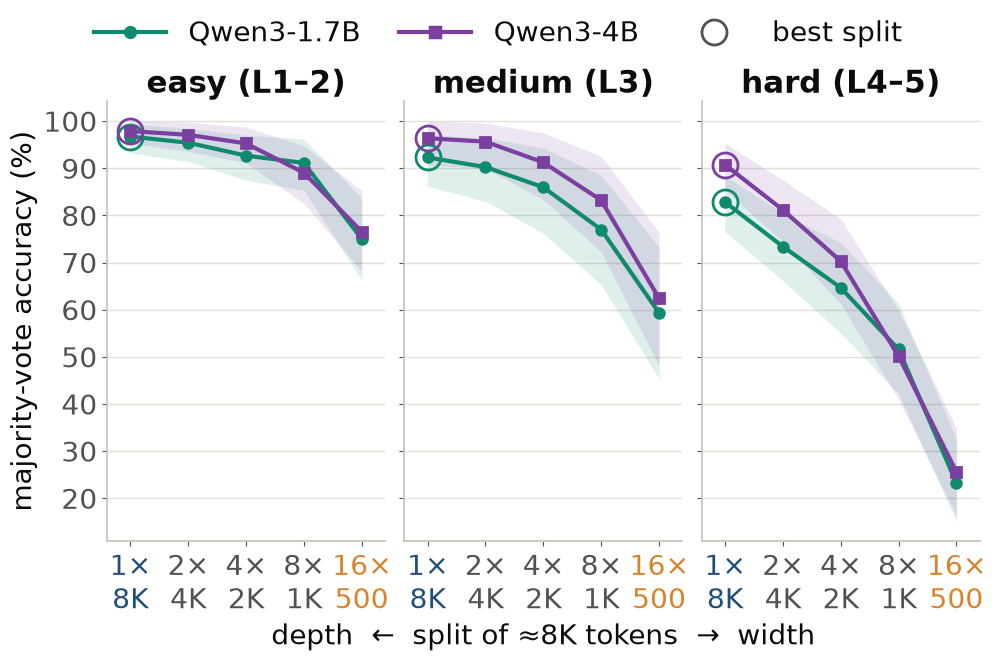

saved figures/F1_crossover_nothink.png/.pdf


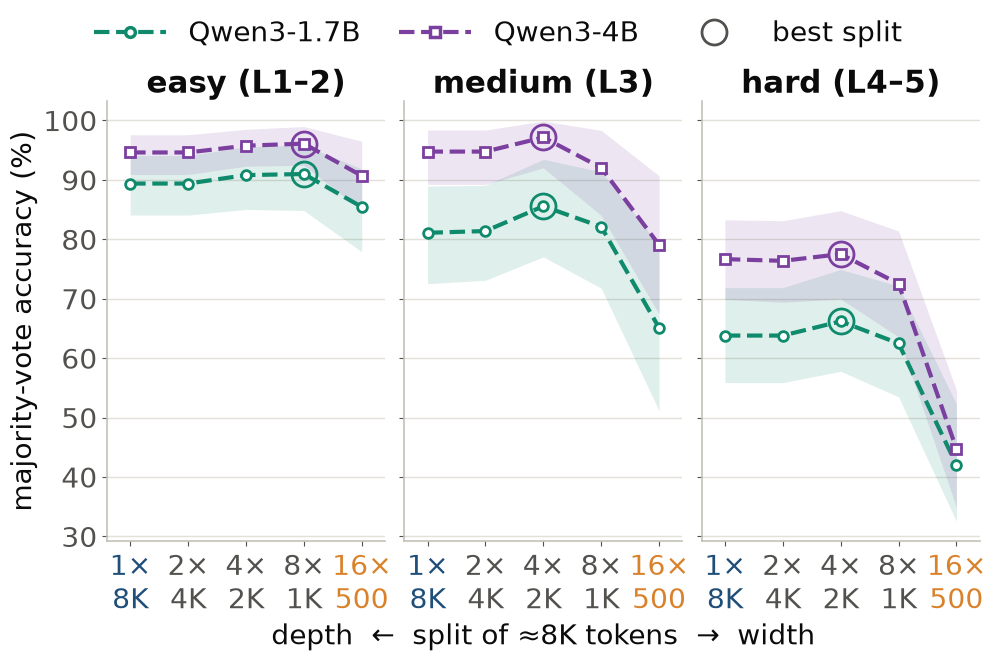

saved figures/F1_crossover_all_levels_both_modes.png/.pdf


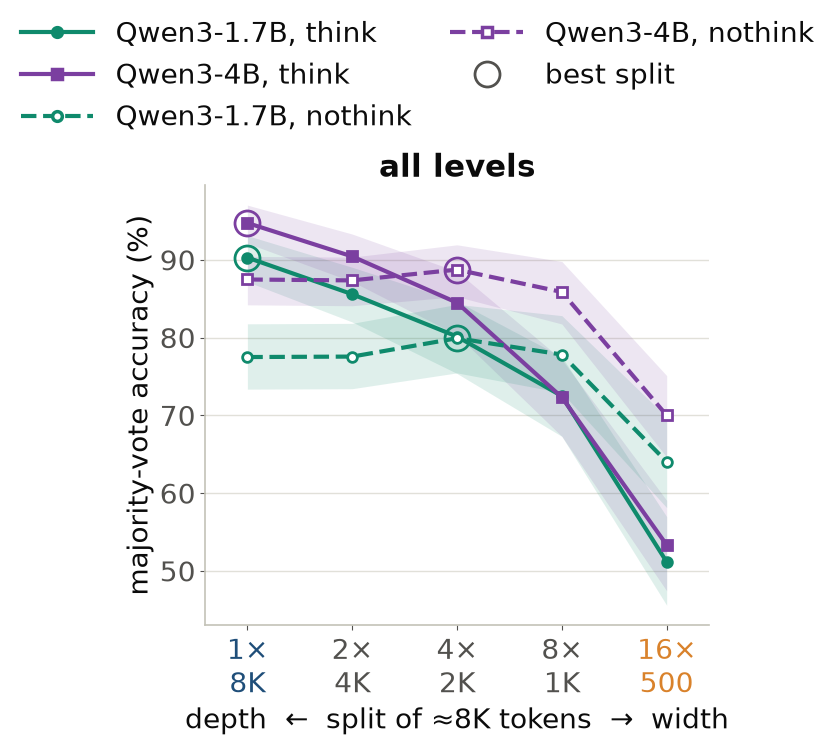

saved figures/F1_crossover_both_modes.png/.pdf


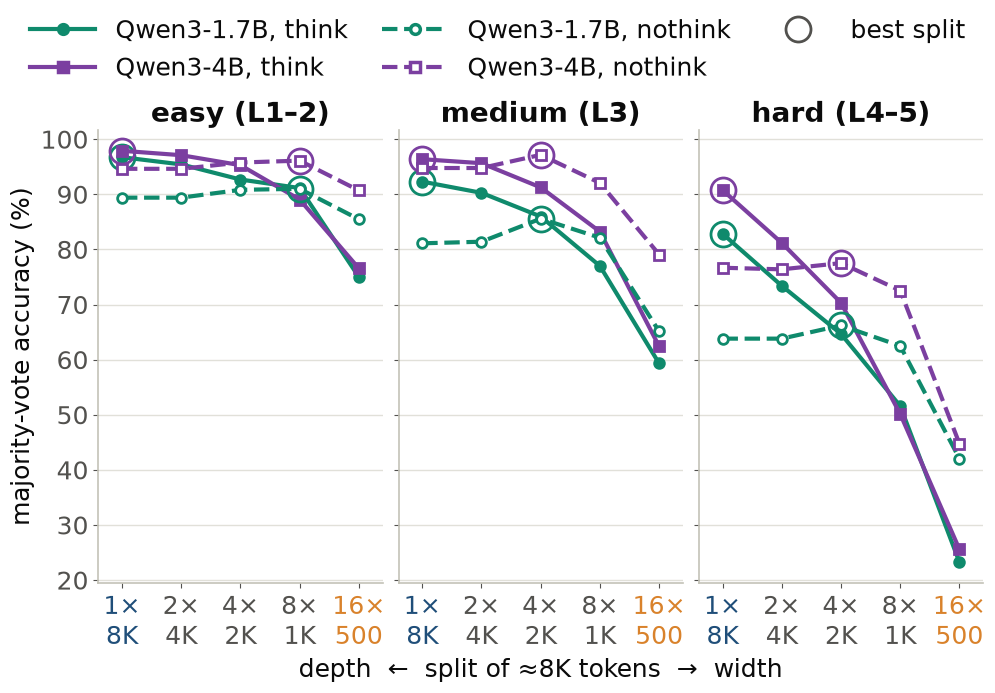

saved figures/F1_crossover_both_modes_6panel.png/.pdf


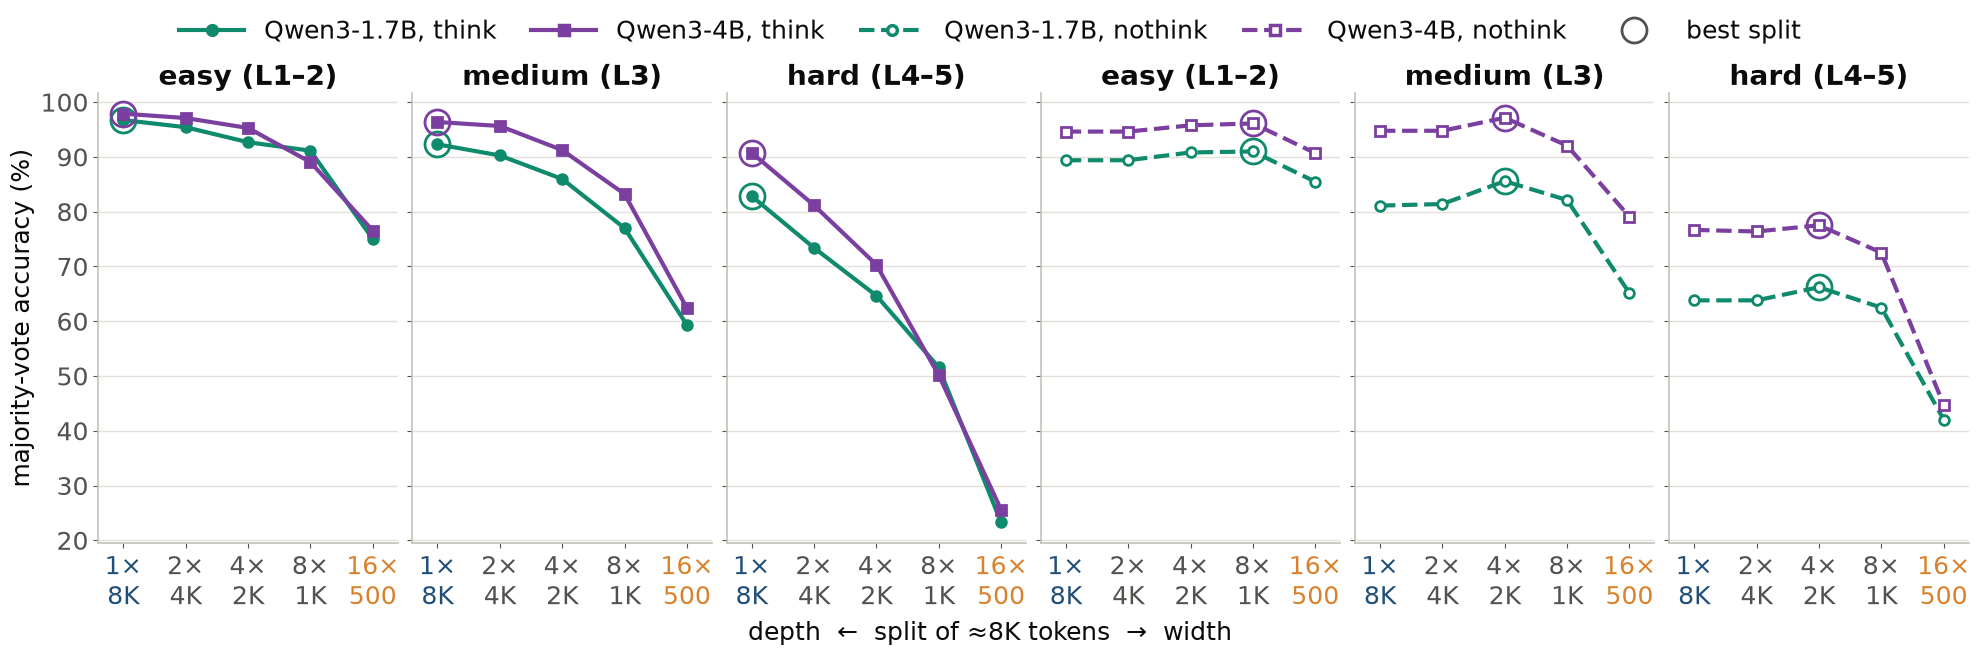

saved figures/F2_pass_vs_maj_gap_think.png/.pdf


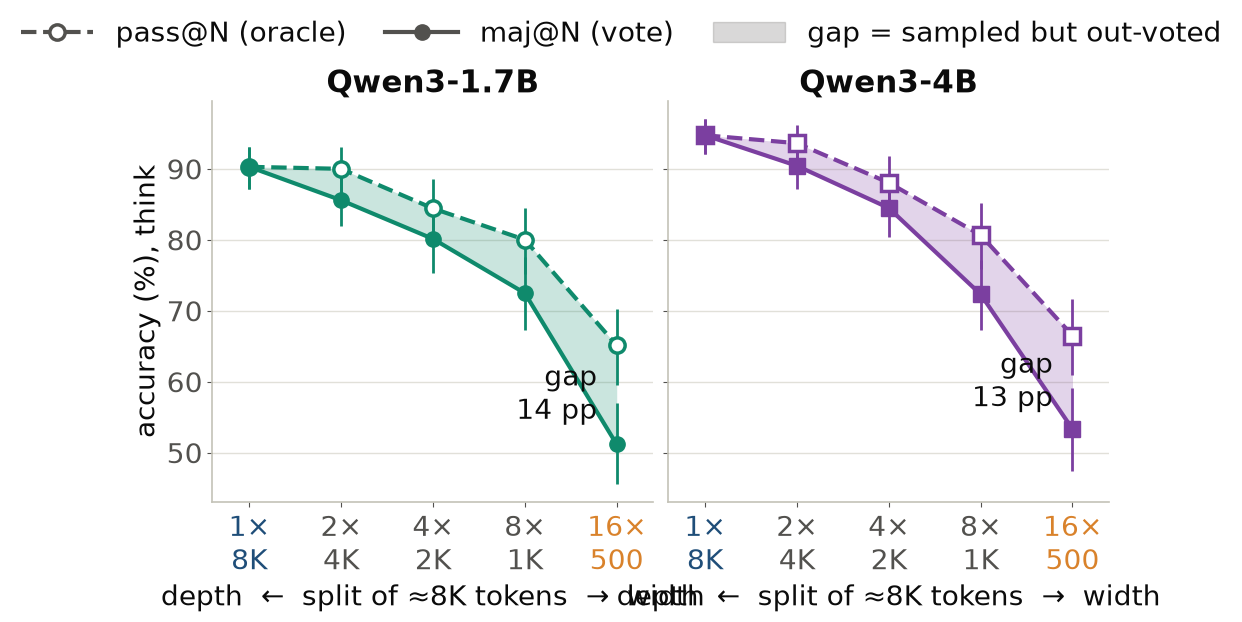

saved figures/F2_pass_vs_maj_gap_nothink.png/.pdf


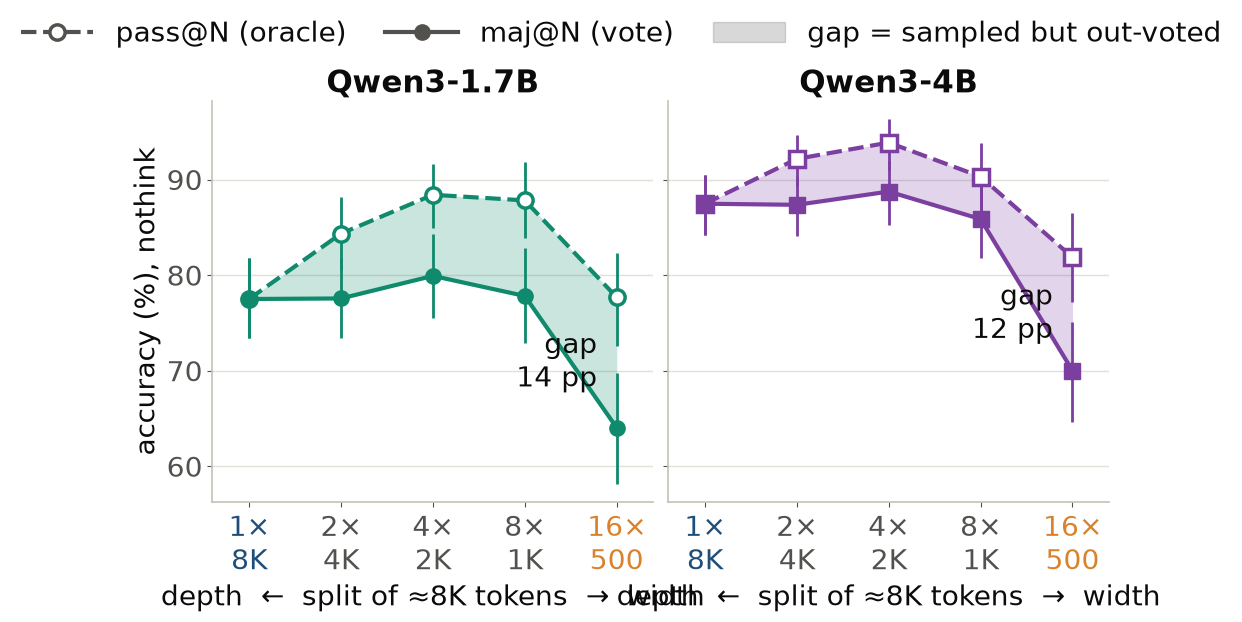

saved figures/F2_pass_vs_maj_gap_think_hard.png/.pdf


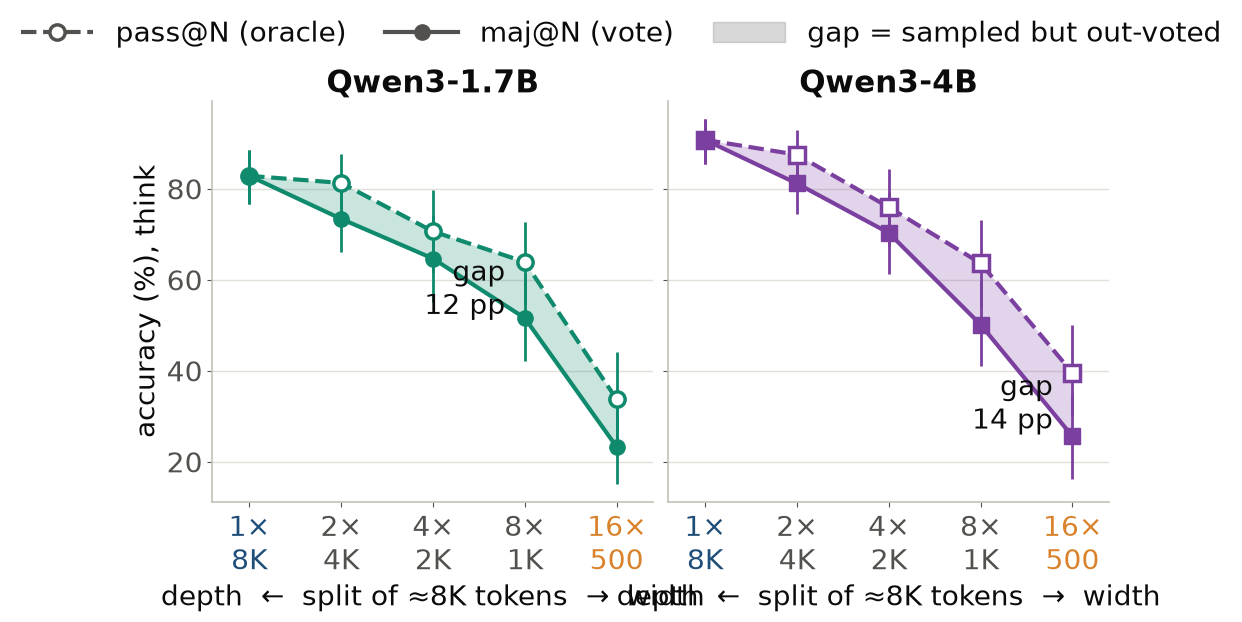

In [31]:
# ============================ ANALYSIS 5/7 — THE TWO POSTER FIGURES ============================
# Figure 1: the crossover. Budget shape on x (depth -> width), faceted by difficulty, one line per model.
fig_crossover(modes=(PRIMARY_MODE,), name=f"F1_crossover_{PRIMARY_MODE}")
fig_crossover(modes=("nothink",), name="F1_crossover_nothink")
fig_crossover(modes=MODES, groups=("all",), name="F1_crossover_all_levels_both_modes", w_mm=FIG_W_MM * 0.6, h_mm=150)
# Think and no-think overlaid (solid/filled = think, dashed/hollow = no-think), then side by side as six panels
# (think easy/medium/hard | no-think easy/medium/hard, shared y). No CI bands, type 2 pt smaller than the others.
with mpl.rc_context({"font.size": PT_MIN - 2, "axes.titlesize": PT_MIN, "axes.labelsize": PT_MIN - 2,
                     "xtick.labelsize": PT_MIN - 2, "ytick.labelsize": PT_MIN - 2, "legend.fontsize": PT_MIN - 2}):
    fig_crossover(modes=MODES, name="F1_crossover_both_modes", band=False, ncol=3)
    fig_crossover_by_mode(modes=MODES, name="F1_crossover_both_modes_6panel", band=False)

# Figure 2: pass@N vs maj@N with the selection gap shaded.
fig_gap(PRIMARY_MODE, "all", name=f"F2_pass_vs_maj_gap_{PRIMARY_MODE}")
fig_gap("nothink", "all", name="F2_pass_vs_maj_gap_nothink")
fig_gap(PRIMARY_MODE, "hard", name=f"F2_pass_vs_maj_gap_{PRIMARY_MODE}_hard")

saved figures/F3_accuracy_vs_measured_tokens.png/.pdf


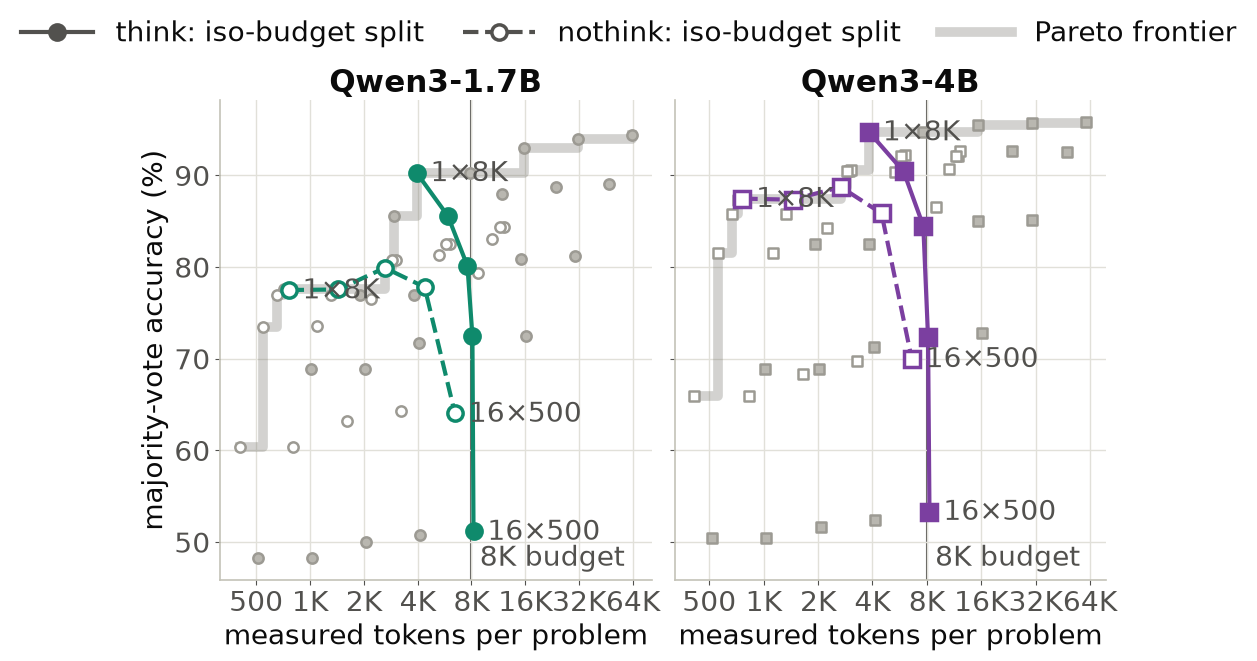

saved figures/F3_accuracy_vs_measured_tokens_hard.png/.pdf


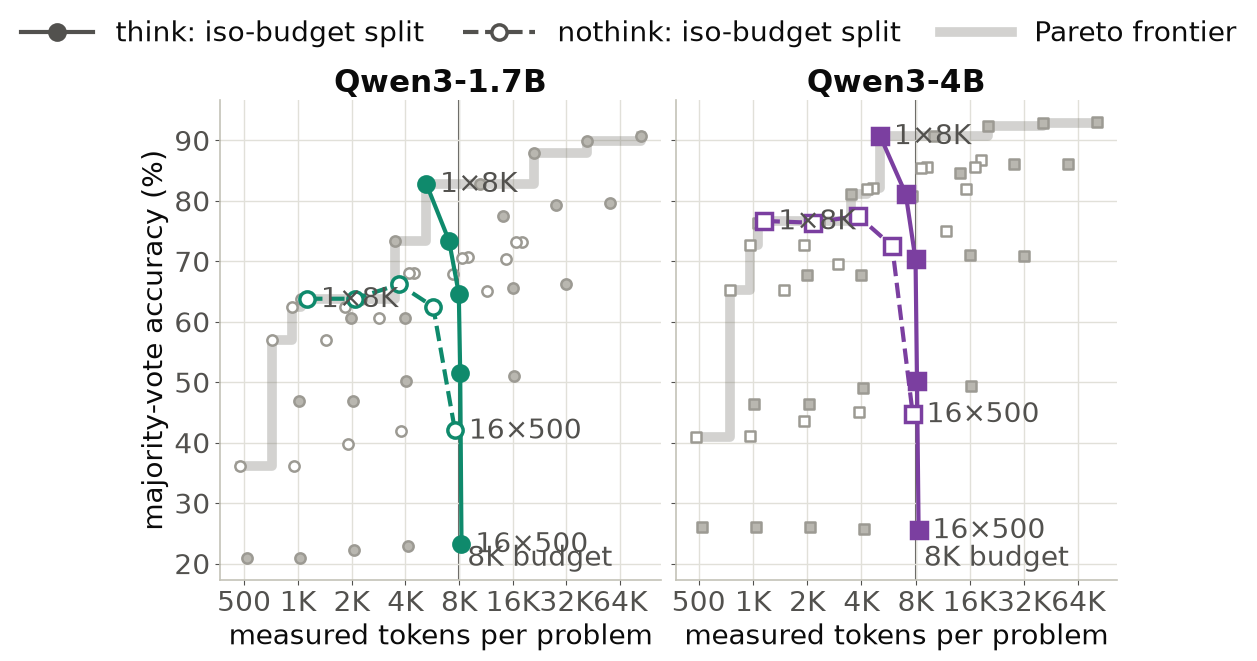

saved figures/F4_width_minus_depth_by_level.png/.pdf


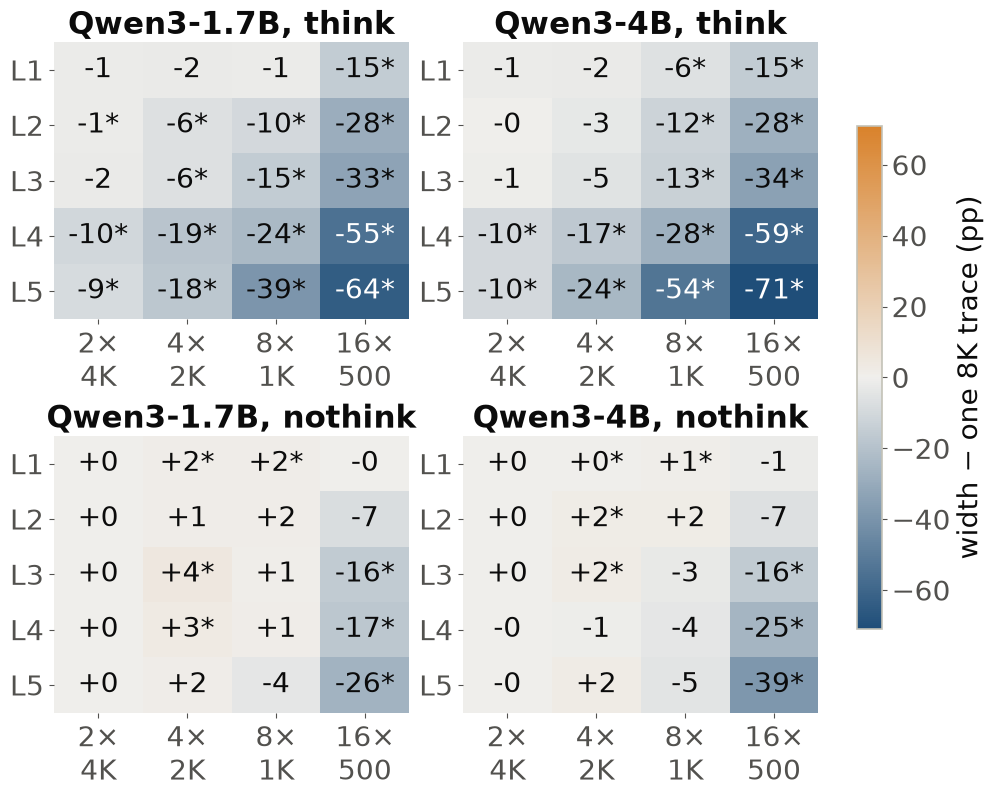

saved figures/F5_outcomes_think.png/.pdf


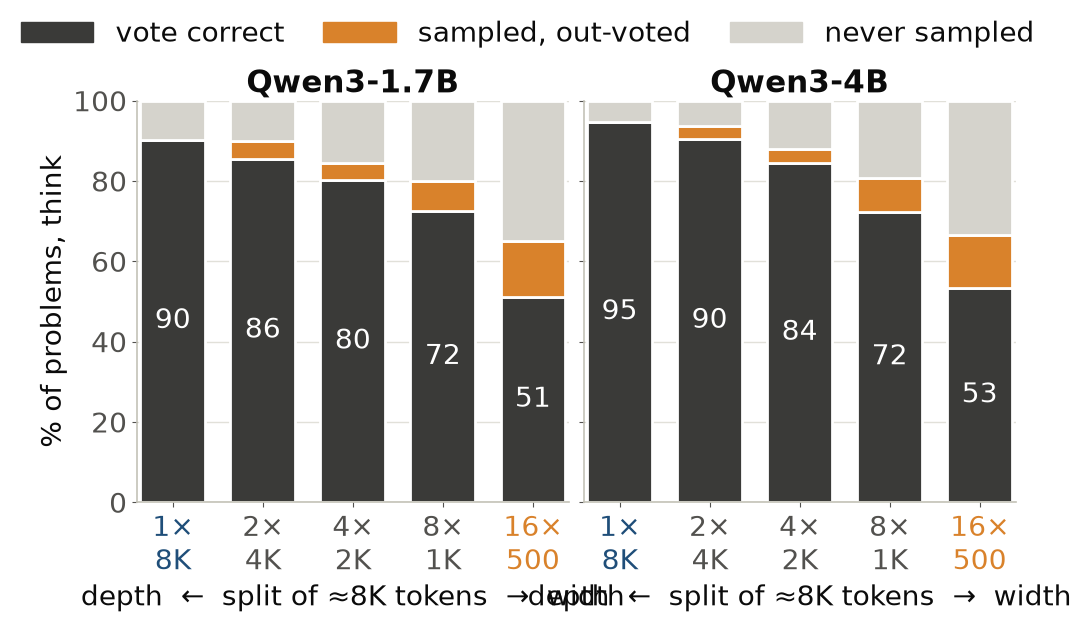

saved figures/F5_outcomes_nothink.png/.pdf


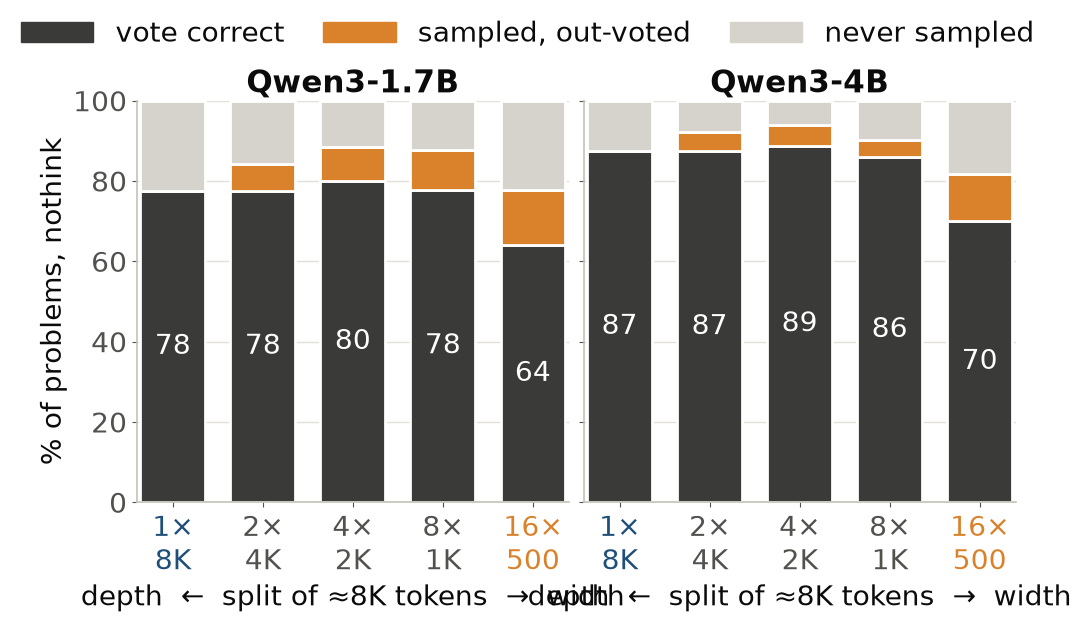

saved figures/F6_self_correction.png/.pdf


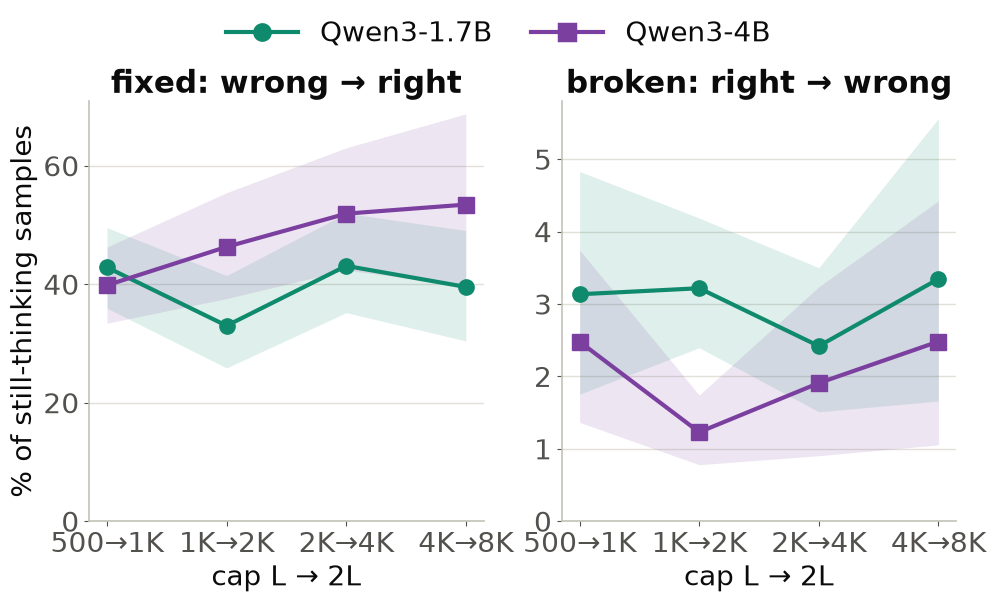

saved figures/F7_truncation_and_depth_curve.png/.pdf


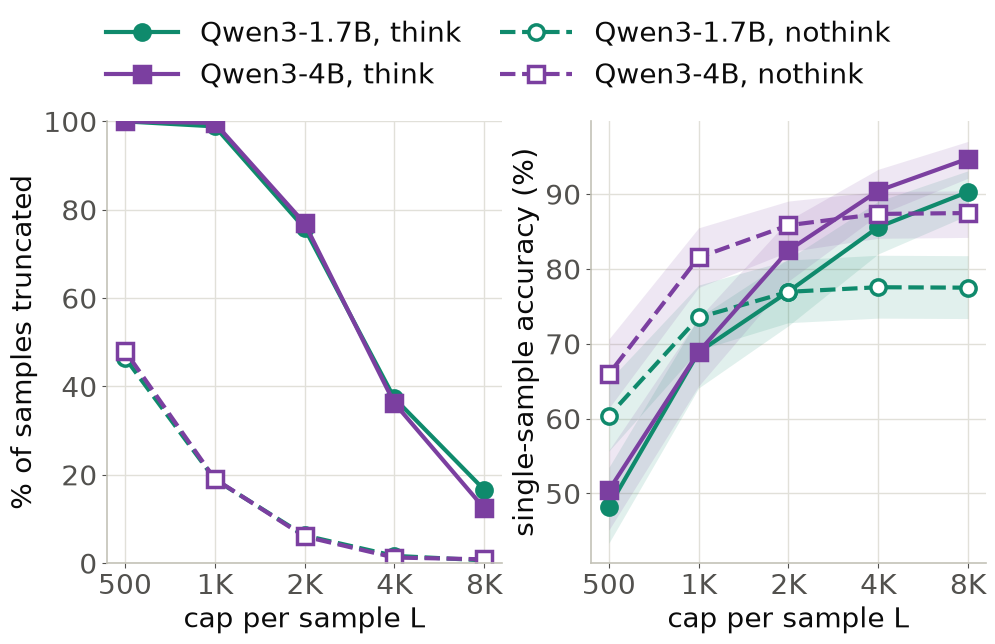

saved figures/F8_surface_maj_all.png/.pdf


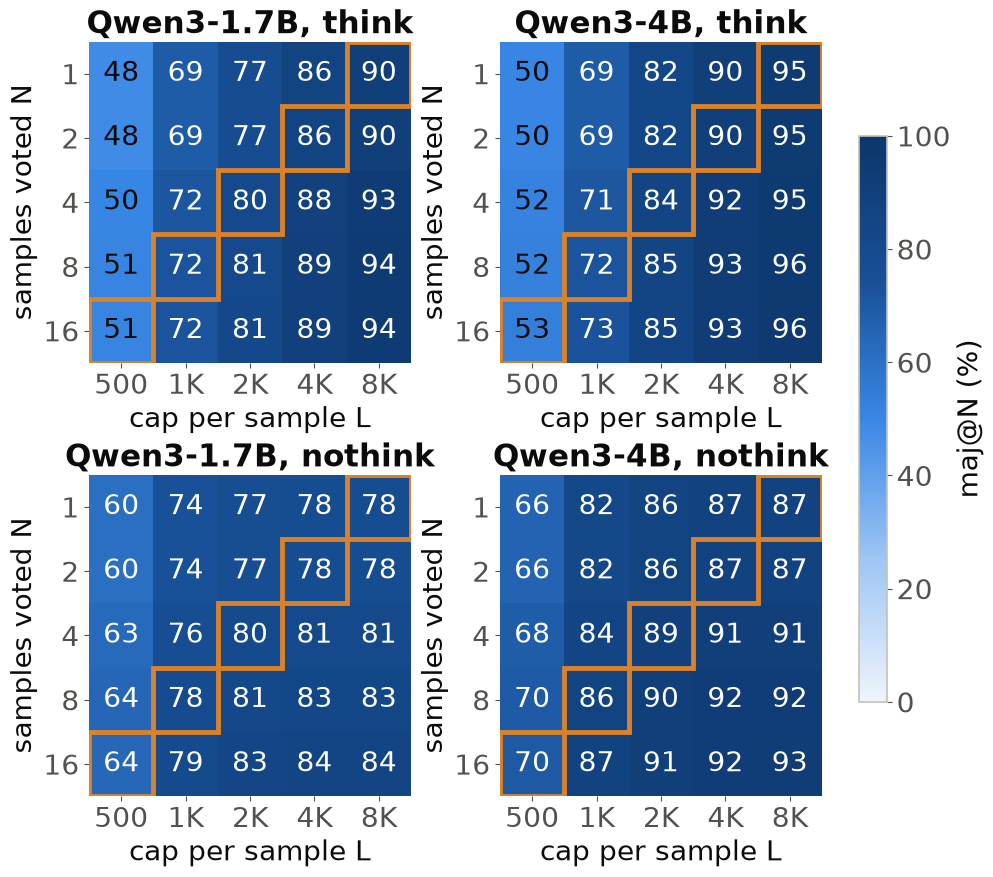

saved figures/F8_surface_pass_all.png/.pdf


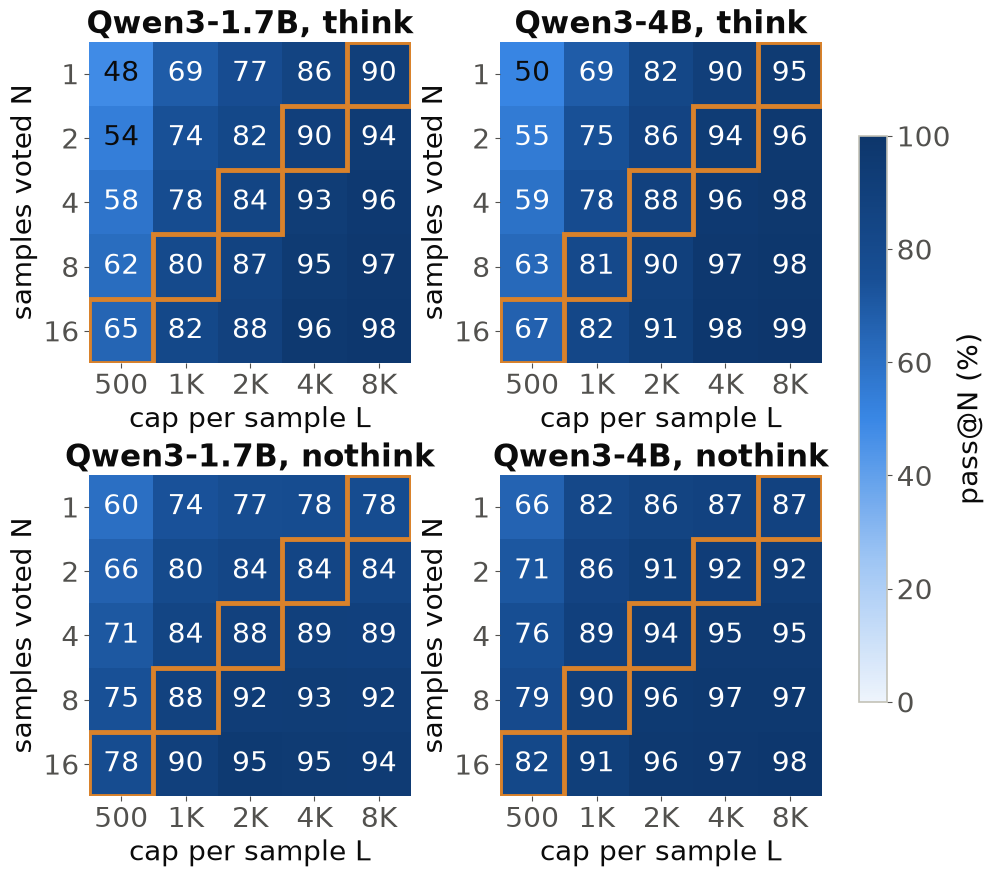

saved figures/F9_budget_sweep_N4_cap.png/.pdf


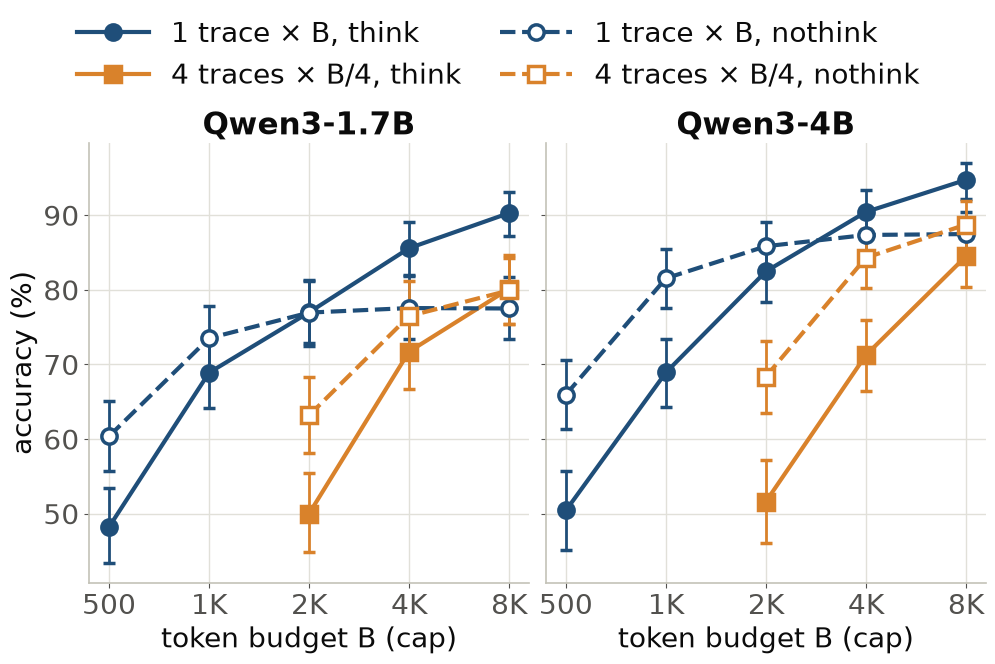

saved figures/F9_budget_sweep_N4_measured.png/.pdf


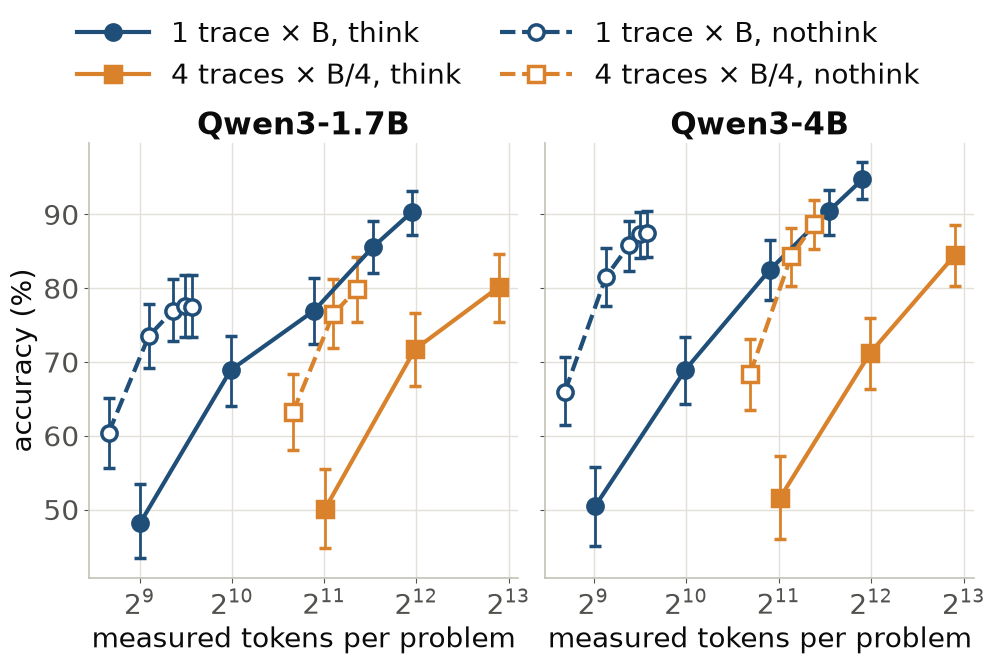

saved figures/F9_budget_sweep_N2_cap.png/.pdf


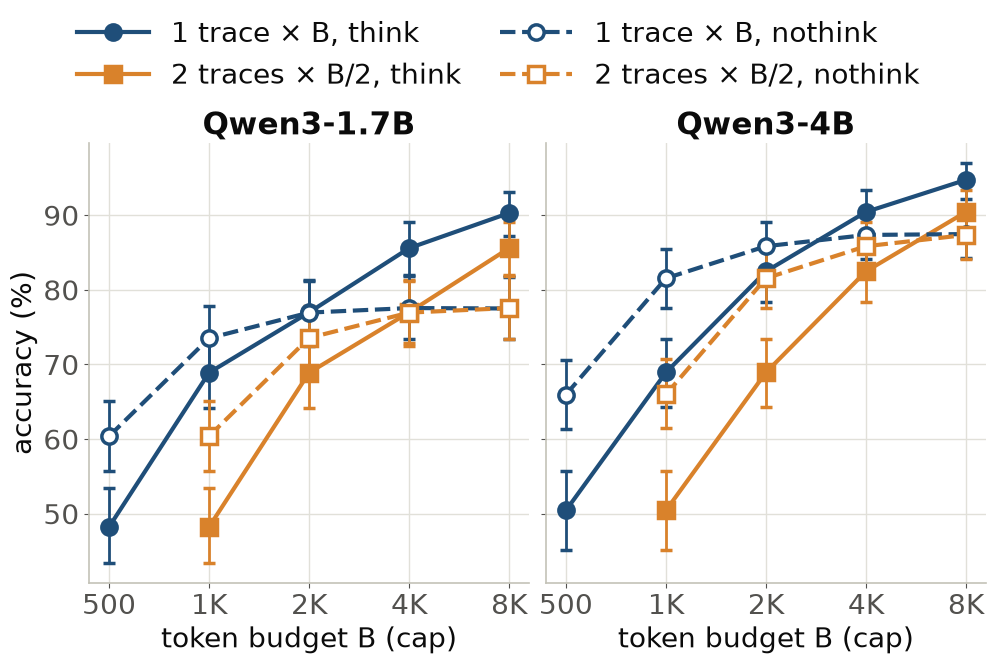

saved figures/F10_vote_share_calibration.png/.pdf


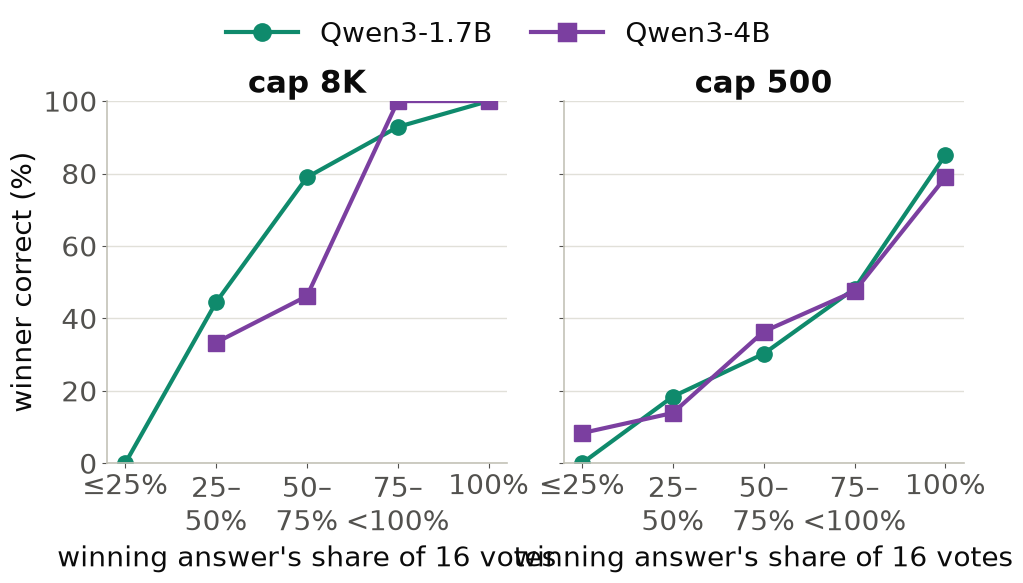

saved figures/F11_trace_length_ecdf.png/.pdf


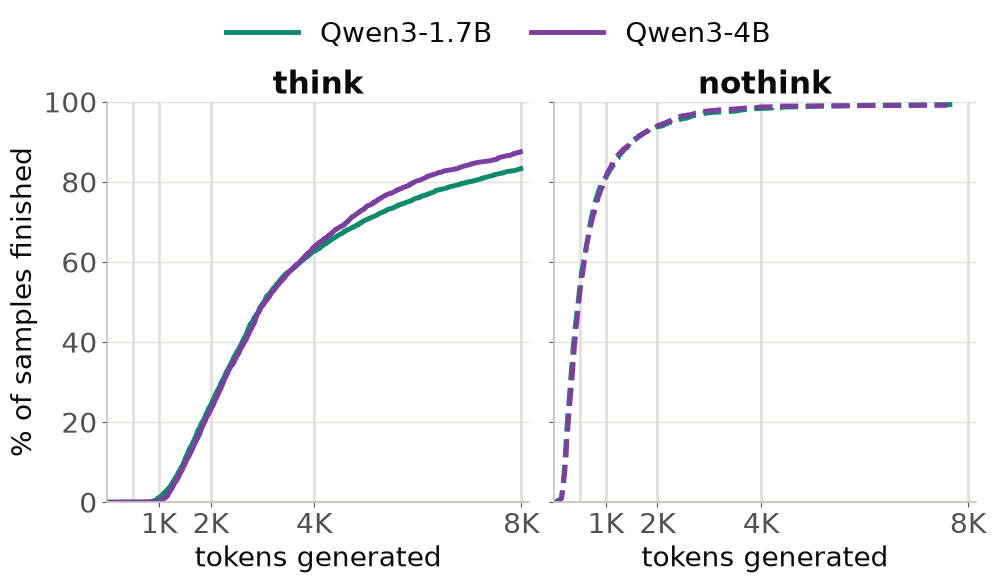

In [6]:
# ============================ ANALYSIS 6/7 — SUPPORTING FIGURES (repo / appendix / backup for questions) ============
fig_tokens("all")                                                    # F3  cap ≠ cost: accuracy vs measured tokens
fig_tokens("hard", name="F3_accuracy_vs_measured_tokens_hard")
fig_delta_heatmap()                                                  # F4  width − depth per level (sample-poster Fig 3)
fig_outcomes(PRIMARY_MODE, name=f"F5_outcomes_{PRIMARY_MODE}")       # F5  correct / out-voted / never sampled
fig_outcomes("nothink", name="F5_outcomes_nothink")
fig_self_correction(PRIMARY_MODE)                                    # F6  does more thinking fix or break answers?
fig_truncation()                                                     # F7  truncation + single-sample depth curve
fig_surface("maj")                                                   # F8  full 5×5 (N, L) surfaces
fig_surface("pass")
fig_budget_sweep(4, x="cap")                                         # F9  sample-poster Fig 2: 1×B vs 4×B/4
fig_budget_sweep(4, x="measured")
fig_budget_sweep(2, x="cap")
fig_calibration(PRIMARY_MODE)                                        # F10 vote share vs accuracy
fig_lengths()                                                        # F11 how long traces really are

### Verdicts and exports
Verdict rule, fixed in advance: **SUPPORTED** if the 95% CI lies entirely on the predicted side of 0, **REFUTED** if it lies entirely on the other side, otherwise **INCONCLUSIVE**. The cell also writes `poster_numbers.json` (every number the poster spec needs: N problems, iso-budget table, optimal split per model, gap per model, truncation, verdicts) and `FINDINGS.md`, a readable summary with factual headline candidates.

In [7]:
# ============================ ANALYSIS 7/7 — HYPOTHESIS VERDICTS, POSTER NUMBERS, FINDINGS.md, ZIP ============================
# Verdict rule, fixed before looking: SUPPORTED if the 95% CI lies entirely on the predicted side of 0, REFUTED if it lies
# entirely on the other side, otherwise INCONCLUSIVE. Everything is paired (same problems, same bootstrap resamples).
M1, M4 = MODELS

def verdict(lo, hi, direction=+1):
    lo, hi = sorted((direction * lo, direction * hi))
    return "SUPPORTED" if lo > 0 else ("REFUTED" if hi < 0 else "INCONCLUSIVE")

def vrow(hyp, md, claim, pt, lo, hi, direction=+1, extra="", descriptive=False):
    return {"hypothesis": hyp, "mode": md, "claim": claim, "estimate pp": pct(pt), "lo": pct(lo), "hi": pct(hi),
            "verdict": "descriptive" if descriptive else verdict(lo, hi, direction), "detail": extra}

def self_corr_net(m, md):
    t = TRANS[(m, md)]["pooled"]
    return boot_ratio(t["fix"] - t["brk"], t["wrong"] + t["right"], "all")

V = []
for md in [PRIMARY_MODE] + [x for x in MODES if x != PRIMARY_MODE]:
    a1, a4 = AL[(M1, md, "all")], AL[(M4, md, "all")]
    V.append(vrow("H1", md, f"width beats one 8K trace at {M1} (best width shape − 1×8K)", a1["dbest"], *a1["dbest_ci"],
                  extra=f"best width shape {SHAPES[a1['best_width']]}; overall best {SHAPES[a1['best']]}"))
    V.append(vrow("H1'", md, f"same contrast at {M4}", a4["dbest"], *a4["dbest_ci"], descriptive=True,
                  extra=f"best width shape {SHAPES[a4['best_width']]}; overall best {SHAPES[a4['best']]}"))
    did = a1["dbest_bs"] - a4["dbest_bs"]
    shift = _lx[a1["best_bs"]] - _lx[a4["best_bs"]]
    V.append(vrow("H2", md, "capacity moves the optimum toward depth: width advantage 1.7B − 4B",
                  a1["dbest"] - a4["dbest"], *np.percentile(did, [2.5, 97.5]),
                  extra=f"E[log2 N*] {a1['e_log2n']:.2f} (1.7B) vs {a4['e_log2n']:.2f} (4B); "
                        f"P(4B optimum deeper) = {(shift > 0).mean():.2f}"))
    gb1, gb4 = (diag(MET[(m, md)]["gap"])[:, 1:].mean(1) for m in MODELS)
    pt, lo, hi = boot(gb1 - gb4, "all")
    V.append(vrow("H3", md, "selection gap (pass − maj, mean over 4 width shapes) larger at 1.7B", pt, lo, hi,
                  extra=f"gap {pct(gb1.mean())} pp (1.7B) vs {pct(gb4.mean())} pp (4B)"))
    n1, n4 = self_corr_net(M1, md), self_corr_net(M4, md)
    V.append(vrow("H4", md, "more thinking self-corrects more at 4B: net (fix − break) per still-thinking sample, 4B − 1.7B",
                  n4[0] - n1[0], *np.percentile(n4[3] - n1[3], [2.5, 97.5]),
                  extra=f"net {pct(n1[0])} (1.7B) vs {pct(n4[0])} (4B) per 100 still-thinking samples"))
    for m in MODELS:
        ae, ah = AL[(m, md, "easy")], AL[(m, md, "hard")]
        V.append(vrow("H5 (exploratory)", md, f"harder problems shift {m} toward depth: width advantage easy − hard",
                      ae["dbest"] - ah["dbest"], *np.percentile(ae["dbest_bs"] - ah["dbest_bs"], [2.5, 97.5]),
                      extra=f"best easy {SHAPES[ae['best']]}, best hard {SHAPES[ah['best']]}"))
VERD = save_table(pd.DataFrame(V), "T12_hypothesis_verdicts")
print("Caveats: H1 re-picks the best width shape inside every resample, which leans slightly toward width. "
      "H4 counts a forced answer at L as 'wrong' even when the model simply had not finished, so read the fix rate "
      "as 'finish-or-fix'. The break rate is the clean over-thinking signal.")

# ---- numbers the poster spec asks for ----
def diag_numbers(m, md, g):
    r = T1[(T1.model == m) & (T1["mode"] == md) & (T1.difficulty == g)]
    return {s: {k: (None if pd.isna(v) else v) for k, v in row.items()}
            for s, row in zip(r["shape"], r.drop(columns=["model", "mode", "difficulty", "shape"]).to_dict("records"))}

NUM = {
    "data": {"benchmark": "MATH-500", "problems": int(P), "per_level": {f"L{l}": int((LEVEL == l).sum()) for l in LEVELS},
             "difficulty_groups": {g: int(len(COLS[g])) for g in G4}, "samples_per_problem": A_K,
             "traces_total": int(P * A_K * len(ARR)), "bootstrap_resamples": N_BOOT},
    "iso_budget": {f"{m}|{md}|{g}": diag_numbers(m, md, g) for m in MODELS for md in MODES for g in G4},
    "allocation": {f"{m}|{md}|{g}": {"best": SHAPES[r["best"]], "best_width": SHAPES[r["best_width"]],
                                     "P_best": dict(zip(SHAPES, map(float, r["p_best"]))), "E_log2_N": r["e_log2n"],
                                     "delta_best_width_pp": pct(r["dbest"]), "ci": [pct(x) for x in r["dbest_ci"]]}
                   for (m, md, g), r in AL.items() if g in G4},
    "self_correction_pooled": {f"{m}|{md}": {k: pct(boot_ratio(TRANS[(m, md)]["pooled"][a], TRANS[(m, md)]["pooled"][b])[0])
                                             for k, a, b in [("fix_rate", "fix", "wrong"), ("break_rate", "brk", "right")]}
                               for m in MODELS for md in MODES},
    "trace_lengths": T6b.to_dict("records"),
    "verdicts": VERD.to_dict("records"),
}

# ---- factual headline candidates (no claim beyond the numbers) ----
def acc(m, md, s, g="all"):
    return NUM["iso_budget"][f"{m}|{md}|{g}"][s]["maj@N"]

a1, a4 = AL[(M1, PRIMARY_MODE, "all")], AL[(M4, PRIMARY_MODE, "all")]
b1, b4 = SHAPES[a1["best"]], SHAPES[a4["best"]]
w1, w4 = SHAPES[a1["best_width"]], SHAPES[a4["best_width"]]
g1 = NUM["iso_budget"][f"{M1}|{PRIMARY_MODE}|all"][w1]
g4 = NUM["iso_budget"][f"{M4}|{PRIMARY_MODE}|all"][w4]
t1 = NUM["iso_budget"][f"{M1}|{PRIMARY_MODE}|all"]["1×8K"]
t4 = NUM["iso_budget"][f"{M4}|{PRIMARY_MODE}|all"]["1×8K"]
HEAD = [
    f"With ≈8K thinking tokens per MATH-500 problem, the best split is {b1} at 1.7B ({acc(M1, PRIMARY_MODE, b1)}% vs "
    f"{acc(M1, PRIMARY_MODE, '1×8K')}% for one 8K trace) and {b4} at 4B ({acc(M4, PRIMARY_MODE, b4)}% vs "
    f"{acc(M4, PRIMARY_MODE, '1×8K')}%).",
    f"At {w1}, the correct answer is among 1.7B's samples for {g1['pass@N']}% of problems, but the vote returns it for only "
    f"{g1['maj@N']}%: a {g1['gap']}-point selection gap ({g4['gap']} points for 4B at {w4}).",
    f"One '8K' thinking trace actually spends {t1['tokens measured']:,} tokens at 1.7B and {t4['tokens measured']:,} at 4B "
    f"({t1['% of 8K used']}% and {t4['% of 8K used']}% of the cap), so every comparison uses measured tokens.",
]
NUM["headline_candidates"] = HEAD
with open(f"{ANALYSIS_DIR}/poster_numbers.json", "w") as f:
    json.dump(NUM, f, indent=1, ensure_ascii=False, default=float)

# ---- FINDINGS.md: every number the poster needs, in one readable file ----
def md_table(df):
    cols = list(df.columns)
    out = ["| " + " | ".join(map(str, cols)) + " |", "|" + "---|" * len(cols)]
    for row in df.itertuples(index=False):
        out.append("| " + " | ".join("" if (isinstance(v, float) and np.isnan(v)) else str(v) for v in row) + " |")
    return "\n".join(out)

sec = ["# Findings: depth vs. width on MATH-500 (auto-generated)\n",
       f"{P} problems ({', '.join(f'L{l} {(LEVEL == l).sum()}' for l in LEVELS)}), {A_K} samples each, "
       f"{len(MODELS)} models × {len(MODES)} modes = {P * A_K * len(ARR):,} traces. maj@N/pass@N are exact over all "
       f"C(16,N) subsets; CIs come from a {N_BOOT}× level-stratified problem bootstrap, paired across configs.\n",
       "## Headline candidates\n", *[f"- {h}" for h in HEAD],
       "\n## Hypothesis verdicts\n", md_table(VERD),
       "\n## Iso-budget diagonal: maj@N [95% CI] (%)\n", md_table(T1p),
       "\n## Optimal allocation\n", md_table(T3.drop(columns=[c for c in T3.columns if c.startswith("P(best")])),
       "\n## Capacity shift (1.7B vs 4B)\n", md_table(T3b),
       "\n## Selection gap, mean over the 4 width shapes\n", md_table(T4b),
       "\n## Truncation at each cap (all levels)\n",
       md_table(T6[T6.difficulty == "all"].drop(columns=["difficulty"])),
       "\n## Think vs no-think (all levels)\n", md_table(T7[T7.difficulty == "all"].drop(columns=["difficulty"])),
       "\n## Pareto frontier over measured tokens (all levels)\n",
       md_table(T8[(T8.difficulty == "all") & T8.pareto].drop(columns=["difficulty", "pareto"])),
       "\n## Figures\n", *[f"- `figures/{os.path.basename(p)}`" for p in sorted(glob.glob(f"{FIG_DIR}/*.png"))],
       "\n## Tables\n", *[f"- `tables/{os.path.basename(p)}`" for p in sorted(glob.glob(f"{TAB_DIR}/*.csv"))]]
with open(f"{ANALYSIS_DIR}/FINDINGS.md", "w") as f:
    f.write("\n".join(sec) + "\n")

print("\n=== HEADLINE CANDIDATES ===")
for h in HEAD:
    print("•", h)
print("\n=== VERDICTS ===")
for r in V:
    print(f"{r['hypothesis']:<17}{r['mode']:<8}{r['verdict']:<13}{r['estimate pp']:+6.1f} pp "
          f"[{r['lo']:+.1f}, {r['hi']:+.1f}]  {r['claim']}  ({r['detail']})")

print(f"\nwrote {ANALYSIS_DIR}/FINDINGS.md, poster_numbers.json, {len(glob.glob(FIG_DIR + '/*.png'))} figures, "
      f"{len(glob.glob(TAB_DIR + '/*.csv'))} tables")
if os.path.isdir("/kaggle/working"):                  # one file to grab from the Output tab
    print("zipped ->", shutil.make_archive(ANALYSIS_DIR, "zip", ANALYSIS_DIR))


### T12_hypothesis_verdicts  (14 rows) -> tables/T12_hypothesis_verdicts.csv


,hypothesis,mode,claim,estimate pp,lo,hi,verdict,detail
0,H1,think,width beats one 8K trace at Qwen3-1.7B (best w...,-4.7,-6.3,-3.1,REFUTED,best width shape 2×4K; overall best 1×8K
1,H1',think,same contrast at Qwen3-4B,-4.3,-6.2,-2.6,descriptive,best width shape 2×4K; overall best 1×8K
2,H2,think,capacity moves the optimum toward depth: width...,-0.4,-1.9,1.2,INCONCLUSIVE,E[log2 N*] 0.00 (1.7B) vs 0.00 (4B); P(4B opti...
3,H3,think,"selection gap (pass − maj, mean over 4 width s...",0.5,-1.3,2.4,INCONCLUSIVE,gap 7.5 pp (1.7B) vs 7.1 pp (4B)
4,H4,think,more thinking self-corrects more at 4B: net (f...,0.7,-0.7,1.9,INCONCLUSIVE,net 13.5 (1.7B) vs 14.2 (4B) per 100 still-thi...
5,H5 (exploratory),think,harder problems shift Qwen3-1.7B toward depth:...,8.1,4.5,12.0,SUPPORTED,"best easy 1×8K, best hard 1×8K"
6,H5 (exploratory),think,harder problems shift Qwen3-4B toward depth: w...,8.8,4.7,13.4,SUPPORTED,"best easy 1×8K, best hard 1×8K"
7,H1,nothink,width beats one 8K trace at Qwen3-1.7B (best w...,2.4,1.4,3.5,SUPPORTED,best width shape 4×2K; overall best 4×2K
8,H1',nothink,same contrast at Qwen3-4B,1.3,-0.1,2.6,descriptive,best width shape 4×2K; overall best 4×2K
9,H2,nothink,capacity moves the optimum toward depth: width...,1.1,-0.3,2.5,INCONCLUSIVE,E[log2 N*] 2.02 (1.7B) vs 1.91 (4B); P(4B opti...


Caveats: H1 re-picks the best width shape inside every resample, which leans slightly toward width. H4 counts a forced answer at L as 'wrong' even when the model simply had not finished, so read the fix rate as 'finish-or-fix'. The break rate is the clean over-thinking signal.

=== HEADLINE CANDIDATES ===
• With ≈8K thinking tokens per MATH-500 problem, the best split is 1×8K at 1.7B (90.3% vs 90.3% for one 8K trace) and 1×8K at 4B (94.7% vs 94.7%).
• At 2×4K, the correct answer is among 1.7B's samples for 90.0% of problems, but the vote returns it for only 85.6%: a 4.4-point selection gap (3.2 points for 4B at 2×4K).
• One '8K' thinking trace actually spends 3,949 tokens at 1.7B and 3,830 at 4B (49.4% and 47.9% of the cap), so every comparison uses measured tokens.

=== VERDICTS ===
H1               think   REFUTED        -4.7 pp [-6.3, -3.1]  width beats one 8K trace at Qwen3-1.7B (best width shape − 1×8K)  (best width shape 2×4K; overall best 1×8K)
H1'              think   descripti

# Research questions: charts that answer them directly

**RQ1.** With the same token budget, which solves more problems: one long answer, or several short answers that vote?
**RQ2.** Does the answer change with problem difficulty, model size, or thinking mode (on/off)?

Definitions used in every chart below (run ANALYSIS 1/7–4/7 first; these cells reuse their data and plotting style):
- **Budget B** is the token cap for the whole problem. **One long answer** = 1 sample capped at B. **Several short answers** = N samples capped at B/N each, combined by majority vote over equivalent answers. Both sides get the same cap. The measured tokens are listed next to every comparison in T13, because a cap is not a cost.
- **Δ = votes − one long answer**, in percentage points (pp), paired on the same problems, with a 95% bootstrap CI. Orange means the votes win (CI above 0), navy means one long answer wins (CI below 0), and grey means no clear winner (CI spans 0).
- **Solved** means correct in more than half of the runs, i.e. solve probability above 0.5 from the 16 samples.
- The headline charts use **N = `VOTE_N` = 4** votes, as in the sample poster. The forest plot R1a shows every N the grid allows, so the conclusion does not rest on that choice.

| Chart | Question | What it shows |
|---|---|---|
| R1a | RQ1 | Δ for all 10 same-budget pairs (budgets 1K–8K), per model × mode |
| R1b | RQ1 | Problem counts: solved only by the long answer / by both / only by the votes / by neither |
| R1c | RQ1 | Accuracy bars at 8K: one long answer vs 4 votes |
| R2a | RQ2 | Δ across difficulty levels L1–L5, per model, thinking on vs off |
| R2b | RQ2 | Effect of each factor on Δ (difficulty, model size, thinking mode), with the contrast and its CI |
| R2c | RQ2 | Winner map: model × mode × difficulty × budget |

In [8]:
# ============================ RQ 1/3 — SHARED DEFINITIONS FOR THE RESEARCH-QUESTION CHARTS ============================
# "One long answer" = 1 sample capped at B. "Several short answers" = N samples capped at B/N, majority vote.
VOTE_N     = 4                                   # "several" in the headline charts (as in the sample poster)
RQ_B       = 8000                                # headline budget
RQ_BUDGETS = [8000, 4000, 2000, 1000]
C_TIE      = "#9c9a93"
PAIRS = [(B, N) for B in RQ_BUDGETS for N in A_NS[1:] if B % N == 0 and B // N in A_LENGTHS]   # the 10 same-budget pairs

def idx(N, L):
    return A_NS.index(N), A_LENGTHS.index(L)

def delta_vote(m, md, B, N):
    """Per problem (paired): maj@N at cap B/N − single-sample accuracy at cap B, as fractions."""
    M_ = MET[(m, md)]["maj"]
    n, j = idx(N, B // N)
    return M_[:, n, j] - M_[:, 0, A_LENGTHS.index(B)]

def win_color(lo, hi):
    return C_WIDTH if lo > 0 else (C_DEPTH if hi < 0 else C_TIE)

def win_word(lo, hi):
    return "votes win" if lo > 0 else ("one long wins" if hi < 0 else "no clear winner")

def winner_handles():
    return [Line2D([], [], color=c, marker="o", lw=4, ms=12, label=lab) for c, lab in
            [(C_WIDTH, "votes win"), (C_DEPTH, "one long answer wins"), (C_TIE, "no clear winner (CI spans 0)")]]

def solved_split(m, md, B, N, g="all"):
    """Problem counts by who solves it (correct in > half the runs): one long answer vs N votes, same budget B."""
    M_, c = MET[(m, md)]["maj"], COLS[g]
    n, j = idx(N, B // N)
    long_, vote = M_[c, 0, A_LENGTHS.index(B)] > 0.5, M_[c, n, j] > 0.5
    return {"only one long": int((long_ & ~vote).sum()), "both": int((long_ & vote).sum()),
            "only votes": int((~long_ & vote).sum()), "neither": int((~long_ & ~vote).sum())}

def mcnemar_p(b, c):
    """Exact two-sided McNemar (sign) test on the problems only one strategy solves."""
    n = b + c
    return 1.0 if n == 0 else min(1.0, 2 * sum(comb(n, k) for k in range(min(b, c) + 1)) / 2 ** n)

def group_contrast(x, g1, g0):
    """Mean of x in group g1 − mean in g0, with a bootstrap CI (the groups are disjoint problem sets)."""
    d = boot_dist(x, g1) - boot_dist(x, g0)
    return x[COLS[g1]].mean() - x[COLS[g0]].mean(), np.percentile(d, 2.5), np.percentile(d, 97.5)

def sign_labels(ax):
    """Corner labels so the sign of Δ reads without the caption."""
    ax.text(0.02, 0.97, "votes better ↑", transform=ax.transAxes, ha="left", va="top", color=INK2, fontsize=PT_MIN)
    ax.text(0.02, 0.03, "one long better ↓", transform=ax.transAxes, ha="left", va="bottom", color=INK2, fontsize=PT_MIN)

def short_model(m):
    return m.replace("Qwen3-", "")

# ---- T13: every same-budget comparison, per model × mode × difficulty ----
rows = []
for m in MODELS:
    for md in MODES:
        M_ = MET[(m, md)]
        for g in G4:
            c = COLS[g]
            for B, N in PAIRS:
                x = delta_vote(m, md, B, N)
                pt, lo, hi = boot(x, g)
                n, j = idx(N, B // N)
                jB = A_LENGTHS.index(B)
                sp = solved_split(m, md, B, N, g)
                rows.append({"model": m, "mode": md, "difficulty": g, "budget B": B, "one long": shape(1, B),
                             "votes": shape(N, B // N), "N": N,
                             "acc one long %": pct(M_["maj"][c, 0, jB].mean()), "acc votes %": pct(M_["maj"][c, n, j].mean()),
                             **ci3("votes − one long", (pt, lo, hi)), "p": round(float(boot_p(x, g)), 4),
                             "winner": win_word(lo, hi),
                             "tokens one long": round(float(M_["tok"][c, 0, jB].mean())),
                             "tokens votes": round(float(M_["tok"][c, n, j].mean())),
                             **{f"solved: {k}": v for k, v in sp.items()},
                             "McNemar p": round(mcnemar_p(sp["only one long"], sp["only votes"]), 4)})
T13 = save_table(pd.DataFrame(rows), "T13_rq1_same_budget", show=False)
display(T13[(T13.difficulty == "all") & (T13.N == VOTE_N)])


### T13_rq1_same_budget  (160 rows) -> tables/T13_rq1_same_budget.csv


,model,mode,difficulty,budget B,one long,votes,N,acc one long %,acc votes %,votes − one long,votes − one long lo,votes − one long hi,p,winner,tokens one long,tokens votes,solved: only one long,solved: both,solved: only votes,solved: neither,McNemar p
31,Qwen3-1.7B,think,all,8000,1×8K,4×2K,4,90.3,80.1,-10.2,-13.6,-7.0,0.000,one long wins,3949,7594,28,171,1,15,0.0000
35,Qwen3-1.7B,think,all,4000,1×4K,4×1K,4,85.6,71.7,-13.9,-17.5,-10.4,0.000,one long wins,2952,4050,31,154,1,29,0.0000
38,Qwen3-1.7B,think,all,2000,1×2K,4×500,4,77.0,50.0,-27.0,-32.2,-22.0,0.000,one long wins,1898,2054,63,108,0,44,0.0000
71,Qwen3-1.7B,nothink,all,8000,1×8K,4×2K,4,77.5,79.9,2.4,1.4,3.5,0.000,votes win,759,2621,1,166,5,43,0.2188
75,Qwen3-1.7B,nothink,all,4000,1×4K,4×1K,4,77.6,76.5,-1.1,-3.0,0.9,0.264,no clear winner,720,2188,6,161,4,44,0.7539
78,Qwen3-1.7B,nothink,all,2000,1×2K,4×500,4,76.9,63.2,-13.8,-17.6,-9.9,0.000,one long wins,655,1617,33,133,3,46,0.0000
111,Qwen3-4B,think,all,8000,1×8K,4×2K,4,94.7,84.5,-10.3,-13.9,-6.5,0.000,one long wins,3830,7653,26,179,2,8,0.0000
115,Qwen3-4B,think,all,4000,1×4K,4×1K,4,90.4,71.3,-19.2,-23.2,-15.3,0.000,one long wins,2975,4065,40,154,1,20,0.0000
118,Qwen3-4B,think,all,2000,1×2K,4×500,4,82.5,51.6,-30.8,-36.4,-25.4,0.000,one long wins,1913,2069,67,113,0,35,0.0000
151,Qwen3-4B,nothink,all,8000,1×8K,4×2K,4,87.5,88.7,1.3,-0.2,2.6,0.090,no clear winner,761,2670,4,186,6,19,0.7539


saved figures/R1a_same_budget_all_splits.png/.pdf


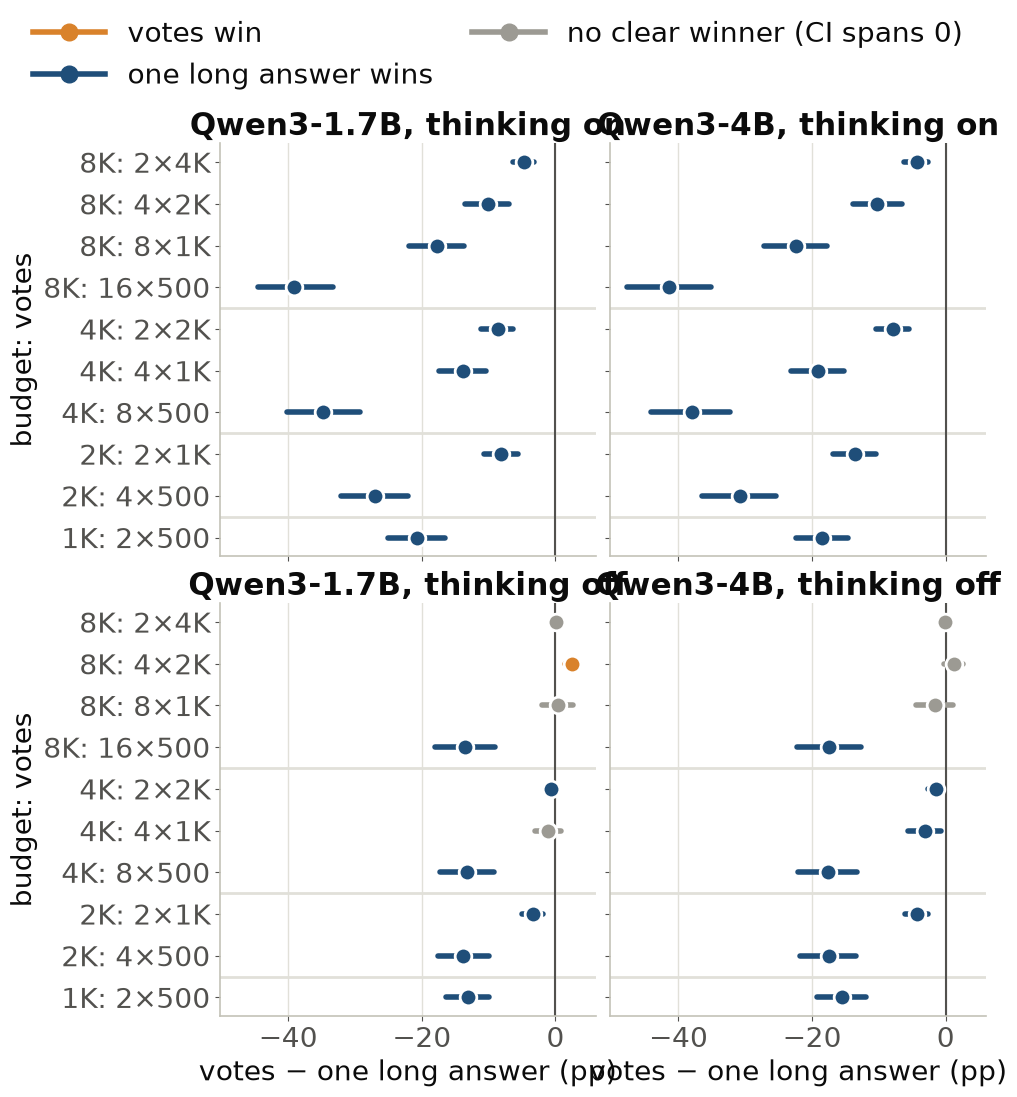

saved figures/R1a_same_budget_all_splits_hard.png/.pdf


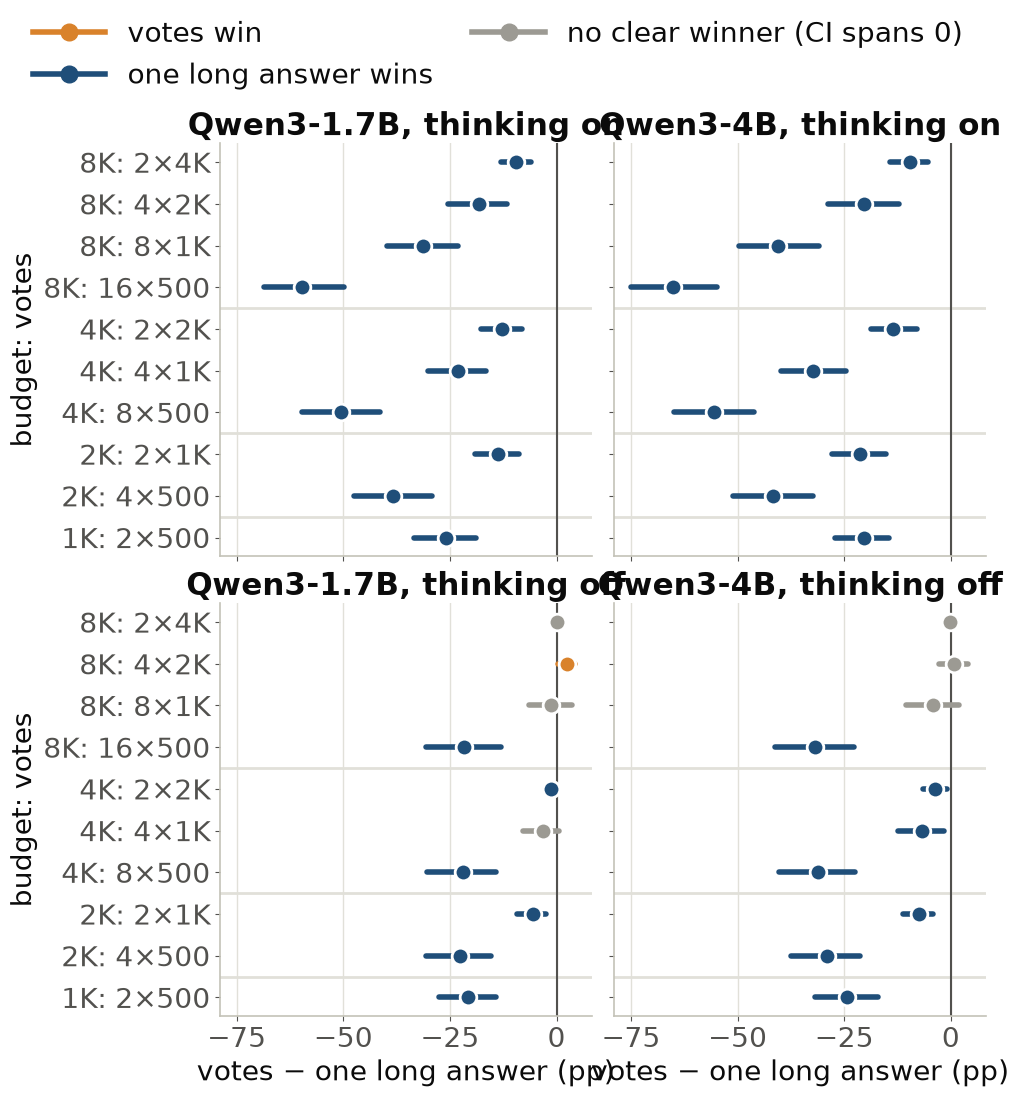

saved figures/R1b_problems_solved_8K_all.png/.pdf


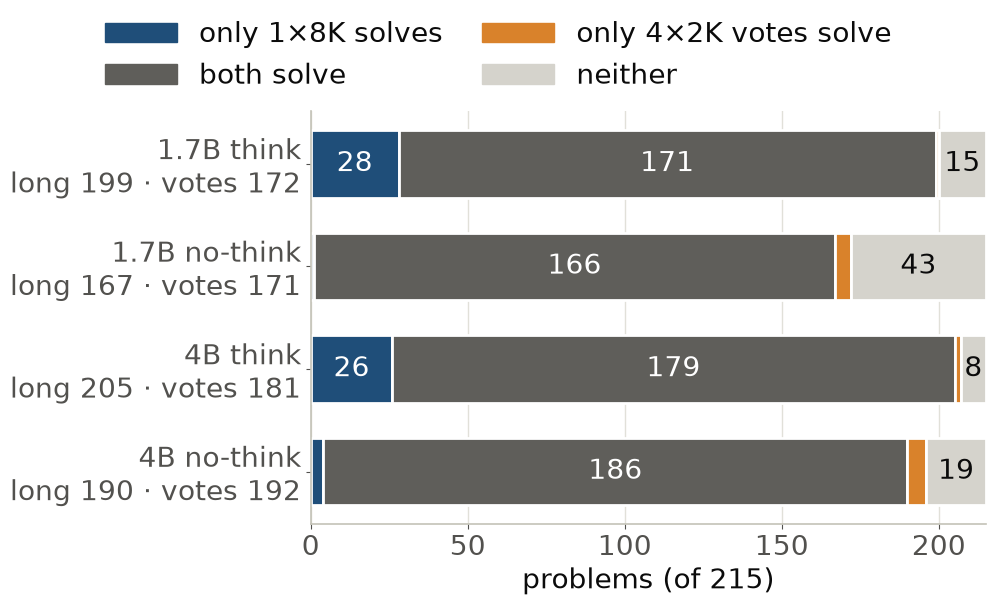

saved figures/R1c_accuracy_bars_8K_all.png/.pdf


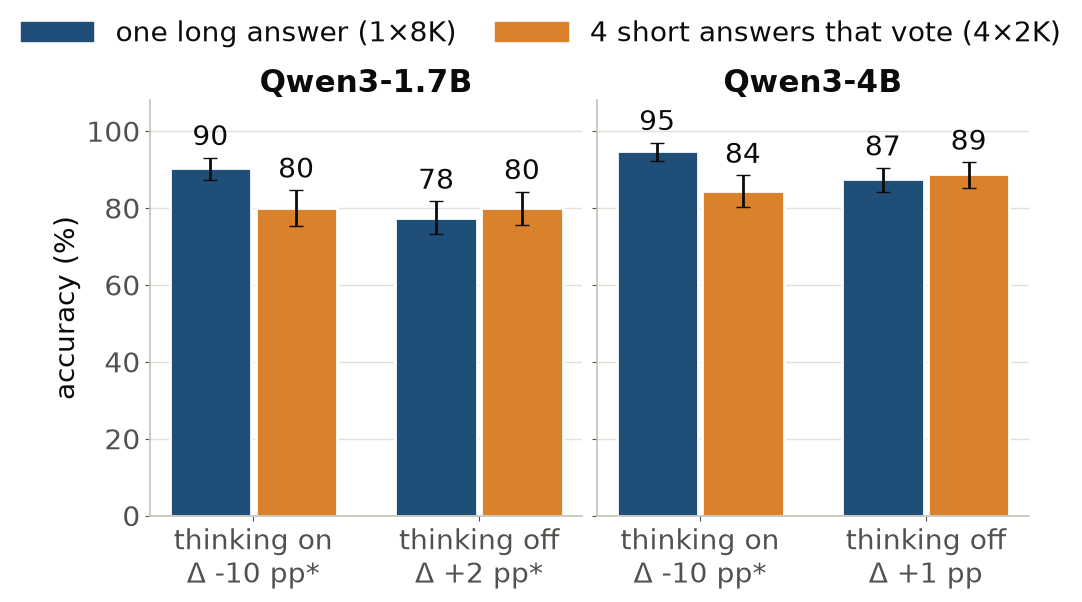

RQ1: same budget, one long answer vs votes (all 215 problems, 95% CI)
  Qwen3-1.7B  think    votes win 0/10 pairs, one long wins 10, no clear winner 0 | at 8K: 1×8K 90.3% vs 4×2K 80.1% (Δ -10.2 pp [-13.6, -7.0]); solved: long 199, votes 172, McNemar p = 0.0
  Qwen3-1.7B  nothink  votes win 1/10 pairs, one long wins 6, no clear winner 3 | at 8K: 1×8K 77.5% vs 4×2K 79.9% (Δ +2.4 pp [+1.4, +3.5]); solved: long 167, votes 171, McNemar p = 0.2188
  Qwen3-4B    think    votes win 0/10 pairs, one long wins 10, no clear winner 0 | at 8K: 1×8K 94.7% vs 4×2K 84.5% (Δ -10.3 pp [-13.9, -6.5]); solved: long 205, votes 181, McNemar p = 0.0
  Qwen3-4B    nothink  votes win 0/10 pairs, one long wins 7, no clear winner 3 | at 8K: 1×8K 87.5% vs 4×2K 88.7% (Δ +1.3 pp [-0.2, +2.6]); solved: long 190, votes 192, McNemar p = 0.7539


In [9]:
# ============================ RQ 2/3 — RQ1: SAME BUDGET, ONE LONG ANSWER OR SEVERAL SHORT ANSWERS THAT VOTE? ============
def fig_rq1_forest(g="all", name="R1a_same_budget_all_splits", w_mm=FIG_W_MM, h_mm=250):
    """Δ (votes − one long) with 95% CI for all 10 same-budget pairs; one panel per model × mode."""
    combos = [(m, md) for md in MODES for m in MODELS]
    ys = np.arange(len(PAIRS))[::-1]                                       # 8K pairs on top
    fig, axes = fig_mm(w_mm, h_mm, 2, 2, sharey=True, sharex=True)
    for ax, key in zip(axes.ravel(), combos):
        ax.axvline(0, color=INK2, lw=1.5, zorder=1)
        for y, (B, N) in zip(ys, PAIRS):
            pt, lo, hi = (100 * v for v in boot(delta_vote(*key, B, N), g))
            col = win_color(lo, hi)
            ax.plot([lo, hi], [y, y], color=col, lw=4, solid_capstyle="round", zorder=2)
            ax.plot(pt, y, "o", ms=12, color=col, mec="white", mew=2, zorder=3)
        for k in range(1, len(PAIRS)):                                      # hairline between budgets
            if PAIRS[k][0] != PAIRS[k - 1][0]:
                ax.axhline((ys[k] + ys[k - 1]) / 2, color=C_GRID, lw=2, zorder=0)
        ax.set_title(f"{key[0]}, thinking {'on' if key[1] == 'think' else 'off'}")
        ax.grid(axis="y", visible=False)
    for ax in axes[:, 0]:
        ax.set_yticks(ys, [f"{klab(B)}: {shape(N, B // N)}" for B, N in PAIRS])
        ax.set_ylabel("budget: votes")
    for ax in axes[-1]:
        ax.set_xlabel("votes − one long answer (pp)")
    top_legend(fig, winner_handles(), ncol=2)
    save(fig, name)

def fig_rq1_solved(B=RQ_B, N=VOTE_N, g="all", name=None, w_mm=FIG_W_MM, h_mm=125):
    """Problem counts: solved only by one long answer / by both / only by the votes / by neither."""
    combos = [(m, md) for m in MODELS for md in MODES]
    parts = [("only one long", C_DEPTH, f"only 1×{klab(B)} solves"), ("both", "#5f5e5a", "both solve"),
             ("only votes", C_WIDTH, f"only {shape(N, B // N)} votes solve"), ("neither", "#d5d3cc", "neither")]
    fig, axes = fig_mm(w_mm, h_mm)
    ax, ys, labels = axes[0, 0], np.arange(len(combos))[::-1], []
    for y, key in zip(ys, combos):
        sp, left = solved_split(*key, B, N, g), 0
        for k, col, _ in parts:
            v = sp[k]
            ax.barh(y, v, left=left, color=col, height=0.66, edgecolor="white", linewidth=2)
            if v >= 8:
                ax.text(left + v / 2, y, str(v), ha="center", va="center", fontsize=PT_MIN,
                        color=INK if k == "neither" else "white")
            left += v
        labels.append(f"{short_model(key[0])} {'think' if key[1] == 'think' else 'no-think'}\n"
                      f"long {sp['only one long'] + sp['both']} · votes {sp['only votes'] + sp['both']}")
    ax.set_yticks(ys, labels)
    ax.set_xlim(0, len(COLS[g])); ax.set_xlabel(f"problems (of {len(COLS[g])})")
    ax.grid(axis="y", visible=False)
    top_legend(fig, [Patch(color=c, label=lab) for _, c, lab in parts], ncol=2)
    save(fig, name or f"R1b_problems_solved_{klab(B)}_{g}")

def fig_rq1_bars(B=RQ_B, N=VOTE_N, g="all", name=None, w_mm=FIG_W_MM, h_mm=135):
    """Accuracy at budget B: one long answer (navy) vs N votes (orange); Δ under each pair, * = CI excludes 0."""
    n, j = idx(N, B // N)
    jB = A_LENGTHS.index(B)
    fig, axes = fig_mm(w_mm, h_mm, 1, len(MODELS), sharey=True)
    for ax, m in zip(axes[0], MODELS):
        ticks = []
        for k, md in enumerate(MODES):
            M_ = MET[(m, md)]
            for off, (nn, jj, col) in zip((-0.19, 0.19), [(0, jB, C_DEPTH), (n, j, C_WIDTH)]):
                mu, lo, hi = pct_curve(M_["maj"][:, nn, jj], g)
                ax.bar(k + off, mu, width=0.36, color=col, edgecolor="white", linewidth=2)
                ax.errorbar(k + off, mu, yerr=[[max(mu - lo, 0)], [max(hi - mu, 0)]], color=INK, elinewidth=2, capsize=5)
                ax.text(k + off, hi + 1.5, f"{mu:.0f}", ha="center", va="bottom", fontsize=PT_MIN)
            pt, lo, hi = (100 * v for v in boot(delta_vote(m, md, B, N), g))
            ticks.append(f"thinking {'on' if md == 'think' else 'off'}\nΔ {pt:+.0f} pp{'*' if lo > 0 or hi < 0 else ''}")
        ax.set_xticks(range(len(MODES)), ticks)
        ax.set_ylim(0, 108); ax.set_title(m); ax.grid(axis="x", visible=False)
    axes[0, 0].set_ylabel("accuracy (%)")
    top_legend(fig, [Patch(color=C_DEPTH, label=f"one long answer (1×{klab(B)})"),
                     Patch(color=C_WIDTH, label=f"{N} short answers that vote ({shape(N, B // N)})")], ncol=2)
    save(fig, name or f"R1c_accuracy_bars_{klab(B)}_{g}")

fig_rq1_forest("all")
fig_rq1_forest("hard", name="R1a_same_budget_all_splits_hard")
fig_rq1_solved(RQ_B, VOTE_N, "all")
fig_rq1_bars(RQ_B, VOTE_N, "all")

# ---- plain-language answer to RQ1 ----
print(f"RQ1: same budget, one long answer vs votes (all {P} problems, 95% CI)")
for (m, md), grp in T13[T13.difficulty == "all"].groupby(["model", "mode"], sort=False):
    w, l = (grp.winner == "votes win").sum(), (grp.winner == "one long wins").sum()
    h = grp[(grp["budget B"] == RQ_B) & (grp.N == VOTE_N)].iloc[0]
    print(f"  {m:<11} {md:<8} votes win {w}/{len(grp)} pairs, one long wins {l}, no clear winner {len(grp) - w - l} | "
          f"at {klab(RQ_B)}: 1×{klab(RQ_B)} {h['acc one long %']}% vs {h['votes']} {h['acc votes %']}% "
          f"(Δ {h['votes − one long']:+.1f} pp [{h['votes − one long lo']:+.1f}, {h['votes − one long hi']:+.1f}]); "
          f"solved: long {h['solved: only one long'] + h['solved: both']}, votes {h['solved: only votes'] + h['solved: both']}, "
          f"McNemar p = {h['McNemar p']}")

saved figures/R2a_by_level_8K.png/.pdf


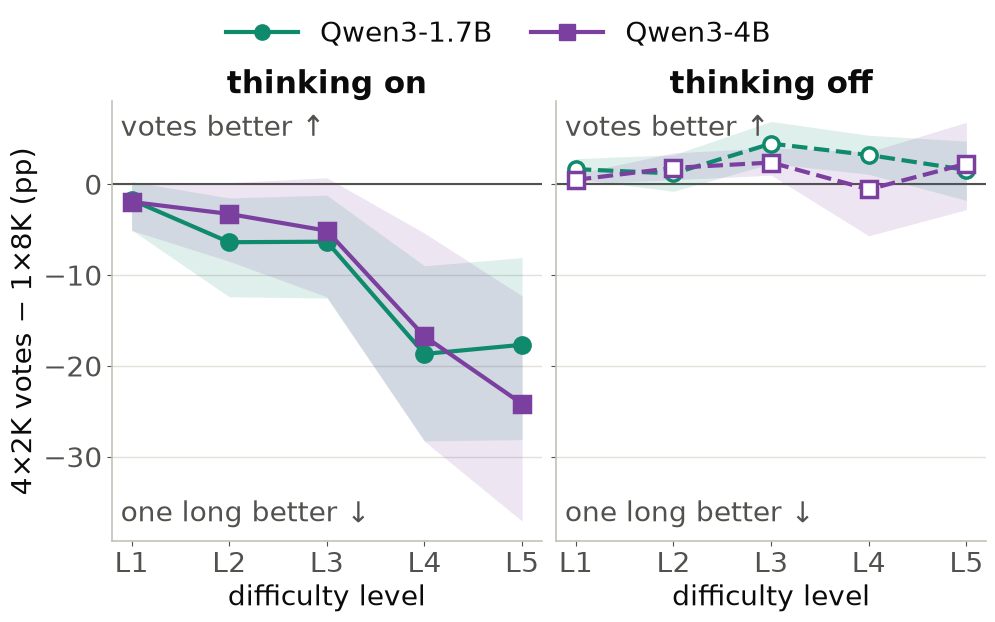

saved figures/R2b_factor_effects_8K.png/.pdf


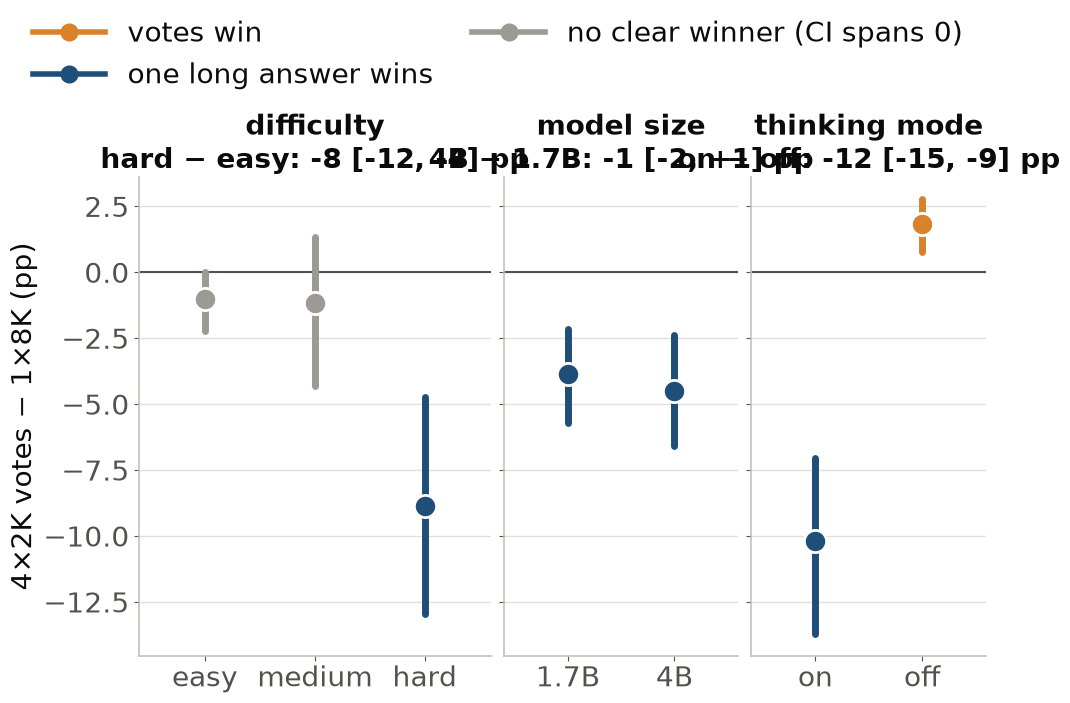

saved figures/R2c_winner_map_N4.png/.pdf


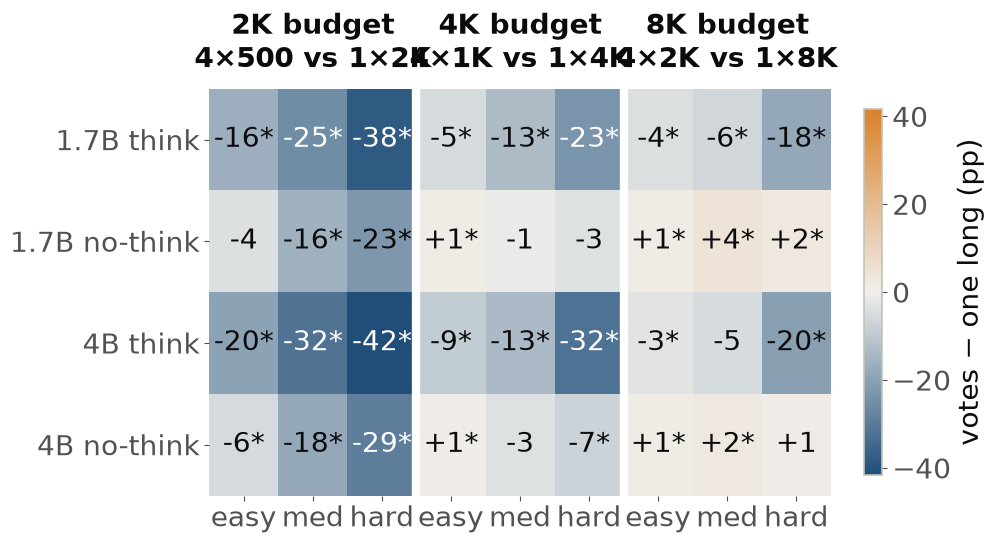


### T14_rq2_factor_effects  (18 rows) -> tables/T14_rq2_factor_effects.csv


,factor,comparison,estimate pp,estimate pp lo,estimate pp hi,reading
0,difficulty,Δ at easy,-1.0,-2.2,0.0,no clear winner
1,difficulty,Δ at medium,-1.1,-4.3,1.3,no clear winner
2,difficulty,Δ at hard,-8.8,-12.9,-4.7,one long wins
3,difficulty,hard − easy,-7.8,-12.0,-3.6,changes the answer
4,model size,Δ at 1.7B,-3.9,-5.7,-2.1,one long wins
5,model size,Δ at 4B,-4.5,-6.6,-2.4,one long wins
6,model size,4B − 1.7B,-0.6,-2.2,1.1,no clear change
7,thinking mode,Δ at on,-10.2,-13.7,-7.1,one long wins
8,thinking mode,Δ at off,1.8,0.8,2.8,votes win
9,thinking mode,on − off,-12.0,-15.3,-9.0,changes the answer


# Research-question answers (budget 8K, one long answer 1×8K vs 4×2K votes)

## RQ1: same budget, which solves more problems?

- Qwen3-1.7B, think: one long wins: 90.3% vs 80.1% (Δ -10.2 pp [-13.6, -7.0]); across all 10 same-budget pairs: votes win 0, one long wins 10
- Qwen3-1.7B, nothink: votes win: 77.5% vs 79.9% (Δ +2.4 pp [+1.4, +3.5]); across all 10 same-budget pairs: votes win 1, one long wins 6
- Qwen3-4B, think: one long wins: 94.7% vs 84.5% (Δ -10.3 pp [-13.9, -6.5]); across all 10 same-budget pairs: votes win 0, one long wins 10
- Qwen3-4B, nothink: no clear winner: 87.5% vs 88.7% (Δ +1.3 pp [-0.2, +2.6]); across all 10 same-budget pairs: votes win 0, one long wins 7

## RQ2: does the answer change?

- **difficulty**: easy -1.0 pp (no clear winner), medium -1.1 pp (no clear winner), hard -8.8 pp (one long wins). Contrast hard − easy: -7.8 pp [-12.0, -3.6] → changes the answer
- **model size**: 1.7B -3.9 pp (one long wins), 4B -4.5 pp (one long wins). Contrast 4B − 1.7B: -0.6

In [10]:
# ============================ RQ 3/3 — RQ2: DOES THE ANSWER CHANGE WITH DIFFICULTY, MODEL SIZE, THINKING MODE? ============
def rq2_effects(B=RQ_B, N=VOTE_N):
    """Δ (votes − one long) for each level of each factor, averaged over the other factors, plus the contrast that asks
    'does this factor change the answer?' (paired over the same problems, except difficulty, which splits problems)."""
    D = {(m, md): delta_vote(m, md, B, N) for m in MODELS for md in MODES}
    avg = np.mean(list(D.values()), 0)
    by_model = {m: (D[(m, "think")] + D[(m, "nothink")]) / 2 for m in MODELS}
    by_mode = {md: (D[(MODELS[0], md)] + D[(MODELS[1], md)]) / 2 for md in MODES}
    levels = {"difficulty": [(g, boot(avg, g)) for g in ("easy", "medium", "hard")],
              "model size": [(short_model(m), boot(by_model[m])) for m in MODELS],
              "thinking mode": [("on" if md == "think" else "off", boot(by_mode[md])) for md in MODES]}
    contrasts = {"difficulty": ("hard − easy", group_contrast(avg, "hard", "easy")),
                 "model size": (f"{short_model(MODELS[1])} − {short_model(MODELS[0])}",
                                boot(by_model[MODELS[1]] - by_model[MODELS[0]])),
                 "thinking mode": ("on − off", boot(by_mode["think"] - by_mode["nothink"]))}
    return D, levels, contrasts

def fig_rq2_levels(B=RQ_B, N=VOTE_N, name=None, w_mm=FIG_W_MM, h_mm=140):
    """Δ across difficulty levels L1–L5, one line per model; left = thinking on, right = thinking off."""
    fig, axes = fig_mm(w_mm, h_mm, 1, len(MODES), sharey=True)
    for ax, md in zip(axes[0], MODES):
        ax.axhline(0, color=INK2, lw=1.5, zorder=1)
        for m in MODELS:
            r = [boot(delta_vote(m, md, B, N), f"L{l}") for l in LEVELS]
            mu, lo, hi = (100 * np.array([t[k] for t in r]) for k in range(3))
            ax.fill_between(LEVELS, lo, hi, color=C_MODEL[m], alpha=0.13, lw=0)
            ax.plot(LEVELS, mu, color=C_MODEL[m], marker=MK_MODEL[m], ls=LS_MODE[md], mec=C_MODEL[m], mew=2.5,
                    mfc=C_MODEL[m] if md == "think" else "white")
        ax.set_xticks(LEVELS, [f"L{l}" for l in LEVELS]); ax.set_xlabel("difficulty level")
        ax.set_title(f"thinking {'on' if md == 'think' else 'off'}"); ax.grid(axis="x", visible=False)
        sign_labels(ax)
    axes[0, 0].set_ylabel(f"{shape(N, B // N)} votes − 1×{klab(B)} (pp)")
    top_legend(fig, [Line2D([], [], color=C_MODEL[m], marker=MK_MODEL[m], lw=3, label=m) for m in MODELS], ncol=2)
    save(fig, name or f"R2a_by_level_{klab(B)}")

def fig_rq2_effects(B=RQ_B, N=VOTE_N, name=None, w_mm=FIG_W_MM, h_mm=150):
    """One panel per factor: Δ at each level (averaged over the other two factors); title = the contrast and its CI."""
    _, levels, contrasts = rq2_effects(B, N)
    fig, axes = fig_mm(w_mm, h_mm, 1, 3, sharey=True, gridspec_kw={"width_ratios": [3, 2, 2]})
    for ax, (factor, items) in zip(axes[0], levels.items()):
        ax.axhline(0, color=INK2, lw=1.5, zorder=1)
        for k, (_, trip) in enumerate(items):
            pt, lo, hi = (100 * v for v in trip)
            col = win_color(lo, hi)
            ax.plot([k, k], [lo, hi], color=col, lw=5, solid_capstyle="round", zorder=2)
            ax.plot(k, pt, "o", ms=16, color=col, mec="white", mew=2, zorder=3)
        ax.set_xticks(range(len(items)), [lab for lab, _ in items]); ax.set_xlim(-0.6, len(items) - 0.4)
        clab, (cp, clo, chi) = contrasts[factor]
        ax.set_title(f"{factor}\n{clab}: {100 * cp:+.0f} [{100 * clo:+.0f}, {100 * chi:+.0f}] pp", fontsize=PT_MIN)
        ax.grid(axis="x", visible=False)
    axes[0, 0].set_ylabel(f"{shape(N, B // N)} votes − 1×{klab(B)} (pp)")
    top_legend(fig, winner_handles(), ncol=2)
    save(fig, name or f"R2b_factor_effects_{klab(B)}")

def fig_rq2_winner_map(N=VOTE_N, budgets=(2000, 4000, 8000), groups=("easy", "medium", "hard"), name=None,
                       w_mm=FIG_W_MM, h_mm=135):
    """Δ for every model × mode (rows) and budget × difficulty (columns). * = 95% CI excludes 0."""
    rows_ = [(m, md) for m in MODELS for md in MODES]
    cols_ = [(B, g) for B in budgets if B % N == 0 and B // N in A_LENGTHS for g in groups]
    V, S = np.zeros((len(rows_), len(cols_))), np.zeros((len(rows_), len(cols_)), bool)
    for r, key in enumerate(rows_):
        for c, (B, g) in enumerate(cols_):
            pt, lo, hi = boot(delta_vote(*key, B, N), g)
            V[r, c], S[r, c] = 100 * pt, (lo > 0) | (hi < 0)
    vmax = max(1.0, float(np.abs(V).max()))
    fig, axes = fig_mm(w_mm, h_mm)
    ax = axes[0, 0]
    im = ax.imshow(V, cmap=CMAP_DW, vmin=-vmax, vmax=vmax, aspect="auto")
    for r in range(len(rows_)):
        for c in range(len(cols_)):
            ax.text(c, r, f"{V[r, c]:+.0f}{'*' if S[r, c] else ''}", ha="center", va="center", fontsize=PT_MIN,
                    color="white" if abs(V[r, c]) > 0.55 * vmax else INK)
    ax.set_xticks(range(len(cols_)), [{"easy": "easy", "medium": "med", "hard": "hard"}[g] for _, g in cols_])
    ax.set_yticks(range(len(rows_)), [f"{short_model(m)} {'think' if md == 'think' else 'no-think'}" for m, md in rows_])
    nb = len(groups)
    for k, B in enumerate(dict.fromkeys(B for B, _ in cols_)):
        ax.text(k * nb + (nb - 1) / 2, -0.62, f"{klab(B)} budget\n{shape(N, B // N)} vs 1×{klab(B)}", ha="center",
                va="bottom", fontsize=PT_MIN, fontweight="bold")
        if k:
            ax.axvline(k * nb - 0.5, color="white", lw=6)
    ax.grid(False)
    for sp in ax.spines.values():
        sp.set_visible(False)
    fig.colorbar(im, ax=ax, shrink=0.9, label="votes − one long (pp)")
    save(fig, name or f"R2c_winner_map_N{N}")

fig_rq2_levels()
fig_rq2_effects()
fig_rq2_winner_map()

# ---- T14: does each factor change the answer? (level effects, main contrasts, and interactions) ----
def change_word(lo, hi):
    return "changes the answer" if lo > 0 or hi < 0 else "no clear change"

D, levels, contrasts = rq2_effects()
rows = []
for factor, items in levels.items():
    for lab, (pt, lo, hi) in items:
        rows.append({"factor": factor, "comparison": f"Δ at {lab}", **ci3("estimate pp", (pt, lo, hi)),
                     "reading": win_word(lo, hi)})
    clab, trip = contrasts[factor]
    rows.append({"factor": factor, "comparison": clab, **ci3("estimate pp", trip), "reading": change_word(*trip[1:])})
inter = [("model size × mode", f"{short_model(MODELS[1])} − {short_model(MODELS[0])}, {md}",
          boot(D[(MODELS[1], md)] - D[(MODELS[0], md)])) for md in MODES]
inter += [("mode × model size", f"on − off, {short_model(m)}", boot(D[(m, "think")] - D[(m, "nothink")])) for m in MODELS]
inter += [("difficulty × model × mode", f"hard − easy, {short_model(m)} {md}", group_contrast(x, "hard", "easy"))
          for (m, md), x in D.items()]
for factor, comp, trip in inter:
    rows.append({"factor": factor, "comparison": comp, **ci3("estimate pp", trip), "reading": change_word(*trip[1:])})
T14 = save_table(pd.DataFrame(rows), "T14_rq2_factor_effects")

# ---- plain-language answers + RQ_ANSWERS.md ----
lines = [f"# Research-question answers (budget {klab(RQ_B)}, one long answer 1×{klab(RQ_B)} vs {shape(VOTE_N, RQ_B // VOTE_N)} votes)\n",
         "## RQ1: same budget, which solves more problems?\n"]
for (m, md), grp in T13[(T13.difficulty == "all")].groupby(["model", "mode"], sort=False):
    h = grp[(grp["budget B"] == RQ_B) & (grp.N == VOTE_N)].iloc[0]
    lines.append(f"- {m}, {md}: {h['winner']}: {h['acc one long %']}% vs {h['acc votes %']}% "
                 f"(Δ {h['votes − one long']:+.1f} pp [{h['votes − one long lo']:+.1f}, {h['votes − one long hi']:+.1f}]); "
                 f"across all {len(grp)} same-budget pairs: votes win {(grp.winner == 'votes win').sum()}, "
                 f"one long wins {(grp.winner == 'one long wins').sum()}")
lines.append("\n## RQ2: does the answer change?\n")
for factor in levels:
    clab, (pt, lo, hi) = contrasts[factor]
    per = ", ".join(f"{lab} {100 * t[0]:+.1f} pp ({win_word(t[1], t[2])})" for lab, t in levels[factor])
    lines.append(f"- **{factor}**: {per}. Contrast {clab}: {100 * pt:+.1f} pp [{100 * lo:+.1f}, {100 * hi:+.1f}] → "
                 f"{change_word(lo, hi)}")
lines += ["\n## Tables\n", "- `tables/T13_rq1_same_budget.csv`", "- `tables/T14_rq2_factor_effects.csv`"]
with open(f"{ANALYSIS_DIR}/RQ_ANSWERS.md", "w") as f:
    f.write("\n".join(lines) + "\n")
print("\n".join(lines))
if os.path.isdir("/kaggle/working"):
    print("zipped ->", shutil.make_archive(ANALYSIS_DIR, "zip", ANALYSIS_DIR))


### T15_answer_outcomes_by_cap  (80 rows) -> tables/T15_answer_outcomes_by_cap.csv


right %                         wrong, ran out %                        
cap per answer        8000  4000  2000  1000  500              8000  4000  2000  1000  500 
model      mode                                                                            
Qwen3-1.7B nothink    77.5  77.6  76.9  73.5  60.4              0.6   1.5   5.5  15.7  35.6
           think      90.3  85.6  77.0  68.9  48.2              7.7  13.9  22.9  31.1  51.8
Qwen3-4B   nothink    87.5  87.4  85.8  81.5  66.0              0.7   0.9   4.8  13.4  31.9
           think      94.7  90.4  82.5  68.9  50.4              4.1   9.3  17.5  31.1  49.6

saved figures/R3_answer_outcomes_by_cap_all.png/.pdf


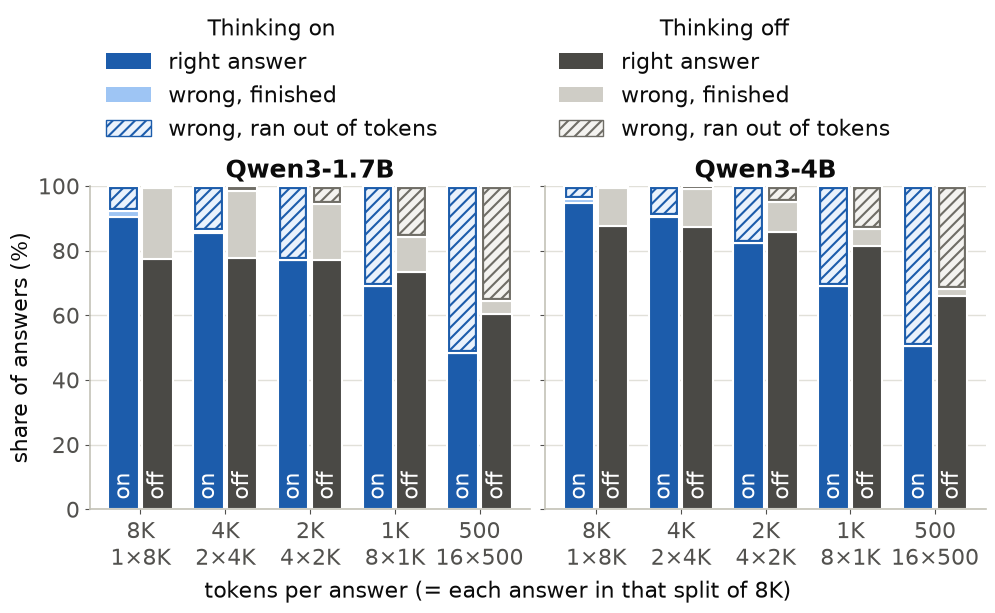

saved figures/R3_answer_outcomes_by_cap_hard.png/.pdf


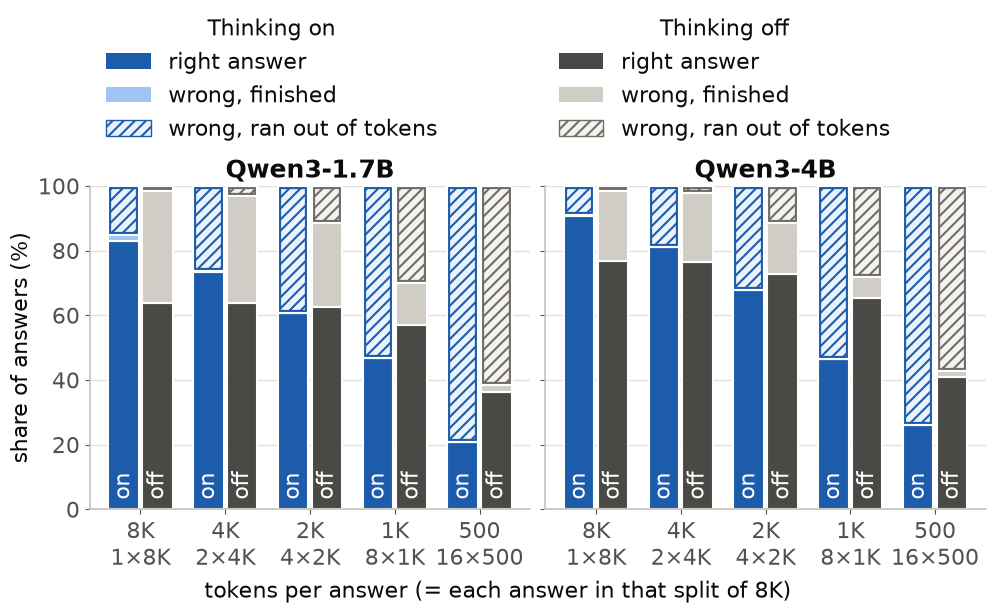

In [17]:
# ============================ RESULT 3 — WHAT HAPPENS TO EVERY ANSWER AT EVERY TOKEN CAP (thinking on vs off) ============
# One bar = all 16 × 215 answers of one model and mode at one per-answer cap L. Splitting an 8K budget into N votes
# gives each answer the cap L = 8K/N, so the bar at L is also what every answer inside the N×L vote looks like
# (8K ↔ 1×8K, 4K ↔ 2×4K, 2K ↔ 4×2K, 1K ↔ 8×1K, 500 ↔ 16×500).
# A truncated answer that budget forcing still got right counts as "right".
OUTCOME_COLORS = {   # one colour family per mode: dark = right, light = wrong but finished, hatched = ran out of tokens
    "think":   {"right": "#1c5cab", "wrong": "#9ec5f4", "out": "#1c5cab", "out_face": "#eaf2fc"},
    "nothink": {"right": "#4a4945", "wrong": "#cfcdc6", "out": "#6f6d66", "out_face": "#f4f3f0"},
}
MODE_NAME = {"think": "Thinking on", "nothink": "Thinking off"}

def answer_outcomes(m, md, g="all"):
    """Share of answers per cap (arrays over A_LENGTHS): right / wrong but finished / wrong and ran out of tokens."""
    a, c = ARR[(m, md)], COLS[g]
    ok, tr = a["ok"][c], a["trunc"][c]                                     # (problems, 16, nL)
    return {"right": ok.mean((0, 1)), "wrong": (~ok & ~tr).mean((0, 1)), "out": (~ok & tr).mean((0, 1))}

def fig_answer_outcomes(g="all", name=None, w_mm=FIG_W_MM, h_mm=115, pt=16):
    """pt = font size of every label in this figure (smaller than PT_MIN so the tick labels do not collide)."""
    bw, off = 0.36, {"think": -0.2, "nothink": 0.2}
    with plt.rc_context({"hatch.linewidth": 1.5, "font.size": pt, "axes.titlesize": pt + 2, "axes.labelsize": pt,
                         "xtick.labelsize": pt, "ytick.labelsize": pt, "legend.fontsize": pt}):
        fig, axes = fig_mm(w_mm, h_mm, 1, len(MODELS), sharey=True)
        for ax, m in zip(axes[0], MODELS):
            for md in MODES:
                o, col, xs = answer_outcomes(m, md, g), OUTCOME_COLORS[md], X5 + off[md]
                r, w, t = 100 * o["right"], 100 * o["wrong"], 100 * o["out"]
                ax.bar(xs, r, bw, color=col["right"], edgecolor="white", linewidth=1.5)
                ax.bar(xs, w, bw, bottom=r, color=col["wrong"], edgecolor="white", linewidth=1.5)
                ax.bar(xs, t, bw, bottom=r + w, color=col["out_face"], edgecolor=col["out"], hatch="///", linewidth=0)
                for p in ax.bar(xs, t, bw, bottom=r + w, fill=False, edgecolor=col["out"], linewidth=4.5):
                    p.set_clip_path(p)                                     # border drawn inside the bar only ("border-box")
                ax.bar(xs, t, bw, bottom=r + w, fill=False, edgecolor="white", linewidth=1.5)   # same white edge as the other segments -> same width, 1.5pt border left
                for x_, r_ in zip(xs, r):                                  # "on"/"off" inside the bar
                    if r_ >= 15:
                        ax.text(x_, 3, "on" if md == "think" else "off", rotation=90, ha="center", va="bottom",
                                color="white", fontsize=pt)
            ax.set_xticks(X5, [f"{klab(L)}\n{shape(N, L)}" for N, L in DIAG])
            ax.set_xlim(-0.6, nN - 0.4); ax.set_ylim(0, 100)
            ax.set_title(m); ax.grid(axis="x", visible=False)
        axes[0, 0].set_ylabel("share of answers (%)")
        fig.supxlabel("tokens per answer (= each answer in that split of 8K)", fontsize=pt)   # one label, no overlap
        for k, md in enumerate(MODES):
            col = OUTCOME_COLORS[md]
            fig.legend(handles=[Patch(facecolor=col["right"], label="right answer"),
                                Patch(facecolor=col["wrong"], label="wrong, finished"),
                                Patch(facecolor=col["out_face"], edgecolor=col["out"], hatch="///",
                                      label="wrong, ran out of tokens")],
                       title=MODE_NAME[md], title_fontsize=pt, loc="lower center",
                       bbox_to_anchor=(0.27 + 0.46 * k, 1.0), ncol=1, borderaxespad=0.2)
        save(fig, name or f"R3_answer_outcomes_by_cap_{g}")

rows = []
for m in MODELS:
    for md in MODES:
        for g in G4:
            o = answer_outcomes(m, md, g)
            for j, (N, L) in enumerate(DIAG):
                rows.append({"model": m, "mode": md, "difficulty": g, "cap per answer": L, "8K split": shape(N, L),
                             "right %": pct(o["right"][j]), "wrong, finished %": pct(o["wrong"][j]),
                             "wrong, ran out %": pct(o["out"][j])})
T15 = save_table(pd.DataFrame(rows), "T15_answer_outcomes_by_cap", show=False)
display(T15[T15.difficulty == "all"].pivot_table(index=["model", "mode"], columns="cap per answer",
                                                 values=["right %", "wrong, ran out %"])
        .reindex(columns=A_LENGTHS, level=1))

fig_answer_outcomes("all", pt=16)
fig_answer_outcomes("hard", pt=16)